# under mild case $(\beta,c_{\kappa},c_{\Lambda})=(1,1,1)$.  


# ==========Section_2: Definitions================#

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Callable, List, Tuple, Optional




@dataclass
class SuperquadricFieldParameters:
    """
    Superquadric implicit field parameters
    
    F_3d(x,y,z) = (f(x,y))^(eps2/eps1) + |z/a3|^(2/eps1) - 1
    f(x,y)      = |x/a1|^(2/eps2) + |y/a2|^(2/eps2)
    """
    a1: float
    a2: float
    a3: float
    eps1: float
    eps2: float
    sdf_eps: float = 1e-8  # Denominator stability term for normalized signed field

@dataclass
class StiffnessParameters:
    """
   Smooth stiffness function parameters
    
    k(d) = k_min + ((1 - tanh(d/d0))/2) * k_max
    """
    k_min: float
    k_max: float
    d0: float




## ==========Geometry================


In [2]:
import numpy as np
from dataclasses import dataclass
from typing import Tuple


# =========================
# Basic data structure
# =========================

@dataclass
class Pose:
    """
    Pose X = (R, p), with
        R in SO(3), shape (3, 3)
        p in R^3,  shape (3,)
    """
    R: np.ndarray
    p: np.ndarray

    def __post_init__(self):
        self.R = ensure_matrix(self.R, (3, 3))
        self.p = ensure_vector(self.p, 3)


# =========================
# Shape / type utilities
# =========================

def ensure_vector(x: np.ndarray, dim: int) -> np.ndarray:
    """
    Ensure x is a 1D vector of length `dim`.
    """
    x = np.asarray(x, dtype=float).reshape(-1)
    if x.shape[0] != dim:
        raise ValueError(f"Expected vector of length {dim}, got shape {x.shape}")
    return x


def ensure_matrix(x: np.ndarray, shape: Tuple[int, int]) -> np.ndarray:
    """
    Ensure x is a matrix of the specified shape.
    """
    x = np.asarray(x, dtype=float)
    if x.shape != shape:
        raise ValueError(f"Expected matrix of shape {shape}, got shape {x.shape}")
    return x


# =========================
# so(3) <-> R^3
# =========================

def hat(v: np.ndarray) -> np.ndarray:
    """
    hat : R^3 -> so(3)

    For v = [v1, v2, v3]^T,
    hat(v) = [[  0, -v3,  v2],
              [ v3,   0, -v1],
              [-v2, v1,   0 ]]
    """
    v = ensure_vector(v, 3)
    return np.array([
        [0.0,   -v[2],  v[1]],
        [v[2],   0.0,  -v[0]],
        [-v[1],  v[0],  0.0]
    ])


def vee(M: np.ndarray) -> np.ndarray:
    """
    vee : so(3) -> R^3
    """
    M = ensure_matrix(M, (3, 3))
    return np.array([
        M[2, 1],
        M[0, 2],
        M[1, 0]
    ])


# =========================
# SO(3) maps
# =========================

def project_to_so3(M: np.ndarray) -> np.ndarray:
    """
    Project a 3x3 matrix to SO(3) via SVD.
    """
    M = ensure_matrix(M, (3, 3))
    U, _, Vt = np.linalg.svd(M)
    R = U @ np.diag([1.0, 1.0, np.linalg.det(U @ Vt)]) @ Vt
    return R


def so3_exp(phi: np.ndarray) -> np.ndarray:
    """
    Exponential map on SO(3):
        R = exp(hat(phi))

    Uses Rodrigues' formula with small-angle handling.
    """
    phi = ensure_vector(phi, 3)
    theta = np.linalg.norm(phi)
    Phi = hat(phi)

    if theta < 1e-12:
        return np.eye(3) + Phi

    A = np.sin(theta) / theta
    B = (1.0 - np.cos(theta)) / (theta ** 2)
    return np.eye(3) + A * Phi + B * (Phi @ Phi)


def so3_log(R: np.ndarray) -> np.ndarray:
    """
    Logarithm map on SO(3):
        phi = log(R)^vee

    For numerical robustness, R is first projected to SO(3).
    Includes special handling near theta = pi.
    """
    R = ensure_matrix(R, (3, 3))
    R = project_to_so3(R)

    cos_theta = (np.trace(R) - 1.0) / 2.0
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta = np.arccos(cos_theta)

    # Near zero
    if theta < 1e-12:
        return 0.5 * vee(R - R.T)

    # Near pi
    if np.pi - theta < 1e-6:
        A = 0.5 * (R + np.eye(3))
        axis = np.array([
            np.sqrt(max(A[0, 0], 0.0)),
            np.sqrt(max(A[1, 1], 0.0)),
            np.sqrt(max(A[2, 2], 0.0))
        ])

        # Recover signs from off-diagonal entries
        if axis[0] > 1e-8:
            axis[1] = np.copysign(axis[1], R[0, 1] + R[1, 0])
            axis[2] = np.copysign(axis[2], R[0, 2] + R[2, 0])
        elif axis[1] > 1e-8:
            axis[2] = np.copysign(axis[2], R[1, 2] + R[2, 1])
        else:
            # fallback: axis[2] dominates or all are tiny
            pass

        norm_axis = np.linalg.norm(axis)
        if norm_axis < 1e-12:
            axis = np.array([1.0, 0.0, 0.0])
        else:
            axis = axis / norm_axis

        return theta * axis

    return vee((theta / (2.0 * np.sin(theta))) * (R - R.T))


# =========================
# Pose operations （SE（3））
# =========================

def rigid_compose(X1: Pose, X2: Pose) -> Pose:
    """
    Standard rigid pose composition:
        X1 * X2 = (R1 R2, R1 p2 + p1)
    """
    R = X1.R @ X2.R
    p = X1.R @ X2.p + X1.p
    return Pose(R=R, p=p)


def rigid_inverse(X: Pose) -> Pose:
    """
    Pose inverse:
        X^{-1} = (R^T, -R^T p)
    """
    R_inv = X.R.T
    p_inv = -R_inv @ X.p
    return Pose(R=R_inv, p=p_inv)


# =========================
# Pose operations （SO（3）X R^3）
# =========================

def dp_compose(X1: Pose, X2: Pose) -> Pose:
    """
    Direct-product group operation on SO(3) x R^3:
        (R1, p1) * (R2, p2) = (R1 R2, p1 + p2).
    """
    return Pose(R=X1.R @ X2.R, p=X1.p + X2.p)


def dp_inverse(X: Pose) -> Pose:
    """
    Direct-product inverse:
        (R, p)^{-1} = (R^T, -p).
    """
    return Pose(R=X.R.T, p=-X.p)


def rigid_compose(X1: Pose, X2: Pose) -> Pose:
    """
    Standard rigid transform composition:
        (R1, p1) o (R2, p2) = (R1 R2, R1 p2 + p1).

    Use this only for coordinate-frame transformations, not for the
    direct-product group structure used in the estimator.
    """
    return Pose(R=X1.R @ X2.R, p=X1.R @ X2.p + X1.p)


def rigid_inverse(X: Pose) -> Pose:
    """
    Standard rigid transform inverse:
        (R, p)^{-1} = (R^T, -R^T p).
    """
    R_inv = X.R.T
    return Pose(R=R_inv, p=-R_inv @ X.p)





# =========================
# Right perturbation on SO(3) x R^3
# =========================

def split_xi(xi: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Split xi in R^6 into (phi, v), where
        xi = [phi; v]
        phi in R^3, v in R^3
    """
    xi = ensure_vector(xi, 6)
    return xi[:3], xi[3:]


def pack_xi(phi: np.ndarray, v: np.ndarray) -> np.ndarray:
    """
    Pack (phi, v) into xi = [phi; v] in R^6.
    """
    phi = ensure_vector(phi, 3)
    v = ensure_vector(v, 3)
    return np.concatenate([phi, v])


def apply_right_perturbation(X: Pose, xi: np.ndarray) -> Pose:
    """
    Right perturbation under the direct-product local model:
        X ⊕ xi = (R exp(hat(phi)), p + v)

    where xi = [phi; v] in R^6.
    """
    phi, v = split_xi(xi)
    R_new = X.R @ so3_exp(phi)
    p_new = X.p + v
    return Pose(R=R_new, p=p_new)


# =========================
# Error / distance utilities
# =========================

def rotation_geodesic_error(R1: np.ndarray, R2: np.ndarray) -> float:
    """
    Geodesic distance on SO(3):

        d(R1, R2) = || Log(R1^T R2)^vee ||_2

    Rotation-angle distance on SO(3), computed as the Euclidean norm
    of the rotation-vector logarithm:
    d(R1, R2) = || Log(R1^T R2)^vee ||_2.
    """
    R1 = ensure_matrix(R1, (3, 3))
    R2 = ensure_matrix(R2, (3, 3))
    return float(np.linalg.norm(so3_log(R1.T @ R2)))


def pose_rotation_error(X1: Pose, X2: Pose) -> float:
    """
    Rotation geodesic error between two poses.
    """
    return rotation_geodesic_error(X1.R, X2.R)


def pose_translation_error(X1: Pose, X2: Pose) -> float:
    """
    Euclidean translation error between two poses.
    """
    return float(np.linalg.norm(X1.p - X2.p))


# =========================
# Optional validation helper
# =========================

def is_rotation_matrix(R: np.ndarray, atol: float = 1e-6) -> bool:
    """
    Check whether R is approximately in SO(3).
    """
    R = ensure_matrix(R, (3, 3))
    should_be_I = R.T @ R
    det_R = np.linalg.det(R)
    return (
        np.allclose(should_be_I, np.eye(3), atol=atol)
        and np.isclose(det_R, 1.0, atol=atol)
    )


## ==========MFG / Distribution - related================


In [3]:
# =========================
# MFG / Matrix-Fisher-Gaussian related
# =========================

from dataclasses import dataclass
import numpy as np


@dataclass
class MFGParameters:
    """
    Matrix-Fisher-Gaussian parameters:
        Theta = {F, mu, Lambda, Gamma}

    F      : Matrix Fisher parameter matrix, shape (3,3)
    mu     : translation base mean, shape (3,)
    Lambda : translation precision matrix, shape (3,3)
    Gamma  : rotation-translation coupling matrix, shape (3,3)
    """
    F: np.ndarray
    mu: np.ndarray
    Lambda: np.ndarray
    Gamma: np.ndarray

    def __post_init__(self):
        self.F = ensure_matrix(self.F, (3, 3))
        self.mu = ensure_vector(self.mu, 3)
        self.Lambda = ensure_matrix(self.Lambda, (3, 3))
        self.Gamma = ensure_matrix(self.Gamma, (3, 3))



def mfg_svd(F: np.ndarray):
    """
    Proper SVD for the Matrix-Fisher parameter:
        F = U S V^T,  U,V in SO(3),
    where the last signed singular value may be negative.
    """
    F = ensure_matrix(F, (3, 3))

    if not np.isfinite(F).all():
        raise ValueError("F contains NaN or Inf; SVD cannot be performed.")

    U0, s0, Vt0 = np.linalg.svd(F)
    V0 = Vt0.T

    DU = np.diag([1.0, 1.0, np.linalg.det(U0)])
    DV = np.diag([1.0, 1.0, np.linalg.det(V0)])

    U = U0 @ DU
    V = V0 @ DV
    S = DU @ np.diag(s0) @ DV

    return U, S, V




def rotation_mode_from_F(F: np.ndarray) -> np.ndarray:
    """
    Recover the mode rotation from F.

    If
        F = U S V^T,
    then
        R_mode = U diag(1,1,det(UV^T)) V^T.
    """
    F = ensure_matrix(F, (3, 3))

    if not np.isfinite(F).all():
        raise ValueError("F contains NaN or Inf; SVD cannot be performed.")

    U, _, Vt = np.linalg.svd(F)
    R_mode = U @ np.diag([1.0, 1.0, np.linalg.det(U @ Vt)]) @ Vt
    return R_mode


def mfg_nu_R(R: np.ndarray, F: np.ndarray) -> np.ndarray:
    """
    The MFG rotational deviation vector nu_R defined by Definition II.7:

        F = U S V^T,
        Q = U^T R V,
        nu_R = (Q S - S Q^T)^vee.

    This is the theory-consistent definition of nu_R.
    """
    R = ensure_matrix(R, (3, 3))
    F = ensure_matrix(F, (3, 3))

    U, S, V = mfg_svd(F)
    Q = U.T @ R @ V

    A = Q @ S - S @ Q.T
    # Numerical antisymmetrization for stability
    A = 0.5 * (A - A.T)
    return vee(A)


def conditional_translation_mean(R: np.ndarray, theta: MFGParameters) -> np.ndarray:
    """
    Rotation-dependent translation mean:
        mu_c(R) = mu + Gamma nu_R.
    """
    R = ensure_matrix(R, (3, 3))
    nu_R = mfg_nu_R(R, theta.F)
    return theta.mu + theta.Gamma @ nu_R



def recover_pose_from_theta(theta: MFGParameters) -> Pose:
    """
    Recover a representative MAP-like pose from the coupled MFG parameters.

    We use the Matrix-Fisher mode for rotation and the corresponding
    conditional translation mean:
        R_hat = mode(F),
        p_hat = mu + Gamma nu_R_hat.

    At the ideal Matrix-Fisher mode, nu_R_hat = 0, hence p_hat = mu.
    """
    R_hat = rotation_mode_from_F(theta.F)
    p_hat = conditional_translation_mean(R_hat, theta)
    return Pose(R=R_hat, p=p_hat)






# ============ Section_3  Potential and Wrench Model

## part A: SDF / stiffness / 
## superquadric implicit field


In [4]:
# =========================
# Field / stiffness parameter classes
# =========================


@dataclass
class SuperquadricFieldParameters:
    """
    Superquadric implicit field parameters.

    Implicit field:
        F_3d(x,y,z) = (f(x,y))^(eps2/eps1) + |z/a3|^(2/eps1) - 1

    where
        f(x,y) = |x/a1|^(2/eps2) + |y/a2|^(2/eps2)

    Notes
    -----
    - a1, a2, a3 > 0 are scale parameters
    - eps1, eps2 > 0 are shape parameters
    - sdf_eps is a small positive regularization used in the normalized signed field
    """
    a1: float
    a2: float
    a3: float
    eps1: float
    eps2: float
    sdf_eps: float = 1e-8

    def __post_init__(self):
        self.a1 = float(self.a1)
        self.a2 = float(self.a2)
        self.a3 = float(self.a3)
        self.eps1 = float(self.eps1)
        self.eps2 = float(self.eps2)
        self.sdf_eps = float(self.sdf_eps)

        if self.a1 <= 0 or self.a2 <= 0 or self.a3 <= 0:
            raise ValueError("a1, a2, a3 must all be positive.")
        if self.eps1 <= 0 or self.eps2 <= 0:
            raise ValueError("eps1 and eps2 must both be positive.")
        if self.sdf_eps <= 0:
            raise ValueError("sdf_eps must be positive.")


@dataclass
class StiffnessParameters:
    """
    Smooth stiffness profile parameters.

    Stiffness law:
        k(d) = k_min + ((1 - tanh(d / d0)) / 2) * k_max

    Notes
    -----
    - d0 > 0 controls the transition width
    - k_min, k_max are typically nonnegative
    """
    k_min: float
    k_max: float
    d0: float

    def __post_init__(self):
        self.k_min = float(self.k_min)
        self.k_max = float(self.k_max)
        self.d0 = float(self.d0)

        if self.d0 <= 0:
            raise ValueError("d0 must be positive.")
        if self.k_min < 0 or self.k_max < 0:
            raise ValueError("k_min and k_max should be nonnegative.")

In [5]:
# =========================
# Superquadric implicit field + normalized signed field
# + stiffness profile + local contact energy structure
# =========================

from typing import Iterable

# ---------------------------------------------------------
# Basic scalar-field numerical differentiation
# ---------------------------------------------------------

def numerical_gradient_scalar_field(
    func: Callable[[np.ndarray], float],
    x: np.ndarray,
    h: float = 1e-6
) -> np.ndarray:
    """
    Central-difference gradient of a scalar field func: R^3 -> R.
    """
    x = ensure_vector(x, 3)
    grad = np.zeros(3, dtype=float)

    for i in range(3):
        e = np.zeros(3, dtype=float)
        e[i] = 1.0
        grad[i] = (func(x + h * e) - func(x - h * e)) / (2.0 * h)

    return grad


def numerical_hessian_scalar_field(
    func: Callable[[np.ndarray], float],
    x: np.ndarray,
    h: float = 1e-4
) -> np.ndarray:
    """
    Central-difference Hessian of a scalar field func: R^3 -> R.
    """
    x = ensure_vector(x, 3)
    H = np.zeros((3, 3), dtype=float)

    for i in range(3):
        for j in range(3):
            ei = np.zeros(3, dtype=float)
            ej = np.zeros(3, dtype=float)
            ei[i] = 1.0
            ej[j] = 1.0

            f_pp = func(x + h * ei + h * ej)
            f_pm = func(x + h * ei - h * ej)
            f_mp = func(x - h * ei + h * ej)
            f_mm = func(x - h * ei - h * ej)

            H[i, j] = (f_pp - f_pm - f_mp + f_mm) / (4.0 * h * h)

    # enforce symmetry numerically
    H = 0.5 * (H + H.T)
    return H


# ---------------------------------------------------------
# Superquadric implicit field F_3d
# ---------------------------------------------------------

def smooth_abs_power(x: float, power: float, eps: float = 1e-12) -> float:
    """
    Smoothed version of |x|^power:
        |x|^p  ~  (x^2 + eps)^(p/2)

    This is used for numerical stability near x = 0.
    """
    x = float(x)
    power = float(power)
    eps = float(eps)
    return (x * x + eps) ** (0.5 * power)


def superquadric_f_xy(c: np.ndarray, params: SuperquadricFieldParameters) -> float:
    """
    2D intermediate function:
        f(x,y) = |x/a1|^(2/eps2) + |y/a2|^(2/eps2)
    """
    c = ensure_vector(c, 3)
    x, y, _ = c

    px = 2.0 / params.eps2
    py = 2.0 / params.eps2

    term_x = smooth_abs_power(x / params.a1, px)
    term_y = smooth_abs_power(y / params.a2, py)
    return term_x + term_y


def superquadric_F3d(c: np.ndarray, params: SuperquadricFieldParameters) -> float:
    """
    Superquadric implicit field:
        F_3d(x,y,z) = (f(x,y))^(eps2/eps1) + |z/a3|^(2/eps1) - 1
    """
    c = ensure_vector(c, 3)
    _, _, z = c

    fxy = superquadric_f_xy(c, params)
    power_xy = params.eps2 / params.eps1
    power_z = 2.0 / params.eps1

    term_xy = (fxy + 1e-16) ** power_xy
    term_z = smooth_abs_power(z / params.a3, power_z)

    return term_xy + term_z - 1.0


# ---------------------------------------------------------
# Normalized signed field
# ---------------------------------------------------------

def normalized_signed_field(c: np.ndarray, params: SuperquadricFieldParameters) -> float:
    """
    Normalized signed field:
        F_tilde(c) = F_3d(c) / (||grad F_3d(c)|| + sdf_eps)

    This is a normalized signed field / signed-distance-like field,
    not necessarily an exact analytical SDF.
    """
    c = ensure_vector(c, 3)

    def F_func(x: np.ndarray) -> float:
        return superquadric_F3d(x, params)

    F_val = F_func(c)
    grad_F = numerical_gradient_scalar_field(F_func, c, h=1e-6)
    denom = np.linalg.norm(grad_F) + params.sdf_eps
    return F_val / denom


def normalized_signed_field_gradient(
    c: np.ndarray,
    params: SuperquadricFieldParameters
) -> np.ndarray:
    """
    Gradient of the normalized signed field:
        g_B = grad_c F_tilde(c)
    """
    c = ensure_vector(c, 3)

    def F_tilde_func(x: np.ndarray) -> float:
        return normalized_signed_field(x, params)

    return numerical_gradient_scalar_field(F_tilde_func, c, h=1e-6)


def normalized_signed_field_hessian(
    c: np.ndarray,
    params: SuperquadricFieldParameters
) -> np.ndarray:
    """
    Hessian of the normalized signed field:
        H_B = Hessian_c F_tilde(c)
    """
    c = ensure_vector(c, 3)

    def F_tilde_func(x: np.ndarray) -> float:
        return normalized_signed_field(x, params)

    return numerical_hessian_scalar_field(F_tilde_func, c, h=1e-4)


# ---------------------------------------------------------
# Stiffness profile k(d), k'(d), k''(d)
# ---------------------------------------------------------

def stiffness_k(d: float, stiffness_params: StiffnessParameters) -> float:
    """
    Smooth stiffness profile:
        k(d) = k_min + ((1 - tanh(d / d0)) / 2) * k_max
    """
    d = float(d)
    k_min = stiffness_params.k_min
    k_max = stiffness_params.k_max
    d0 = stiffness_params.d0

    u = d / d0
    return k_min + 0.5 * (1.0 - np.tanh(u)) * k_max


def stiffness_k_prime(d: float, stiffness_params: StiffnessParameters) -> float:
    """
    First derivative of k(d).
    """
    d = float(d)
    k_max = stiffness_params.k_max
    d0 = stiffness_params.d0

    u = d / d0
    t = np.tanh(u)
    sech2 = 1.0 - t * t
    return -0.5 * k_max * sech2 / d0


def stiffness_k_double_prime(d: float, stiffness_params: StiffnessParameters) -> float:
    """
    Second derivative of k(d).
    """
    d = float(d)
    k_max = stiffness_params.k_max
    d0 = stiffness_params.d0

    u = d / d0
    t = np.tanh(u)
    sech2 = 1.0 - t * t
    return k_max * sech2 * t / (d0 ** 2)


# ---------------------------------------------------------
# Local contact energy density psi(d)
# ---------------------------------------------------------

def contact_energy_density(F_tilde: float, stiffness_params: StiffnessParameters) -> float:
    """
    Local contact energy density:
        psi(d) = 0.5 * k(d) * d^2
    with d = F_tilde.
    """
    d = float(F_tilde)
    k_val = stiffness_k(d, stiffness_params)
    return 0.5 * k_val * d * d


def alpha_from_F_tilde(F_tilde: float, stiffness_params: StiffnessParameters) -> float:
    """
    alpha(d) = psi'(d) = k(d)d + 0.5 k'(d)d^2
    """
    d = float(F_tilde)

    k_val = stiffness_k(d, stiffness_params)
    k_prime_val = stiffness_k_prime(d, stiffness_params)

    return k_val * d + 0.5 * k_prime_val * (d ** 2)


def kappa_from_F_tilde(F_tilde: float, stiffness_params: StiffnessParameters) -> float:
    """
    kappa(d) = psi''(d)
             = k(d) + 2 k'(d)d + 0.5 k''(d)d^2
    """
    d = float(F_tilde)

    k_val = stiffness_k(d, stiffness_params)
    k_prime_val = stiffness_k_prime(d, stiffness_params)
    k_double_prime_val = stiffness_k_double_prime(d, stiffness_params)

    return (
        k_val
        + 2.0 * k_prime_val * d
        + 0.5 * k_double_prime_val * (d ** 2)
    )


def alpha_and_kappa_from_F_tilde(
    F_tilde: float,
    stiffness_params: StiffnessParameters
) -> Tuple[float, float]:
    """
    Return both alpha(d)=psi'(d) and kappa(d)=psi''(d).
    """
    alpha = alpha_from_F_tilde(F_tilde, stiffness_params)
    kappa = kappa_from_F_tilde(F_tilde, stiffness_params)
    return alpha, kappa


# ---------------------------------------------------------
# Local gradient / Hessian of the contact energy wrt c_B
# ---------------------------------------------------------

def contact_energy_gradient_wrt_cB(
    c_B: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
) -> np.ndarray:
    """
    Gradient of the local contact energy wrt c_B:

        grad_{c_B} psi = alpha(F_tilde) * grad F_tilde
    """
    c_B = ensure_vector(c_B, 3)

    F_tilde = normalized_signed_field(c_B, field_params)
    g_B = normalized_signed_field_gradient(c_B, field_params)
    alpha = alpha_from_F_tilde(F_tilde, stiffness_params)

    grad = alpha * g_B

    if not np.isfinite(grad).all():
        raise ValueError("NaN/Inf encountered in contact_energy_gradient_wrt_cB.")

    return grad


def local_stiffness_matrix(
    c_B: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
):
    """
    Compute the local geometric quantities and the Hessian-like matrix

        K_i = kappa * g_B g_B^T + alpha * H_B

    where
        g_B = grad F_tilde(c_B),
        H_B = Hessian F_tilde(c_B).

    Returns
    -------
    g_B      : gradient of F_tilde wrt c_B
    F_tilde  : normalized signed field value
    alpha    : psi'(F_tilde)
    K_i      : Hessian of the local contact energy wrt c_B
    """
    c_B = ensure_vector(c_B, 3)

    F_tilde = normalized_signed_field(c_B, field_params)
    g_B = normalized_signed_field_gradient(c_B, field_params)
    H_B = normalized_signed_field_hessian(c_B, field_params)

    alpha, kappa = alpha_and_kappa_from_F_tilde(F_tilde, stiffness_params)

    K_i = kappa * np.outer(g_B, g_B) + alpha * H_B
    K_i = 0.5 * (K_i + K_i.T)

    if (
        (not np.isfinite(F_tilde))
        or (not np.isfinite(g_B).all())
        or (not np.isfinite(H_B).all())
        or (not np.isfinite(alpha))
        or (not np.isfinite(kappa))
        or (not np.isfinite(K_i).all())
    ):
        raise ValueError(
            "NaN/Inf encountered in local_stiffness_matrix:\n"
            f"c_B={c_B}\n"
            f"F_tilde={F_tilde}\n"
            f"g_B={g_B}\n"
            f"H_B=\n{H_B}\n"
            f"alpha={alpha}, kappa={kappa}\n"
            f"K_i=\n{K_i}"
        )

    return g_B, F_tilde, alpha, K_i


def contact_energy_hessian_wrt_cB(
    c_B: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
) -> np.ndarray:
    """
    Hessian of the local contact energy wrt c_B.
    """
    _, _, _, K_i = local_stiffness_matrix(c_B, field_params, stiffness_params)
    return K_i


# ---------------------------------------------------------
# Point transform: frame A -> frame B
# ---------------------------------------------------------

def point_A_to_B(c_A: np.ndarray, X_A: Pose, X_B: Pose) -> np.ndarray:
    """
    Transform a point c_A expressed in frame {A} into frame {B}:

        c_W = R_A c_A + p_A
        c_B = R_B^T (c_W - p_B)
    """
    c_A = ensure_vector(c_A, 3)

    c_W = X_A.R @ c_A + X_A.p
    c_B = X_B.R.T @ (c_W - X_B.p)
    return c_B


# ---------------------------------------------------------
# Single-point and multi-point interaction potential
# ---------------------------------------------------------

def single_contact_potential(
    c_A: np.ndarray,
    X_A: Pose,
    X_B: Pose,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
) -> float:
    """
    Single-point interaction contribution:
        psi_i = psi(F_tilde(c_B))
    """
    c_A = ensure_vector(c_A, 3)
    c_B = point_A_to_B(c_A, X_A, X_B)
    F_tilde = normalized_signed_field(c_B, field_params)
    return contact_energy_density(F_tilde, stiffness_params)


def interaction_potential(
    X_A: Pose,
    X_B: Pose,
    contact_points_A: Iterable[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
) -> float:
    """
    Total interaction potential:
        W_int(X_A, X_B) = sum_i psi(F_tilde(c_B^(i)))

    where c_B^(i) is the i-th contact point transformed from frame {A} to frame {B}.
    """
    total = 0.0
    for c_A in contact_points_A:
        total += single_contact_potential(
            c_A=c_A,
            X_A=X_A,
            X_B=X_B,
            field_params=field_params,
            stiffness_params=stiffness_params,
        )
    return float(total)

## Part B : Potential functions 

In [6]:
# =========================
# Control potential + interaction potential + total potential
# =========================


# ---------------------------------------------------------
# Control-potential parameters
# ---------------------------------------------------------

@dataclass
class ControlPotentialParameters:
    """
    Control-potential metric parameters.

    The control potential is
        W_ctrl(X_A, X_U) = 0.5 * d^T K_c d,

    where
        d = [ log_SO3(R_U R_A^T) ;
              p_U - p_A ]  in R^6.

    We use a block-diagonal metric:
        K_c = diag(K_R, K_p),
    where K_R, K_p are 3x3 positive-definite matrices.
    """
    K_R: np.ndarray
    K_p: np.ndarray

    def __post_init__(self):
        self.K_R = ensure_matrix(self.K_R, (3, 3))
        self.K_p = ensure_matrix(self.K_p, (3, 3))

        # basic symmetry check
        if not np.allclose(self.K_R, self.K_R.T, atol=1e-8):
            raise ValueError("K_R must be symmetric.")
        if not np.allclose(self.K_p, self.K_p.T, atol=1e-8):
            raise ValueError("K_p must be symmetric.")

        # basic positive-definite check
        eig_R = np.linalg.eigvalsh(self.K_R)
        eig_p = np.linalg.eigvalsh(self.K_p)
        if np.min(eig_R) <= 0.0:
            raise ValueError("K_R must be positive definite.")
        if np.min(eig_p) <= 0.0:
            raise ValueError("K_p must be positive definite.")

    @property
    def K_c(self) -> np.ndarray:
        """
        Full 6x6 block-diagonal control metric.
        """
        return np.block([
            [self.K_R, np.zeros((3, 3))],
            [np.zeros((3, 3)), self.K_p]
        ])


# ---------------------------------------------------------
# Control displacement d(X_U, X_A) -- Eq.（III.3）
# ---------------------------------------------------------

def control_displacement_vector(X_U: Pose, X_A: Pose) -> np.ndarray:
    """
    Control displacement vector in the world-frame convention:

        d(X_U, X_A) =
            [ log_SO3(R_U R_A^T) ;
              p_U - p_A ]  in R^6.

    This matches the notation in the current paper draft.
    """
    phi = so3_log(X_U.R @ X_A.R.T)
    dp = X_U.p - X_A.p
    return pack_xi(phi, dp)


def control_rotation_error(X_U: Pose, X_A: Pose) -> np.ndarray:
    """
    Rotation part of the control displacement:
        phi = log_SO3(R_U R_A^T).
    """
    return so3_log(X_U.R @ X_A.R.T)


def control_translation_error(X_U: Pose, X_A: Pose) -> np.ndarray:
    """
    Translation part of the control displacement:
        dp = p_U - p_A.
    """
    return ensure_vector(X_U.p - X_A.p, 3)


def weighted_quadratic_form(x: np.ndarray, Q: np.ndarray) -> float:
    """
    Compute x^T Q x for vector x and symmetric matrix Q.
    """
    x = np.asarray(x, dtype=float).reshape(-1)
    Q = np.asarray(Q, dtype=float)

    if Q.shape != (x.shape[0], x.shape[0]):
        raise ValueError(
            f"Shape mismatch: x has length {x.shape[0]}, but Q has shape {Q.shape}."
        )

    return float(x.T @ Q @ x)


# ---------------------------------------------------------
# Control potential W_ctrl
# ---------------------------------------------------------

def control_potential(
    X_A: Pose,
    X_U: Pose,
    ctrl_params: ControlPotentialParameters
) -> float:
    """
    Control potential:

        W_ctrl(X_A, X_U) = 0.5 * d^T K_c d,

    where
        d = [ log_SO3(R_U R_A^T) ;
              p_U - p_A ].
    """
    d = control_displacement_vector(X_U, X_A)
    return 0.5 * weighted_quadratic_form(d, ctrl_params.K_c)


# ---------------------------------------------------------
# Interaction potential wrappers
# ---------------------------------------------------------

def interaction_potential_single_value(
    c_A: np.ndarray,
    X_A: Pose,
    X_B: Pose,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
) -> float:
    """
    Single-point interaction contribution:

        W_int^(i) = 0.5 * k(F_tilde_i) * (F_tilde_i)^2.
    """
    return single_contact_potential(
        c_A=c_A,
        X_A=X_A,
        X_B=X_B,
        field_params=field_params,
        stiffness_params=stiffness_params,
    )


def interaction_potential_total(
    X_A: Pose,
    X_B: Pose,
    contact_points_A: Iterable[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
) -> float:
    """
    Total interaction potential:

        W_int(X_A, X_B)
        = sum_i 0.5 * k(F_tilde_i) * (F_tilde_i)^2
        = sum_i psi(F_tilde_i).
    """
    return interaction_potential(
        X_A=X_A,
        X_B=X_B,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
    )


# ---------------------------------------------------------
# Total potential W = W_ctrl + W_int
# ---------------------------------------------------------

def total_potential(
    X_A: Pose,
    X_B: Pose,
    X_U: Pose,
    contact_points_A: Iterable[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters
) -> float:
    """
    Total potential:

        W(X_A, X_B, X_U)
        = W_ctrl(X_A, X_U) + W_int(X_A, X_B).
    """
    W_ctrl = control_potential(X_A=X_A, X_U=X_U, ctrl_params=ctrl_params)
    W_int = interaction_potential_total(
        X_A=X_A,
        X_B=X_B,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
    )
    return float(W_ctrl + W_int)


def total_potential_terms(
    X_A: Pose,
    X_B: Pose,
    X_U: Pose,
    contact_points_A: Iterable[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters
) -> Tuple[float, float, float]:
    """
    Return (W_ctrl, W_int, W_total) separately.
    Useful for debugging and visualization.
    """
    W_ctrl = control_potential(X_A=X_A, X_U=X_U, ctrl_params=ctrl_params)
    W_int = interaction_potential_total(
        X_A=X_A,
        X_B=X_B,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
    )
    W_total = W_ctrl + W_int
    return float(W_ctrl), float(W_int), float(W_total)

## Part C: inner solve X_A^{*} --- Algorithm 2 

## &

## Part D: Residual Jacobian --- Schur Compensation

In [7]:
# =========================
# Implicit quasi-static equilibrium:
# solve X_A^*, predicted wrench, and residual Jacobian J_k
# =========================

from dataclasses import dataclass
from typing import Optional, Iterable, Tuple
import numpy as np


# ---------------------------------------------------------
# Solver configuration and result containers
# ---------------------------------------------------------

@dataclass
class ImplicitEquilibriumSolverConfig:
    """
    Configuration for the inner Newton solve of the implicit equilibrium state X_A^*.

    Notes
    -----
    - fd_rot_step / fd_pos_step are finite-difference step sizes in local coordinates
    - tol_eq is the stopping tolerance for the equilibrium residual norm
    - tol_step is the stopping tolerance for the Newton step norm
    - hessian_damping is a small Tikhonov regularization added to W_AA if needed
    """
    max_iter: int = 20
    tol_eq: float = 1e-8
    tol_step: float = 1e-8
    fd_rot_step: float = 1e-6
    fd_pos_step: float = 1e-6
    hessian_damping: float = 1e-8


@dataclass
class ImplicitEquilibriumResult:
    """
    Output of the inner equilibrium solve and local reduced linearization.

    Attributes
    ----------
    X_A_init   : initial guess used by the Newton solver
    X_A_star   : converged / returned implicit equilibrium state
    y_hat      : predicted wrench at equilibrium
    J_k        : residual Jacobian wrt X_B, i.e.
                 J_k = - W_UA W_AA^{-1} W_AB
    W_AA       : local Hessian block wrt X_A
    W_UA       : local mixed block wrt (X_U, X_A)
    W_AB       : local mixed block wrt (X_A, X_B)
    F_A        : final equilibrium residual vector
    converged  : whether stopping criterion was met
    n_iter     : number of Newton iterations used
    res_norm   : final residual norm
    step_norm  : final Newton-step norm
    """
    X_A_init: Pose
    X_A_star: Pose
    y_hat: np.ndarray
    J_k: np.ndarray
    W_AA: np.ndarray
    W_UA: np.ndarray
    W_AB: np.ndarray
    F_A: np.ndarray
    converged: bool
    n_iter: int
    res_norm: float
    step_norm: float


# ---------------------------------------------------------
# Small pose helpers
# ---------------------------------------------------------

def copy_pose(X: Pose) -> Pose:
    """
    Make a safe copy of a pose.
    """
    return Pose(R=X.R.copy(), p=X.p.copy())


def pose_fd_steps(config: ImplicitEquilibriumSolverConfig) -> np.ndarray:
    """
    Finite-difference step vector in local coordinates:
        [h_rot, h_rot, h_rot, h_pos, h_pos, h_pos].
    """
    return np.array([
        config.fd_rot_step,
        config.fd_rot_step,
        config.fd_rot_step,
        config.fd_pos_step,
        config.fd_pos_step,
        config.fd_pos_step,
    ], dtype=float)


# ---------------------------------------------------------
# Numerical local differentiation wrt pose variables
# ---------------------------------------------------------

def numerical_gradient_scalar_wrt_pose(
    func,
    X: Pose,
    config: ImplicitEquilibriumSolverConfig
) -> np.ndarray:
    """
    Central-difference gradient of a scalar function wrt the local pose coordinate xi in R^6,
    under the right perturbation X ⊕ xi.
    """
    steps = pose_fd_steps(config)
    grad = np.zeros(6, dtype=float)

    for i in range(6):
        delta = np.zeros(6, dtype=float)
        delta[i] = steps[i]

        f_plus = func(apply_right_perturbation(X, delta))
        f_minus = func(apply_right_perturbation(X, -delta))
        grad[i] = (f_plus - f_minus) / (2.0 * steps[i])

    return grad


def numerical_jacobian_vector_wrt_pose(
    func,
    X: Pose,
    config: ImplicitEquilibriumSolverConfig
) -> np.ndarray:
    """
    Central-difference Jacobian of a vector-valued function wrt the local pose coordinate xi in R^6.

    If func(X) in R^m, then the returned matrix has shape (m, 6).
    """
    steps = pose_fd_steps(config)
    f0 = np.asarray(func(X), dtype=float).reshape(-1)
    m = f0.shape[0]
    J = np.zeros((m, 6), dtype=float)

    for j in range(6):
        delta = np.zeros(6, dtype=float)
        delta[j] = steps[j]

        f_plus = np.asarray(func(apply_right_perturbation(X, delta)), dtype=float).reshape(-1)
        f_minus = np.asarray(func(apply_right_perturbation(X, -delta)), dtype=float).reshape(-1)

        J[:, j] = (f_plus - f_minus) / (2.0 * steps[j])

    return J


def numerical_hessian_scalar_wrt_pose(
    func,
    X: Pose,
    config: ImplicitEquilibriumSolverConfig
) -> np.ndarray:
    """
    Hessian of a scalar function wrt the local pose coordinate xi in R^6.

    Implemented as the Jacobian of the local gradient.
    """
    def grad_func(X_curr: Pose) -> np.ndarray:
        return numerical_gradient_scalar_wrt_pose(func, X_curr, config)

    H = numerical_jacobian_vector_wrt_pose(grad_func, X, config)
    H = 0.5 * (H + H.T)
    return H


def numerical_cross_hessian_scalar_wrt_poses(
    func_row_col,
    X_row: Pose,
    X_col: Pose,
    config: ImplicitEquilibriumSolverConfig
) -> np.ndarray:
    """
    Mixed Hessian block of a scalar function with respect to two pose variables.

    The returned matrix is H_{row,col} with shape (6, 6), defined by
        [H_{row,col}]_{ij} = d^2 f / (d xi_row_i d xi_col_j).

    Here func_row_col is a scalar function of two pose arguments:
        f = func_row_col(X_row, X_col).
    """
    def grad_row_given_col(X_col_curr: Pose) -> np.ndarray:
        def scalar_in_row(X_row_curr: Pose) -> float:
            return func_row_col(X_row_curr, X_col_curr)
        return numerical_gradient_scalar_wrt_pose(scalar_in_row, X_row, config)

    H_row_col = numerical_jacobian_vector_wrt_pose(grad_row_given_col, X_col, config)
    return H_row_col


# ---------------------------------------------------------
# Equilibrium operator Phi(X_A; X_B, X_U) = grad_{X_A} W
# ---------------------------------------------------------

def equilibrium_operator(
    X_A: Pose,
    X_B: Pose,
    X_U: Pose,
    contact_points_A: Iterable[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters,
    solver_config: ImplicitEquilibriumSolverConfig
) -> np.ndarray:
    """
    Local equilibrium operator in coordinates:

        Phi(X_A; X_B, X_U)
        = d/d xi_A W(X_A ⊕ xi_A, X_B, X_U) |_{xi_A=0}  in R^6.

    This is the local-coordinate representation of grad_{X_A} W.
    """
    def scalar_func(X_A_curr: Pose) -> float:
        return total_potential(
            X_A=X_A_curr,
            X_B=X_B,
            X_U=X_U,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            ctrl_params=ctrl_params,
        )

    return numerical_gradient_scalar_wrt_pose(scalar_func, X_A, solver_config)


def equilibrium_hessian_AA(
    X_A: Pose,
    X_B: Pose,
    X_U: Pose,
    contact_points_A: Iterable[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters,
    solver_config: ImplicitEquilibriumSolverConfig
) -> np.ndarray:
    """
    Local Hessian block:
        W_AA = Hessian_{X_A} W(X_A, X_B, X_U)  in local coordinates.
    """
    def scalar_func(X_A_curr: Pose) -> float:
        return total_potential(
            X_A=X_A_curr,
            X_B=X_B,
            X_U=X_U,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            ctrl_params=ctrl_params,
        )

    H = numerical_hessian_scalar_wrt_pose(scalar_func, X_A, solver_config)
    return 0.5 * (H + H.T)


def total_potential_block_UA(
    X_A: Pose,
    X_B: Pose,
    X_U: Pose,
    contact_points_A: Iterable[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters,
    solver_config: ImplicitEquilibriumSolverConfig
) -> np.ndarray:
    """
    Mixed block:
        W_UA = d^2 W / (d xi_U d xi_A)
    evaluated at (X_A, X_B, X_U).
    """
    def scalar_func(X_U_curr: Pose, X_A_curr: Pose) -> float:
        return total_potential(
            X_A=X_A_curr,
            X_B=X_B,
            X_U=X_U_curr,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            ctrl_params=ctrl_params,
        )

    return numerical_cross_hessian_scalar_wrt_poses(
        func_row_col=scalar_func,
        X_row=X_U,
        X_col=X_A,
        config=solver_config,
    )


def total_potential_block_AB(
    X_A: Pose,
    X_B: Pose,
    X_U: Pose,
    contact_points_A: Iterable[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters,
    solver_config: ImplicitEquilibriumSolverConfig
) -> np.ndarray:
    """
    Mixed block:
        W_AB = d^2 W / (d xi_A d xi_B)
    evaluated at (X_A, X_B, X_U).
    """
    def scalar_func(X_A_curr: Pose, X_B_curr: Pose) -> float:
        return total_potential(
            X_A=X_A_curr,
            X_B=X_B_curr,
            X_U=X_U,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            ctrl_params=ctrl_params,
        )

    return numerical_cross_hessian_scalar_wrt_poses(
        func_row_col=scalar_func,
        X_row=X_A,
        X_col=X_B,
        config=solver_config,
    )


# ---------------------------------------------------------
# Predicted wrench from control potential
# ---------------------------------------------------------

def predicted_control_wrench(
    X_A: Pose,
    X_U: Pose,
    ctrl_params: ControlPotentialParameters,
    solver_config: ImplicitEquilibriumSolverConfig
) -> np.ndarray:
    """
    Predicted control wrench:

        y_hat = - d/d xi_U W_ctrl(X_A, X_U) |_{xi_U=0}  in R^6.

    This matches the control-wrench observation convention used later.
    """
    def scalar_func(X_U_curr: Pose) -> float:
        return control_potential(
            X_A=X_A,
            X_U=X_U_curr,
            ctrl_params=ctrl_params,
        )

    grad_U = numerical_gradient_scalar_wrt_pose(scalar_func, X_U, solver_config)
    return -grad_U


# ---------------------------------------------------------
# Initial guess policy
# ---------------------------------------------------------

def select_equilibrium_initial_guess(
    X_U_k: Pose,
    explicit_init: Optional[Pose] = None,
    prev_outer_same_k: Optional[Pose] = None,
    prev_sample_same_outer: Optional[Pose] = None,
) -> Pose:
    """
    Select the initial guess for the inner Newton solve.

    Priority:
    1) explicit_init            : if the caller explicitly provides one
    2) prev_outer_same_k        : use the previous outer iteration's solution for the same k
                                  (this is the natural choice in Alg2 at outer iteration t >= 1)
    3) prev_sample_same_outer   : use the previous sample's equilibrium solution in the same pass
                                  (Remark VII.1: for k >= 2, initialize by X_{A,k-1}^*)
    4) X_U_k                    : fallback / first sample initialization

    Notes
    -----
    - For the very first solve (outer t = 0, first sample), use X_U_k.
    - In Python loops, if k is 0-based, then "first sample" means k == 0.
    """
    if explicit_init is not None:
        return copy_pose(explicit_init)

    if prev_outer_same_k is not None:
        return copy_pose(prev_outer_same_k)

    if prev_sample_same_outer is not None:
        return copy_pose(prev_sample_same_outer)

    return copy_pose(X_U_k)


# ---------------------------------------------------------
# Newton inner solve for X_A^*
# ---------------------------------------------------------

def solve_XA_star(
    X_B: Pose,
    X_U_k: Pose,
    contact_points_A: Iterable[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters,
    solver_config: Optional[ImplicitEquilibriumSolverConfig] = None,
    X_A_init: Optional[Pose] = None,
    prev_outer_same_k: Optional[Pose] = None,
    prev_sample_same_outer: Optional[Pose] = None,
) -> Tuple[Pose, dict]:
    """
    Solve the implicit equilibrium state X_A^*(X_U_k, X_B) by Newton iteration.

    Returns
    -------
    X_A_star : Pose
        Returned equilibrium pose
    info : dict
        Diagnostic information including convergence status
    """
    if solver_config is None:
        solver_config = ImplicitEquilibriumSolverConfig()

    X_A0 = select_equilibrium_initial_guess(
        X_U_k=X_U_k,
        explicit_init=X_A_init,
        prev_outer_same_k=prev_outer_same_k,
        prev_sample_same_outer=prev_sample_same_outer,
    )

    X_A = copy_pose(X_A0)
    converged = False
    last_res_norm = np.inf
    last_step_norm = np.inf
    last_F_A = None
    last_W_AA = None

    for j in range(solver_config.max_iter):
        F_A = equilibrium_operator(
            X_A=X_A,
            X_B=X_B,
            X_U=X_U_k,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            ctrl_params=ctrl_params,
            solver_config=solver_config,
        )
        W_AA = equilibrium_hessian_AA(
            X_A=X_A,
            X_B=X_B,
            X_U=X_U_k,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            ctrl_params=ctrl_params,
            solver_config=solver_config,
        )

        last_F_A = F_A
        last_W_AA = W_AA
        last_res_norm = float(np.linalg.norm(F_A))

        # Practical early stop if already equilibrated
        if last_res_norm <= solver_config.tol_eq:
            last_step_norm = 0.0
            converged = True
            break

        W_AA_reg = W_AA + solver_config.hessian_damping * np.eye(6)

        try:
            delta = -np.linalg.solve(W_AA_reg, F_A)
        except np.linalg.LinAlgError:
            delta = -np.linalg.lstsq(W_AA_reg, F_A, rcond=None)[0]

        last_step_norm = float(np.linalg.norm(delta))

        X_A = apply_right_perturbation(X_A, delta)

        # Mirror the paper-style practical stopping rule
        if last_step_norm <= solver_config.tol_step:
            converged = True
            break

    # Re-evaluate at the returned point for a consistent final record
    F_A_final = equilibrium_operator(
        X_A=X_A,
        X_B=X_B,
        X_U=X_U_k,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        ctrl_params=ctrl_params,
        solver_config=solver_config,
    )
    W_AA_final = equilibrium_hessian_AA(
        X_A=X_A,
        X_B=X_B,
        X_U=X_U_k,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        ctrl_params=ctrl_params,
        solver_config=solver_config,
    )

    info = {
        "X_A_init": X_A0,
        "converged": bool(converged or (np.linalg.norm(F_A_final) <= solver_config.tol_eq)),
        "n_iter": int(j + 1),
        "res_norm": float(np.linalg.norm(F_A_final)),
        "step_norm": float(last_step_norm),
        "F_A": F_A_final,
        "W_AA": W_AA_final,
    }
    return X_A, info


# ---------------------------------------------------------
# Linearization blocks and Schur-complement residual Jacobian
# ---------------------------------------------------------

def equilibrium_linearization_blocks(
    X_A_star: Pose,
    X_B: Pose,
    X_U_k: Pose,
    contact_points_A: Iterable[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters,
    solver_config: Optional[ImplicitEquilibriumSolverConfig] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Evaluate the local blocks at the equilibrium triple:

        W_AA, W_UA, W_AB.

    These are later used to form the residual Jacobian
        J_k = - W_UA W_AA^{-1} W_AB.
    """
    if solver_config is None:
        solver_config = ImplicitEquilibriumSolverConfig()

    W_AA = equilibrium_hessian_AA(
        X_A=X_A_star,
        X_B=X_B,
        X_U=X_U_k,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        ctrl_params=ctrl_params,
        solver_config=solver_config,
    )

    W_UA = total_potential_block_UA(
        X_A=X_A_star,
        X_B=X_B,
        X_U=X_U_k,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        ctrl_params=ctrl_params,
        solver_config=solver_config,
    )

    W_AB = total_potential_block_AB(
        X_A=X_A_star,
        X_B=X_B,
        X_U=X_U_k,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        ctrl_params=ctrl_params,
        solver_config=solver_config,
    )

    return W_AA, W_UA, W_AB


def schur_complement_residual_jacobian(
    W_AA: np.ndarray,
    W_UA: np.ndarray,
    W_AB: np.ndarray,
    solver_config: Optional[ImplicitEquilibriumSolverConfig] = None,
) -> np.ndarray:
    """
    Form the residual Jacobian

        J_k = - W_UA W_AA^{-1} W_AB.

    This matches the residual convention
        r_k = y_k - y_hat_k(X_B),
    so J_k is the Jacobian of the residual wrt the local perturbation of X_B.
    """
    W_AA = ensure_matrix(W_AA, (6, 6))
    W_UA = ensure_matrix(W_UA, (6, 6))
    W_AB = ensure_matrix(W_AB, (6, 6))

    if solver_config is None:
        solver_config = ImplicitEquilibriumSolverConfig()

    W_AA_reg = W_AA + solver_config.hessian_damping * np.eye(6)

    try:
        tmp = np.linalg.solve(W_AA_reg, W_AB)
    except np.linalg.LinAlgError:
        tmp = np.linalg.lstsq(W_AA_reg, W_AB, rcond=None)[0]

    J_k = -W_UA @ tmp
    return J_k


# ---------------------------------------------------------
# Main interface used  by Alg1 / Alg2
# ---------------------------------------------------------

def solve_implicit_equilibrium_and_linearization(
    X_B: Pose,
    X_U_k: Pose,
    contact_points_A: Iterable[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters,
    solver_config: Optional[ImplicitEquilibriumSolverConfig] = None,
    X_A_init: Optional[Pose] = None,
    prev_outer_same_k: Optional[Pose] = None,
    prev_sample_same_outer: Optional[Pose] = None,
) -> ImplicitEquilibriumResult:
    """
    Main interface for both Alg1 and Alg2.

    It performs:
    1) inner Newton solve for X_A^*
    2) predicted wrench evaluation
    3) local block evaluation
    4) residual Jacobian construction

    Returns
    -------
    ImplicitEquilibriumResult
        containing X_A_star, y_hat, J_k, and all diagnostics.
    """
    if solver_config is None:
        solver_config = ImplicitEquilibriumSolverConfig()

    X_A_star, info = solve_XA_star(
        X_B=X_B,
        X_U_k=X_U_k,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        ctrl_params=ctrl_params,
        solver_config=solver_config,
        X_A_init=X_A_init,
        prev_outer_same_k=prev_outer_same_k,
        prev_sample_same_outer=prev_sample_same_outer,
    )

    y_hat = predicted_control_wrench(
        X_A=X_A_star,
        X_U=X_U_k,
        ctrl_params=ctrl_params,
        solver_config=solver_config,
    )

    W_AA, W_UA, W_AB = equilibrium_linearization_blocks(
        X_A_star=X_A_star,
        X_B=X_B,
        X_U_k=X_U_k,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        ctrl_params=ctrl_params,
        solver_config=solver_config,
    )

    J_k = schur_complement_residual_jacobian(
        W_AA=W_AA,
        W_UA=W_UA,
        W_AB=W_AB,
        solver_config=solver_config,
    )

    return ImplicitEquilibriumResult(
        X_A_init=info["X_A_init"],
        X_A_star=X_A_star,
        y_hat=y_hat,
        J_k=J_k,
        W_AA=W_AA,
        W_UA=W_UA,
        W_AB=W_AB,
        F_A=info["F_A"],
        converged=info["converged"],
        n_iter=info["n_iter"],
        res_norm=info["res_norm"],
        step_norm=info["step_norm"],
    )

## Part E =====batch-level Measurement k (model evaluation)

In [8]:
# =========================
# Batch-level reduced model 
# for a given candidate X_B
# =========================

from dataclasses import dataclass
from typing import Iterable, Optional, Sequence
import numpy as np


# ---------------------------------------------------------
# Result container
# ---------------------------------------------------------

@dataclass
class BatchReducedModelResult:
    """
    Batch-level reduced model evaluation result for a fixed candidate X_B.

    Attributes
    ----------
    X_B                  : current candidate object pose
    X_A_stars            : list of implicit equilibrium states X_{A,k}^*
    y_obs                : observed wrench stack, shape (K, 6)
    y_hat                : predicted wrench stack, shape (K, 6)
    residuals            : residual stack, shape (K, 6), residual = y_obs - y_hat
    J                    : residual Jacobian stack, shape (K, 6, 6)
    J_phi                : rotation block of J, shape (K, 6, 3)
    J_v                  : translation block of J, shape (K, 6, 3)
    per_sample_costs     : 0.5 * r_k^T Sigma_w^{-1} r_k, shape (K,)
    per_sample_whitened_norms : sqrt(r_k^T Sigma_w^{-1} r_k), shape (K,)
    total_whitened_cost  : sum_k 0.5 * r_k^T Sigma_w^{-1} r_k
    whitened_rms         : sqrt(mean_k r_k^T Sigma_w^{-1} r_k)
    converged_mask       : whether the inner equilibrium solve converged for each k
    n_converged          : number of converged inner solves
    sample_results       : raw per-sample ImplicitEquilibriumResult objects
    """
    X_B: Pose
    X_A_stars: list[Pose]
    y_obs: np.ndarray
    y_hat: np.ndarray
    residuals: np.ndarray
    J: np.ndarray
    J_phi: np.ndarray
    J_v: np.ndarray
    per_sample_costs: np.ndarray
    per_sample_whitened_norms: np.ndarray
    total_whitened_cost: float
    whitened_rms: float
    converged_mask: np.ndarray
    n_converged: int
    sample_results: list
    rho: float
    rho_sq: float
    


# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------

def prepare_measurement_precision(
    Sigma_w: Optional[np.ndarray] = None,
    Sigma_w_inv: Optional[np.ndarray] = None,
) -> np.ndarray:
    """
    Prepare the 6x6 measurement precision matrix Sigma_w^{-1}.

    Priority:
    1) use Sigma_w_inv directly if provided
    2) otherwise invert Sigma_w if provided
    3) otherwise use identity
    """
    if Sigma_w_inv is not None:
        P = ensure_matrix(Sigma_w_inv, (6, 6))
        return P

    if Sigma_w is not None:
        S = ensure_matrix(Sigma_w, (6, 6))
        try:
            return np.linalg.inv(S)
        except np.linalg.LinAlgError:
            return np.linalg.pinv(S)

    return np.eye(6)


def whitened_quadratic_cost(r: np.ndarray, Sigma_w_inv: np.ndarray) -> float:
    """
    0.5 * r^T Sigma_w^{-1} r
    """
    r = ensure_vector(r, 6)
    Sigma_w_inv = ensure_matrix(Sigma_w_inv, (6, 6))
    return 0.5 * float(r.T @ Sigma_w_inv @ r)


def whitened_norm_sq(r: np.ndarray, Sigma_w_inv: np.ndarray) -> float:
    """
    r^T Sigma_w^{-1} r
    """
    r = ensure_vector(r, 6)
    Sigma_w_inv = ensure_matrix(Sigma_w_inv, (6, 6))
    return float(r.T @ Sigma_w_inv @ r)


def split_residual_jacobian_blocks(J_k: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Split J_k in R^{6x6} into
        J_k = [J_phi, J_v],
    where both blocks are 6x3.
    """
    J_k = ensure_matrix(J_k, (6, 6))
    return J_k[:, :3], J_k[:, 3:]


def materialize_contact_points(
    contact_points_A: Iterable[np.ndarray]
) -> list[np.ndarray]:
    """
    Convert contact points to a reusable list of 3D vectors.
    This avoids issues if the input is a one-pass generator.
    """
    return [ensure_vector(c, 3).copy() for c in contact_points_A]


def get_contact_points_for_sample(
    k: int,
    contact_points_A_shared: Optional[Iterable[np.ndarray]] = None,
    contact_points_A_per_sample: Optional[Sequence[Iterable[np.ndarray]]] = None,
) -> list[np.ndarray]:
    """
    Select contact points for sample k.

    Either:
    - provide contact_points_A_shared, reused for all k
    - or provide contact_points_A_per_sample[k]
    """
    if contact_points_A_per_sample is not None:
        if len(contact_points_A_per_sample) <= k:
            raise IndexError(
                f"contact_points_A_per_sample has length {len(contact_points_A_per_sample)}, "
                f"but tried to access index k={k}."
            )
        return materialize_contact_points(contact_points_A_per_sample[k])

    if contact_points_A_shared is not None:
        return materialize_contact_points(contact_points_A_shared)

    raise ValueError(
        "You must provide either contact_points_A_shared or contact_points_A_per_sample."
    )


# ---------------------------------------------------------
########  Main batch-level 
# ---------------------------------------------------------

def evaluate_batch_reduced_model(
    X_B: Pose,
    X_U_list: Sequence[Pose],
    y_list: Sequence[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters,
    *,
    contact_points_A_shared: Optional[Iterable[np.ndarray]] = None,
    contact_points_A_per_sample: Optional[Sequence[Iterable[np.ndarray]]] = None,
    solver_config: Optional[ImplicitEquilibriumSolverConfig] = None,
    Sigma_w: Optional[np.ndarray] = None,
    Sigma_w_inv: Optional[np.ndarray] = None,
    explicit_XA_inits: Optional[Sequence[Optional[Pose]]] = None,
    prev_outer_XA_stars: Optional[Sequence[Optional[Pose]]] = None,
) -> BatchReducedModelResult:
    """
    Batch-level reduced-model oracle for a fixed candidate X_B.

    For each sample k:
      1) solve the implicit equilibrium state X_{A,k}^*
      2) compute predicted wrench y_hat_k(X_B)
      3) compute residual Jacobian J_k
      4) form residual r_k = y_k - y_hat_k
      5) accumulate whitened costs

    Parameters
    ----------
    X_B : Pose
        Current candidate object pose.
    X_U_list : sequence of Pose
        Control/reference poses {X_{U,k}}.
    y_list : sequence of ndarray
        Observed wrench measurements {y_k}, each shape (6,).
    field_params, stiffness_params, ctrl_params
        Model parameters.
    contact_points_A_shared : iterable of ndarray, optional
        Same contact points used for every k.
    contact_points_A_per_sample : sequence of iterable, optional
        Per-sample contact points, if they vary with k.
    solver_config : ImplicitEquilibriumSolverConfig, optional
        Inner Newton solver config.
    Sigma_w, Sigma_w_inv : ndarray, optional
        Measurement covariance or precision matrix for whitened cost.
    explicit_XA_inits : optional sequence of Pose / None
        Explicit initial guesses for each k.
    prev_outer_XA_stars : optional sequence of Pose / None
        Warm starts from the previous outer iteration for the same k.
        This is the natural warm start used in Alg2.

    Returns
    -------
    BatchReducedModelResult
    """
    if solver_config is None:
        solver_config = ImplicitEquilibriumSolverConfig()

    K = len(X_U_list)
    if len(y_list) != K:
        raise ValueError(
            f"Length mismatch: len(X_U_list)={K}, but len(y_list)={len(y_list)}."
        )

    if explicit_XA_inits is not None and len(explicit_XA_inits) != K:
        raise ValueError(
            f"Length mismatch: explicit_XA_inits has length {len(explicit_XA_inits)}, "
            f"expected {K}."
        )

    if prev_outer_XA_stars is not None and len(prev_outer_XA_stars) != K:
        raise ValueError(
            f"Length mismatch: prev_outer_XA_stars has length {len(prev_outer_XA_stars)}, "
            f"expected {K}."
        )

    P_w = prepare_measurement_precision(Sigma_w=Sigma_w, Sigma_w_inv=Sigma_w_inv)

    X_A_stars: list[Pose] = []
    y_obs_list: list[np.ndarray] = []
    y_hat_list: list[np.ndarray] = []
    residual_list: list[np.ndarray] = []
    J_list: list[np.ndarray] = []
    J_phi_list: list[np.ndarray] = []
    J_v_list: list[np.ndarray] = []
    per_sample_costs: list[float] = []
    per_sample_whitened_norms: list[float] = []
    converged_mask: list[bool] = []
    sample_results: list = []

    # Same-outer-pass warm start chain:
    # if prev_outer_XA_stars[k] is not provided, we use X_{A,k-1}^*.
    prev_sample_same_outer: Optional[Pose] = None

    for k in range(K):
        X_U_k = X_U_list[k]
        y_k = ensure_vector(y_list[k], 6)

        contact_points_k = get_contact_points_for_sample(
            k=k,
            contact_points_A_shared=contact_points_A_shared,
            contact_points_A_per_sample=contact_points_A_per_sample,
        )

        X_A_init_k = None if explicit_XA_inits is None else explicit_XA_inits[k]
        prev_outer_same_k = None if prev_outer_XA_stars is None else prev_outer_XA_stars[k]

        sample_res = solve_implicit_equilibrium_and_linearization(
            X_B=X_B,
            X_U_k=X_U_k,
            contact_points_A=contact_points_k,
            field_params=field_params,
            stiffness_params=stiffness_params,
            ctrl_params=ctrl_params,
            solver_config=solver_config,
            X_A_init=X_A_init_k,
            prev_outer_same_k=prev_outer_same_k,
            prev_sample_same_outer=prev_sample_same_outer,
        )

        r_k = y_k - sample_res.y_hat
        cost_k = whitened_quadratic_cost(r_k, P_w)
        norm_sq_k = whitened_norm_sq(r_k, P_w)
        wn_k = float(np.sqrt(max(norm_sq_k, 0.0)))

        J_phi_k, J_v_k = split_residual_jacobian_blocks(sample_res.J_k)

        X_A_stars.append(sample_res.X_A_star)
        y_obs_list.append(y_k.copy())
        y_hat_list.append(sample_res.y_hat.copy())
        residual_list.append(r_k.copy())
        J_list.append(sample_res.J_k.copy())
        J_phi_list.append(J_phi_k.copy())
        J_v_list.append(J_v_k.copy())
        per_sample_costs.append(cost_k)
        per_sample_whitened_norms.append(wn_k)
        converged_mask.append(bool(sample_res.converged))
        sample_results.append(sample_res)

        # same-pass sequential warm start
        prev_sample_same_outer = sample_res.X_A_star

    y_obs_stack = np.vstack(y_obs_list)
    y_hat_stack = np.vstack(y_hat_list)
    residual_stack = np.vstack(residual_list)
    J_stack = np.stack(J_list, axis=0)
    J_phi_stack = np.stack(J_phi_list, axis=0)
    J_v_stack = np.stack(J_v_list, axis=0)
    per_sample_costs_arr = np.asarray(per_sample_costs, dtype=float)
    per_sample_whitened_norms_arr = np.asarray(per_sample_whitened_norms, dtype=float)
    converged_mask_arr = np.asarray(converged_mask, dtype=bool)

    total_whitened_cost = float(np.sum(per_sample_costs_arr))
    whitened_rms = float(np.sqrt(np.mean(per_sample_whitened_norms_arr ** 2)))
    n_converged = int(np.sum(converged_mask_arr))
    # New: residual merit used by Algorithm 1 and Algorithm 2
    rho_sq = float(np.sum(per_sample_whitened_norms_arr ** 2))
    rho = float(np.sqrt(max(rho_sq, 0.0)))

    return BatchReducedModelResult(
        X_B=copy_pose(X_B),
        X_A_stars=X_A_stars,
        y_obs=y_obs_stack,
        y_hat=y_hat_stack,
        residuals=residual_stack,
        J=J_stack,
        J_phi=J_phi_stack,
        J_v=J_v_stack,
        per_sample_costs=per_sample_costs_arr,
        per_sample_whitened_norms=per_sample_whitened_norms_arr,
        total_whitened_cost=total_whitened_cost,
        whitened_rms=whitened_rms,
        converged_mask=converged_mask_arr,
        n_converged=n_converged,
        sample_results=sample_results,
        rho=rho,
        rho_sq=rho_sq,
    )




@dataclass
class DataInformationResult:
    """
    Data-induced local quantities used by Algorithm 1 and Algorithm 2.
    """
    rho: float
    g_data: np.ndarray
    H_data: np.ndarray
    I_rot: np.ndarray
    s_rot: float
    H_blocks: dict


def compute_data_information(
    batch: BatchReducedModelResult,
    Sigma_w: Optional[np.ndarray] = None,
    Sigma_w_inv: Optional[np.ndarray] = None,
    schur_damping: float = 1e-10,
) -> DataInformationResult:
    """
    Compute the local data gradient, Gauss-Newton information matrix,
    residual merit, and conditional rotational information score.

    Residual convention:
        r_k = y_k - y_hat_k,
        r_k(X_bar oplus xi) = r_k(X_bar) + J_k xi + O(||xi||^2).

    Therefore:
        g_data = sum_k J_k^T Sigma_w^{-1} r_k,
        H_data = sum_k J_k^T Sigma_w^{-1} J_k.
    """
    P_w = prepare_measurement_precision(Sigma_w=Sigma_w, Sigma_w_inv=Sigma_w_inv)

    g_data = np.zeros(6, dtype=float)
    H_data = np.zeros((6, 6), dtype=float)
    rho_sq = 0.0

    K = batch.residuals.shape[0]

    for k in range(K):
        r_k = ensure_vector(batch.residuals[k], 6)
        J_k = ensure_matrix(batch.J[k], (6, 6))

        g_data += J_k.T @ P_w @ r_k
        H_data += J_k.T @ P_w @ J_k
        rho_sq += float(r_k.T @ P_w @ r_k)

    H_data = 0.5 * (H_data + H_data.T)
    rho = float(np.sqrt(max(rho_sq, 0.0)))

    H_phiphi = H_data[:3, :3]
    H_phiv = H_data[:3, 3:]
    H_vphi = H_data[3:, :3]
    H_vv = H_data[3:, 3:]

    H_vv_sym = 0.5 * (H_vv + H_vv.T)

    # Robust Schur complement for conditional rotational information.
    try:
        H_vv_reg = H_vv_sym + schur_damping * np.eye(3)
        tmp = np.linalg.solve(H_vv_reg, H_vphi)
    except np.linalg.LinAlgError:
        tmp = np.linalg.pinv(H_vv_sym) @ H_vphi

    I_rot = H_phiphi - H_phiv @ tmp
    I_rot = 0.5 * (I_rot + I_rot.T)

    eig_I_rot = np.linalg.eigvalsh(I_rot)
    s_rot = float(np.min(eig_I_rot))

    H_blocks = {
        "H_phiphi": H_phiphi,
        "H_phiv": H_phiv,
        "H_vphi": H_vphi,
        "H_vv": H_vv,
    }

    return DataInformationResult(
        rho=rho,
        g_data=g_data,
        H_data=H_data,
        I_rot=I_rot,
        s_rot=s_rot,
        H_blocks=H_blocks,
    )


# =============== Section V  - Algorithm

## Main algorithm I --- single pass update(for a complete batch k)

In [9]:
# =========================
# Algorithm 1
# Single-Pass Closed-Form MFG Posterior Update
# =========================

from dataclasses import dataclass
from typing import Optional, Sequence
import numpy as np


# ---------------------------------------------------------
# Result container
# ---------------------------------------------------------

@dataclass
class Algorithm1Result:
    """
    Output of Algorithm 1:
    Single-pass closed-form MFG posterior update under a fixed nominal pose.

    Main outputs correspond to the paper algorithm:

        (Theta_post, X_A_star_batch, rho, s_rot, g_data, H_data)

    where

        rho    : whitened residual merit
        s_rot  : lambda_min(I_rot)
        g_data : data-induced local gradient in R^6
        H_data : data-induced Gauss--Newton curvature in R^{6x6}
    """

    # Main algorithm outputs
    Theta_post: "MFGParameters"
    chi_A_star: list
    rho: float
    s_rot: float
    I_rot: np.ndarray
    g_data: np.ndarray
    H_data: np.ndarray

    # Raw batch reduced-model result
    batch_result: "BatchReducedModelResult"

    # Nominal MFG rotational quantities
    nu_bar: np.ndarray
    J_nu: np.ndarray
    e_bar: np.ndarray

    # Prior gradient blocks
    g_prior_phi: np.ndarray
    g_prior_v: np.ndarray
    g_prior: np.ndarray

    # Prior curvature blocks
    H_prior_phiphi: np.ndarray
    H_prior_phiv: np.ndarray
    H_prior_vphi: np.ndarray
    H_prior_vv: np.ndarray
    H_prior: np.ndarray

    # Data gradient blocks
    g_data_phi: np.ndarray
    g_data_v: np.ndarray

    # Data curvature blocks
    H_data_phiphi: np.ndarray
    H_data_phiv: np.ndarray
    H_data_vphi: np.ndarray
    H_data_vv: np.ndarray

    # Total local posterior gradient blocks
    g_phi: np.ndarray
    g_v: np.ndarray
    g: np.ndarray

    # Total local posterior curvature blocks
    H_phiphi: np.ndarray
    H_phiv: np.ndarray
    H_vphi: np.ndarray
    H_vv: np.ndarray
    H: np.ndarray

    # Closed-form posterior auxiliary quantities
    M_post: np.ndarray
    S_post: np.ndarray
    a_post: np.ndarray

    # Diagnostics
    rho_sq: float
    rho_per_sample: np.ndarray
    eig_H_data: np.ndarray
    eig_I_rot: np.ndarray


# ---------------------------------------------------------
# Small linear-algebra helpers
# ---------------------------------------------------------

def sym3(A: np.ndarray) -> np.ndarray:
    """
    Symmetric part of a 3x3 matrix:
        sym(A) = 0.5 * (A + A^T).
    """
    A = ensure_matrix(A, (3, 3))
    return 0.5 * (A + A.T)


def symmetrize(A: np.ndarray) -> np.ndarray:
    """
    Symmetrize a square matrix.
    """
    A = np.asarray(A, dtype=float)
    return 0.5 * (A + A.T)


def symmetrize_with_jitter(A: np.ndarray, jitter: float = 1e-9) -> np.ndarray:
    """
    Symmetrize a matrix and add diagonal jitter if needed to make it numerically
    positive definite.

    This is used for precision matrices such as Lambda_post. It is not the PSD
    projection of the Matrix-Fisher curvature.
    """
    A = symmetrize(A)
    eigvals = np.linalg.eigvalsh(A)
    min_eig = float(np.min(eigvals))

    if min_eig <= jitter:
        A = A + (jitter - min_eig) * np.eye(A.shape[0])

    return A


def robust_inverse_3x3(A: np.ndarray, damping: float = 1e-12) -> np.ndarray:
    """
    Robust inverse / pseudo-inverse for a 3x3 matrix.
    """
    A = ensure_matrix(A, (3, 3))

    try:
        return np.linalg.inv(A)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(A + damping * np.eye(3))


def robust_solve(A: np.ndarray, B: np.ndarray, damping: float = 1e-12) -> np.ndarray:
    """
    Robust linear solve A X = B.
    Falls back to least squares / pseudo-inverse if A is singular.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    try:
        return np.linalg.solve(A, B)
    except np.linalg.LinAlgError:
        A_reg = A + damping * np.eye(A.shape[0])
        return np.linalg.pinv(A_reg) @ B


def split_gradient_blocks(g: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Split g in R^6 into
        g = [g_phi; g_v].
    """
    g = ensure_vector(g, 6)
    return g[:3], g[3:]


def split_hessian_blocks_full(
    H: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Split H in R^{6x6} according to xi = [phi; v]:

        H = [[H_phiphi, H_phiv],
             [H_vphi,   H_vv  ]].
    """
    H = ensure_matrix(H, (6, 6))
    H_phiphi = H[:3, :3]
    H_phiv = H[:3, 3:]
    H_vphi = H[3:, :3]
    H_vv = H[3:, 3:]
    return H_phiphi, H_phiv, H_vphi, H_vv


# ---------------------------------------------------------
# Prior negative log-density and nominal prior quantities
# ---------------------------------------------------------

def mfg_negative_log_prior(
    X_B: "Pose",
    Theta_prior: "MFGParameters",
) -> float:
    """
    Negative log prior up to an additive constant:

        E_prior(R_B, p_B)
        = - tr(F^T R_B)
          + 0.5 ||p_B - (mu + Gamma nu_R)||_Lambda^2.
    """
    R_B = ensure_matrix(X_B.R, (3, 3))
    p_B = ensure_vector(X_B.p, 3)

    mu_c = conditional_translation_mean(R_B, Theta_prior)
    e = p_B - mu_c

    E_rot = -float(np.trace(Theta_prior.F.T @ R_B))
    E_trans = 0.5 * float(e.T @ Theta_prior.Lambda @ e)

    return E_rot + E_trans


def nominal_nu_bar_and_J_nu(
    Theta_prior: "MFGParameters",
    X_B_bar: "Pose",
    solver_config: "ImplicitEquilibriumSolverConfig",
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute

        nu_bar = nu_R evaluated at R_bar,
        J_nu   = d nu_R / d phi evaluated at R_bar,

    where the local right perturbation is

        R_B(phi) = R_bar exp(hat(phi)).
    """
    R_B_bar = ensure_matrix(X_B_bar.R, (3, 3))
    nu_bar = mfg_nu_R(R_B_bar, Theta_prior.F)

    h = float(solver_config.fd_rot_step)
    J_nu = np.zeros((3, 3), dtype=float)

    for j in range(3):
        delta = np.zeros(6, dtype=float)
        delta[j] = h

        X_plus = apply_right_perturbation(X_B_bar, delta)
        X_minus = apply_right_perturbation(X_B_bar, -delta)

        nu_plus = mfg_nu_R(X_plus.R, Theta_prior.F)
        nu_minus = mfg_nu_R(X_minus.R, Theta_prior.F)

        J_nu[:, j] = (nu_plus - nu_minus) / (2.0 * h)

    return nu_bar, J_nu


def prior_quantities_at_X_B_bar(
    Theta_prior: "MFGParameters",
    X_B_bar: "Pose",
    solver_config: "ImplicitEquilibriumSolverConfig",
    use_psd_mf_curvature: bool = False,
) -> dict:
    """
    Compute the local prior gradient and curvature at the nominal pose X_B_bar.

    The prior energy is

        E_prior(R_B,p_B)
        = -tr(F^T R_B)
          + 0.5 ||p_B - (mu + Gamma nu_R)||_Lambda^2.

    Under xi = [phi; v], the local expansion is

        E_prior(X_bar oplus xi)
        =
        E_prior(X_bar)
        + g_prior^T xi
        + 0.5 xi^T H_prior xi
        + higher-order terms.

    By default, the Matrix-Fisher curvature is not PSD-projected, so that the
    code follows the exact second-order expansion used in the paper.
    """
    F = ensure_matrix(Theta_prior.F, (3, 3))
    mu = ensure_vector(Theta_prior.mu, 3)
    Lambda = ensure_matrix(Theta_prior.Lambda, (3, 3))
    Gamma = ensure_matrix(Theta_prior.Gamma, (3, 3))

    R_B_bar = ensure_matrix(X_B_bar.R, (3, 3))
    p_B_bar = ensure_vector(X_B_bar.p, 3)

    # nu_bar and J_nu
    nu_bar, J_nu = nominal_nu_bar_and_J_nu(
        Theta_prior=Theta_prior,
        X_B_bar=X_B_bar,
        solver_config=solver_config,
    )

    # e_bar = p_bar - (mu + Gamma nu_bar)
    e_bar = p_B_bar - (mu + Gamma @ nu_bar)

    # -------------------------
    # Gradient blocks
    # -------------------------
    g_prior_v = Lambda @ e_bar

    # Matrix-Fisher rotation gradient:
    # g_phi^(MF) = - (R_bar^T F - F^T R_bar)^vee
    g_prior_phi_mf = -vee(R_B_bar.T @ F - F.T @ R_B_bar)

    # Coupling-induced rotation gradient:
    # g_phi^(cpl) = - J_nu^T Gamma^T Lambda e_bar
    g_prior_phi_cpl = -J_nu.T @ Gamma.T @ Lambda @ e_bar

    g_prior_phi = g_prior_phi_mf + g_prior_phi_cpl

    # -------------------------
    # Curvature blocks
    # -------------------------
    H_prior_vv = symmetrize(Lambda)

    # H_phi_v = - J_nu^T Gamma^T Lambda
    H_prior_phiv = -J_nu.T @ Gamma.T @ Lambda
    H_prior_vphi = H_prior_phiv.T

    # Exact Matrix-Fisher local curvature:
    # H_phi_phi^(MF) = tr(F^T R_bar) I - sym(F^T R_bar)
    A = F.T @ R_B_bar
    H_prior_phiphi_mf = np.trace(A) * np.eye(3) - sym3(A)

    # Optional numerical PSD projection.
    # Keep False for the current theoretical version of the paper.
    if use_psd_mf_curvature:
        evals, evecs = np.linalg.eigh(symmetrize(H_prior_phiphi_mf))
        evals = np.maximum(evals, 0.0)
        H_prior_phiphi_mf = evecs @ np.diag(evals) @ evecs.T

    # Coupling term:
    # H_phi_phi^(cpl) = J_nu^T Gamma^T Lambda Gamma J_nu
    H_prior_phiphi_cpl = J_nu.T @ Gamma.T @ Lambda @ Gamma @ J_nu

    H_prior_phiphi = H_prior_phiphi_mf + H_prior_phiphi_cpl
    H_prior_phiphi = symmetrize(H_prior_phiphi)

    # Assemble full prior gradient and curvature
    g_prior = np.concatenate([g_prior_phi, g_prior_v])

    H_prior = np.block([
        [H_prior_phiphi, H_prior_phiv],
        [H_prior_vphi,   H_prior_vv],
    ])
    H_prior = symmetrize(H_prior)

    return {
        "nu_bar": nu_bar,
        "J_nu": J_nu,
        "e_bar": e_bar,

        "g_prior": g_prior,
        "H_prior": H_prior,

        "g_prior_phi": g_prior_phi,
        "g_prior_v": g_prior_v,

        "H_prior_phiphi": H_prior_phiphi,
        "H_prior_phiv": H_prior_phiv,
        "H_prior_vphi": H_prior_vphi,
        "H_prior_vv": H_prior_vv,

        # Diagnostics
        "g_prior_phi_mf": g_prior_phi_mf,
        "g_prior_phi_cpl": g_prior_phi_cpl,
        "H_prior_phiphi_mf": H_prior_phiphi_mf,
        "H_prior_phiphi_cpl": H_prior_phiphi_cpl,
    }


# ---------------------------------------------------------
# Data information and conditional rotational information
# ---------------------------------------------------------

def conditional_rotational_information_from_Hdata(
    H_data_phiphi: np.ndarray,
    H_data_phiv: np.ndarray,
    H_data_vphi: np.ndarray,
    H_data_vv: np.ndarray,
    damping: float = 1e-10,
) -> tuple[np.ndarray, float, np.ndarray]:
    """
    Compute the conditional rotational information matrix

        I_rot = H_phiphi - H_phiv H_vv^{-1} H_vphi.

    This is the Schur-complement rotational information after translational
    perturbations have been optimized out.
    """
    H_data_phiphi = ensure_matrix(H_data_phiphi, (3, 3))
    H_data_phiv = ensure_matrix(H_data_phiv, (3, 3))
    H_data_vphi = ensure_matrix(H_data_vphi, (3, 3))
    H_data_vv = ensure_matrix(H_data_vv, (3, 3))

    H_vv_sym = symmetrize(H_data_vv)
    H_vv_reg = H_vv_sym + damping * np.eye(3)

    try:
        tmp = np.linalg.solve(H_vv_reg, H_data_vphi)
    except np.linalg.LinAlgError:
        tmp = np.linalg.pinv(H_vv_sym) @ H_data_vphi

    I_rot = H_data_phiphi - H_data_phiv @ tmp
    I_rot = symmetrize(I_rot)

    eig_I_rot = np.linalg.eigvalsh(I_rot)
    s_rot = float(np.min(eig_I_rot))

    return I_rot, s_rot, eig_I_rot


def compute_data_information_from_batch(
    batch_result: "BatchReducedModelResult",
    P_w: np.ndarray,
) -> dict:
    """
    Compute data gradient, Gauss--Newton data curvature, residual merit,
    and conditional rotational information from a batch reduced-model result.

    Residual convention:
        r_k = y_k - y_hat_k,

    and local expansion:
        r_k(X_bar oplus xi) = r_k(X_bar) + J_k xi + O(||xi||^2).

    Therefore:
        g_data = sum_k J_k^T Sigma_w^{-1} r_k,
        H_data = sum_k J_k^T Sigma_w^{-1} J_k.
    """
    P_w = ensure_matrix(P_w, (6, 6))

    K = batch_result.residuals.shape[0]

    g_data_phi = np.zeros(3, dtype=float)
    g_data_v = np.zeros(3, dtype=float)

    H_data_phiphi = np.zeros((3, 3), dtype=float)
    H_data_phiv = np.zeros((3, 3), dtype=float)
    H_data_vphi = np.zeros((3, 3), dtype=float)
    H_data_vv = np.zeros((3, 3), dtype=float)

    rho_sq = 0.0
    rho_per_sample = np.zeros(K, dtype=float)

    for k in range(K):
        r_k = ensure_vector(batch_result.residuals[k], 6)
        J_k_phi = ensure_matrix(batch_result.J_phi[k], (6, 3))
        J_k_v = ensure_matrix(batch_result.J_v[k], (6, 3))

        # Data gradient blocks
        g_data_phi += J_k_phi.T @ P_w @ r_k
        g_data_v += J_k_v.T @ P_w @ r_k

        # Data Gauss--Newton curvature blocks
        H_data_phiphi += J_k_phi.T @ P_w @ J_k_phi
        H_data_phiv += J_k_phi.T @ P_w @ J_k_v
        H_data_vphi += J_k_v.T @ P_w @ J_k_phi
        H_data_vv += J_k_v.T @ P_w @ J_k_v

        rho_k_sq = float(r_k.T @ P_w @ r_k)
        rho_per_sample[k] = np.sqrt(max(rho_k_sq, 0.0))
        rho_sq += rho_k_sq

    rho = float(np.sqrt(max(rho_sq, 0.0)))

    g_data = np.concatenate([g_data_phi, g_data_v])

    H_data = np.block([
        [H_data_phiphi, H_data_phiv],
        [H_data_vphi,   H_data_vv],
    ])
    H_data = symmetrize(H_data)

    # Re-split after symmetrization for consistency
    H_data_phiphi, H_data_phiv, H_data_vphi, H_data_vv = split_hessian_blocks_full(H_data)

    I_rot, s_rot, eig_I_rot = conditional_rotational_information_from_Hdata(
        H_data_phiphi=H_data_phiphi,
        H_data_phiv=H_data_phiv,
        H_data_vphi=H_data_vphi,
        H_data_vv=H_data_vv,
    )

    eig_H_data = np.linalg.eigvalsh(H_data)

    return {
        "rho": rho,
        "rho_sq": rho_sq,
        "rho_per_sample": rho_per_sample,

        "g_data": g_data,
        "H_data": H_data,

        "g_data_phi": g_data_phi,
        "g_data_v": g_data_v,

        "H_data_phiphi": H_data_phiphi,
        "H_data_phiv": H_data_phiv,
        "H_data_vphi": H_data_vphi,
        "H_data_vv": H_data_vv,

        "I_rot": I_rot,
        "s_rot": s_rot,
        "eig_I_rot": eig_I_rot,
        "eig_H_data": eig_H_data,
    }


# ---------------------------------------------------------
# Closed-form posterior update
# ---------------------------------------------------------

def closed_form_mfg_posterior_update(
    Theta_prior: "MFGParameters",
    X_B_bar: "Pose",
    nu_bar: np.ndarray,
    J_nu: np.ndarray,
    g_phi: np.ndarray,
    g_v: np.ndarray,
    H_phiphi: np.ndarray,
    H_vphi: np.ndarray,
    H_vv: np.ndarray,
    *,
    precision_jitter: float = 1e-9,
) -> dict:
    """
    Closed-form coupled MFG posterior update.

    Given the local quadratic posterior model

        Phi(xi) = const + g^T xi + 0.5 xi^T H xi,

    with xi = [phi; v], this constructs MFG parameters

        Theta_post = (F_post, mu_post, Lambda_post, Gamma_post)

    matching the local second-order information structure.
    """
    R_B_bar = ensure_matrix(X_B_bar.R, (3, 3))
    p_B_bar = ensure_vector(X_B_bar.p, 3)

    nu_bar = ensure_vector(nu_bar, 3)
    J_nu = ensure_matrix(J_nu, (3, 3))

    g_phi = ensure_vector(g_phi, 3)
    g_v = ensure_vector(g_v, 3)

    H_phiphi = ensure_matrix(H_phiphi, (3, 3))
    H_vphi = ensure_matrix(H_vphi, (3, 3))
    H_vv = ensure_matrix(H_vv, (3, 3))

    # Translation precision of the posterior
    Lambda_post = symmetrize_with_jitter(H_vv, jitter=precision_jitter)

    # Coupling matrix
    J_nu_inv = robust_inverse_3x3(J_nu)
    Gamma_post = -robust_solve(
        Lambda_post,
        H_vphi @ J_nu_inv,
        damping=precision_jitter,
    )

    # Base translation mean
    mu_post = (
        p_B_bar
        - robust_solve(Lambda_post, g_v, damping=precision_jitter)
        - Gamma_post @ nu_bar
    )

    # Rotational first-order matching term
    a_post = g_phi + J_nu.T @ Gamma_post.T @ g_v

    # Rotational second-order matching term
    M_post = (
        H_phiphi
        - J_nu.T @ Gamma_post.T @ Lambda_post @ Gamma_post @ J_nu
    )
    M_post = symmetrize(M_post)

    S_post = 0.5 * np.trace(M_post) * np.eye(3) - M_post

    F_post = R_B_bar @ (S_post - 0.5 * hat(a_post))

    Theta_post = MFGParameters(
        F=F_post,
        mu=mu_post,
        Lambda=Lambda_post,
        Gamma=Gamma_post,
    )

    return {
        "Theta_post": Theta_post,
        "Lambda_post": Lambda_post,
        "Gamma_post": Gamma_post,
        "mu_post": mu_post,
        "a_post": a_post,
        "M_post": M_post,
        "S_post": S_post,
        "F_post": F_post,
    }


# ---------------------------------------------------------
# Main Algorithm 1 interface
# ---------------------------------------------------------

def algorithm1_single_pass_local_mfg_posterior_update(
    Theta_prior: "MFGParameters",
    X_B_bar: "Pose",
    U: Sequence["Pose"],
    Y: Sequence[np.ndarray],
    field_params: "SuperquadricFieldParameters",
    stiffness_params: "StiffnessParameters",
    ctrl_params: "ControlPotentialParameters",
    *,
    Sigma_w: Optional[np.ndarray] = None,
    Sigma_w_inv: Optional[np.ndarray] = None,
    contact_points_A_shared=None,
    contact_points_A_per_sample=None,
    solver_config: Optional["ImplicitEquilibriumSolverConfig"] = None,
    chi_A_0: Optional[Sequence[Optional["Pose"]]] = None,
    prev_outer_chi_A_star: Optional[Sequence[Optional["Pose"]]] = None,
    use_psd_mf_curvature: bool = False,
) -> Algorithm1Result:
    """
    Algorithm 1:
    Single-pass closed-form MFG posterior update under a fixed nominal pose.

    Inputs
    ------
    Theta_prior : MFGParameters
        Prior parameters Theta_prior = (F, mu, Lambda, Gamma).
    X_B_bar : Pose
        Nominal object pose.
    U : sequence of Pose
        Control batch {X_{U,k}}.
    Y : sequence of ndarray
        Measurement batch {y_k}, each y_k in R^6.
    Sigma_w or Sigma_w_inv : ndarray
        Wrench noise covariance or precision.
    chi_A_0 : optional sequence of Pose
        Equilibrium warm starts.
    prev_outer_chi_A_star : optional sequence of Pose
        Previous outer-iteration equilibrium states.

    Returns
    -------
    Algorithm1Result
        Contains
            Theta_post,
            chi_A_star,
            rho,
            s_rot,
            g_data,
            H_data,
        plus block-level diagnostics.
    """
    if solver_config is None:
        solver_config = ImplicitEquilibriumSolverConfig()

    K = len(U)
    if len(Y) != K:
        raise ValueError(f"Length mismatch: len(U)={K}, but len(Y)={len(Y)}.")

    # -----------------------------------------------------
    # Step 1: prior quantities at the nominal pose
    # -----------------------------------------------------
    prior_q = prior_quantities_at_X_B_bar(
        Theta_prior=Theta_prior,
        X_B_bar=X_B_bar,
        solver_config=solver_config,
        use_psd_mf_curvature=use_psd_mf_curvature,
    )

    nu_bar = prior_q["nu_bar"]
    J_nu = prior_q["J_nu"]
    e_bar = prior_q["e_bar"]

    g_prior = prior_q["g_prior"]
    H_prior = prior_q["H_prior"]

    g_prior_phi = prior_q["g_prior_phi"]
    g_prior_v = prior_q["g_prior_v"]

    H_prior_phiphi = prior_q["H_prior_phiphi"]
    H_prior_phiv = prior_q["H_prior_phiv"]
    H_prior_vphi = prior_q["H_prior_vphi"]
    H_prior_vv = prior_q["H_prior_vv"]

    # -----------------------------------------------------
    # Step 2-7: evaluate reduced residuals and Jacobians
    # -----------------------------------------------------
    batch_result = evaluate_batch_reduced_model(
        X_B=X_B_bar,
        X_U_list=U,
        y_list=Y,
        field_params=field_params,
        stiffness_params=stiffness_params,
        ctrl_params=ctrl_params,
        contact_points_A_shared=contact_points_A_shared,
        contact_points_A_per_sample=contact_points_A_per_sample,
        solver_config=solver_config,
        Sigma_w=Sigma_w,
        Sigma_w_inv=Sigma_w_inv,
        explicit_XA_inits=chi_A_0,
        prev_outer_XA_stars=prev_outer_chi_A_star,
    )

    # -----------------------------------------------------
    # Step 8: data gradient, data curvature, residual merit,
    # and rotational information score
    # -----------------------------------------------------
    P_w = prepare_measurement_precision(
        Sigma_w=Sigma_w,
        Sigma_w_inv=Sigma_w_inv,
    )

    data_q = compute_data_information_from_batch(
        batch_result=batch_result,
        P_w=P_w,
    )

    rho = data_q["rho"]
    rho_sq = data_q["rho_sq"]
    rho_per_sample = data_q["rho_per_sample"]

    g_data = data_q["g_data"]
    H_data = data_q["H_data"]

    g_data_phi = data_q["g_data_phi"]
    g_data_v = data_q["g_data_v"]

    H_data_phiphi = data_q["H_data_phiphi"]
    H_data_phiv = data_q["H_data_phiv"]
    H_data_vphi = data_q["H_data_vphi"]
    H_data_vv = data_q["H_data_vv"]

    I_rot = data_q["I_rot"]
    s_rot = data_q["s_rot"]
    eig_I_rot = data_q["eig_I_rot"]
    eig_H_data = data_q["eig_H_data"]

    # -----------------------------------------------------
    # Step 9: local posterior information pair
    # -----------------------------------------------------
    g = g_prior + g_data
    H = H_prior + H_data
    H = symmetrize(H)

    g_phi, g_v = split_gradient_blocks(g)
    H_phiphi, H_phiv, H_vphi, H_vv = split_hessian_blocks_full(H)

    # -----------------------------------------------------
    # Step 10: closed-form coupled MFG posterior update
    # -----------------------------------------------------
    post_q = closed_form_mfg_posterior_update(
        Theta_prior=Theta_prior,
        X_B_bar=X_B_bar,
        nu_bar=nu_bar,
        J_nu=J_nu,
        g_phi=g_phi,
        g_v=g_v,
        H_phiphi=H_phiphi,
        H_vphi=H_vphi,
        H_vv=H_vv,
    )

    Theta_post = post_q["Theta_post"]

    # -----------------------------------------------------
    # Return
    # -----------------------------------------------------
    return Algorithm1Result(
        Theta_post=Theta_post,
        chi_A_star=batch_result.X_A_stars,

        rho=rho,
        s_rot=s_rot,
        I_rot=I_rot,
        g_data=g_data,
        H_data=H_data,

        batch_result=batch_result,

        nu_bar=nu_bar,
        J_nu=J_nu,
        e_bar=e_bar,

        g_prior_phi=g_prior_phi,
        g_prior_v=g_prior_v,
        g_prior=g_prior,

        H_prior_phiphi=H_prior_phiphi,
        H_prior_phiv=H_prior_phiv,
        H_prior_vphi=H_prior_vphi,
        H_prior_vv=H_prior_vv,
        H_prior=H_prior,

        g_data_phi=g_data_phi,
        g_data_v=g_data_v,

        H_data_phiphi=H_data_phiphi,
        H_data_phiv=H_data_phiv,
        H_data_vphi=H_data_vphi,
        H_data_vv=H_data_vv,

        g_phi=g_phi,
        g_v=g_v,
        g=g,

        H_phiphi=H_phiphi,
        H_phiv=H_phiv,
        H_vphi=H_vphi,
        H_vv=H_vv,
        H=H,

        M_post=post_q["M_post"],
        S_post=post_q["S_post"],
        a_post=post_q["a_post"],

        rho_sq=rho_sq,
        rho_per_sample=rho_per_sample,
        eig_H_data=eig_H_data,
        eig_I_rot=eig_I_rot,
    )


# ---------------------------------------------------------

# Cell A1：新增 posterior trace 数据结构

In [10]:
# ============================================================
# Supplementary Experiment 2C-b:
# Posterior-trace container for Algorithm 2
# ============================================================

from dataclasses import dataclass, field
from typing import Optional
import copy
import numpy as np


@dataclass
class Algorithm2PosteriorTraceRecord:
    """
    One accepted posterior state along Algorithm 2 refinement.

    state_id:
        0 = initial posterior refresh at X_B_bar_0
        1,2,... = accepted posterior refreshes after outer updates

    outer_t:
        Algorithm 2 outer-iteration index.
        For the initial refresh, outer_t = -1.
    """
    state_id: int
    outer_t: int
    source: str

    X_B_nominal: Pose
    Theta_post: MFGParameters

    rho: float
    s_rot: float

    selected_branch: Optional[str] = None
    selected_alpha: Optional[float] = None
    updated_best: Optional[bool] = None


def copy_mfg_parameters_safe(theta: MFGParameters) -> MFGParameters:
    """
    Safe deep copy of posterior parameters.
    This avoids accidental in-place changes later in the algorithm.
    """
    return copy.deepcopy(theta)


def append_alg2_posterior_trace(
    posterior_trace: list,
    *,
    outer_t: int,
    source: str,
    X_B_nominal: Pose,
    Theta_post: MFGParameters,
    rho: float,
    s_rot: float,
    selected_branch: Optional[str] = None,
    selected_alpha: Optional[float] = None,
    updated_best: Optional[bool] = None,
):
    posterior_trace.append(
        Algorithm2PosteriorTraceRecord(
            state_id=len(posterior_trace),
            outer_t=int(outer_t),
            source=str(source),

            X_B_nominal=copy_pose(X_B_nominal),
            Theta_post=copy_mfg_parameters_safe(Theta_post),

            rho=float(rho),
            s_rot=float(s_rot),

            selected_branch=selected_branch,
            selected_alpha=None if selected_alpha is None else float(selected_alpha),
            updated_best=updated_best,
        )
    )

## 实验2C 固定参数配置

In [11]:
# ============================================================
# Experiment 2C-b rotation helper aliases
# Keep the protocol self-contained and avoid changing
# the global SO(3) utilities used elsewhere.
# ============================================================

def exp2C_Ry(theta: float) -> np.ndarray:
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [ c, 0.0,  s],
        [0.0, 1.0, 0.0],
        [-s, 0.0,  c],
    ], dtype=float)


def exp2C_Rz(theta: float) -> np.ndarray:
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [ c, -s, 0.0],
        [ s,  c, 0.0],
        [0.0, 0.0, 1.0],
    ], dtype=float)


# Use the already-defined robust SO(3) maps from the geometry section.
exp2C_so3_exp = so3_exp
exp2C_so3_log = so3_log

In [12]:
# ============================================================
# 3. Experiment 2C fixed protocol
# ============================================================

# Same selected sparse-baseline measurement number as Table IV
EXP2C_K = 10

# Baseline measurement noise
EXP2C_SIGMA_TAU_0 = 0.10
EXP2C_SIGMA_FORCE_0 = 0.70

# Baseline initial perturbation
# EXP2C_BASE_YAW_ERROR_DEG = -8.0
# EXP2C_BASE_PITCH_ERROR_DEG = 5.0
# EXP2C_BASE_TRANS_ERROR = np.array([-0.006, 0.004, -0.005], dtype=float)

# Baseline rotational perturbation in SO(3)
EXP2C_BASE_R_ERROR = (
    exp2C_Rz(np.deg2rad(-8.0))
    @ exp2C_Ry(np.deg2rad(5.0))
)

EXP2C_BASE_PHI_ERROR = exp2C_so3_log(EXP2C_BASE_R_ERROR)

# Baseline translational perturbation
EXP2C_BASE_TRANS_ERROR = np.array([-0.006, 0.004, -0.005], dtype=float)


# Baseline prior confidence
EXP2C_KAPPA0_BASE = 60.0
EXP2C_LAMBDA0_BASE_DIAG = np.array([6000.0, 6000.0, 6000.0], dtype=float)

# Initialization and prior-confidence cases
EXP2C_CASES = [
    dict(
        case="mild",
        beta=1.0,
        c_kappa=1.0,
        c_Lambda=1.0,
    ),
    dict(
        case="medium",
        beta=1.5,
        c_kappa=1.0,
        c_Lambda=1.0,
    ),
    dict(
        case="large",
        beta=2.0,
        c_kappa=1.0,
        c_Lambda=1.0,
    ),
    dict(
        case="false_confidence",
        beta=2.0,
        c_kappa=2.0,
        c_Lambda=2.0,
    ),
]

# Same data protocol as Table IV, except initial perturbation and prior confidence change
EXP2C_BASE_DATA_KWARGS = dict(
    geometry_design="sparse_baseline",
    contact_patch_type="small_asymmetric_3d",
    contact_patch_scale=0.010,

    sigma_tau=EXP2C_SIGMA_TAU_0,
    sigma_force=EXP2C_SIGMA_FORCE_0,

    verbose=False,
)

# Same Algorithm 2 protocol as Table IV
EXP2C_ALG2_KWARGS = dict(
    T_max=20,
    A=(0.25, 0.10, 0.05, 0.02, 0.01, 0.005),

    eps_acc=1e-6,
    eps_R=1e-6,
    eps_p=1e-6,
    eps_info=1e-8,
    eps_g=1e-8,

    lambda_fb=1e-4,
    A_rot_reduction_factor=0.25,

    require_all_inner_converged=False,
    require_psd_WAA=False,
    max_cond_WAA=1e8,
    min_min_eig_WAA=-1e-8,
    max_J_phi_norm=1e8,
    max_J_v_norm=1e8,
    max_eq_res_norm=1e-3,
    max_eq_step_norm=1e-2,

    min_eig_Lambda_post=1e-10,
    max_cond_Lambda_post=1e10,
    max_norm_H=1e12,
    max_norm_M_post=1e12,
    max_norm_a_post=1e10,
    max_norm_F_post=1e10,
    max_mode_nu_norm=1e4,
)

# Main algorithm II Safeguard

In [13]:
# =========================
# Algorithm 2:
# Safeguarded Multi-Pass MFG Posterior Refinement
#
# Code structure aligned with:
#   Table III : RefinePosterior
#   Table V   : BranchPool
#   Table VI  : FallbackSearch
# =========================

from dataclasses import dataclass
from typing import Optional, Sequence
import numpy as np


# =========================================================
# Candidate and result containers
# =========================================================

@dataclass
class SearchBranchCandidate:
    """
    One accepted candidate produced by SearchBranch / BranchPool / FallbackSearch.
    """
    X_B_cand: Pose
    chi_A_cand: list[Pose]
    rho_cand: float
    batch_result_cand: BatchReducedModelResult
    branch_name: str
    alpha: float
    health_metrics: Optional[dict] = None


@dataclass
class Algorithm2IterationRecord:
    """
    Diagnostics for one outer iteration of Algorithm 2.
    """
    t: int

    X_B_bar_before: Pose
    X_full: Pose
    X_trans: Pose
    X_rot: Pose

    rho_before: float
    s_rot_before: float

    A_rot: list[float]
    n_candidates: int
    branch_pool_sizes: dict
    fallback_used: bool
    n_fallback_candidates: int

    selected_branch: Optional[str]
    selected_alpha: Optional[float]
    X_B_cand: Optional[Pose]
    rho_cand: Optional[float]

    rho_after: Optional[float]
    s_rot_after: Optional[float]
    delta_R: Optional[float]
    delta_p: Optional[float]
    delta_rho: Optional[float]

    accepted: bool
    updated_best: bool
    stop_reason: Optional[str] = None

    alg1_result_after: Optional[Algorithm1Result] = None
    health_metrics_after: Optional[dict] = None


@dataclass
class Algorithm2Result:
    """
    Output of safeguarded multi-pass MFG posterior refinement.
    """
    X_B_star: Pose
    Theta_star: MFGParameters
    chi_A_star_star: list[Pose]
    rho_star: float
    s_rot_star: float

    X_B_bar_final: Pose
    Theta_post_final: MFGParameters
    chi_A_star_final: list[Pose]
    rho_final: float
    s_rot_final: float

    result_init: Algorithm1Result
    result_final: Algorithm1Result
    history: list[Algorithm2IterationRecord]

    n_outer_iterations: int
    converged: bool
    stop_reason: str
    posterior_trace: list[Algorithm2PosteriorTraceRecord] = field(default_factory=list)


# =========================================================
# Basic pose utilities
# =========================================================

def local_pose_difference(X_from: Pose, X_to: Pose) -> np.ndarray:
    """
    Direct-product local pose difference from X_from to X_to:

        xi = [phi; v],
        phi = log(R_from^T R_to),
        v   = p_to - p_from.
    """
    phi = so3_log(X_from.R.T @ X_to.R)
    v = X_to.p - X_from.p
    return pack_xi(phi, v)


def relax_pose(X_start: Pose, X_goal: Pose, alpha: float) -> Pose:
    """
    Relax from X_start to X_goal using the direct-product right retraction:

        X(alpha) = X_start oplus alpha * xi_goal.
    """
    alpha = float(alpha)
    if not (0.0 < alpha <= 1.0):
        raise ValueError(f"alpha must satisfy 0 < alpha <= 1, got {alpha}.")

    xi_goal = local_pose_difference(X_start, X_goal)
    return apply_right_perturbation(X_start, alpha * xi_goal)


def build_translation_only_candidate(X_B_bar: Pose, X_full: Pose) -> Pose:
    """
    Translation-only candidate:
        X_trans = (R_current, p_full).
    """
    return Pose(R=X_B_bar.R.copy(), p=X_full.p.copy())


def build_rotation_only_candidate(X_B_bar: Pose, X_full: Pose) -> Pose:
    """
    Rotation-only candidate:
        X_rot = (R_full, p_current).
    """
    return Pose(R=X_full.R.copy(), p=X_B_bar.p.copy())


def validate_relaxed_step_set(A: Sequence[float]) -> list[float]:
    """
    Validate and sort a relaxed step set A subset (0,1].
    """
    A_valid = sorted(set(float(a) for a in A))
    if len(A_valid) == 0:
        raise ValueError("The relaxed step set must be non-empty.")
    for a in A_valid:
        if not (0.0 < a <= 1.0):
            raise ValueError(f"Each alpha must satisfy 0 < alpha <= 1, got {a}.")
    return A_valid


def reduced_rotation_step_set(
    A: Sequence[float],
    reduction_factor: float = 0.5,
) -> list[float]:
    """
    Construct a conservative rotation step set when s_rot is small.

    If A = [0.25, 0.5, 0.75, 1.0] and reduction_factor=0.5,
    this returns [0.125, 0.25, 0.375, 0.5].
    """
    A = validate_relaxed_step_set(A)
    A_rot = sorted(set(max(1e-8, reduction_factor * float(a)) for a in A))
    A_rot = [a for a in A_rot if 0.0 < a <= 1.0]

    if len(A_rot) == 0:
        A_rot = [min(A)]

    return A_rot


def rotation_geodesic_error(R1: np.ndarray, R2: np.ndarray) -> float:
    """
    SO(3) geodesic distance ||log(R1^T R2)||.
    """
    return float(np.linalg.norm(so3_log(R1.T @ R2)))


# =========================================================
# Residual evaluation and health diagnostics
# =========================================================

def whitened_residual_norm_from_batch_result(
    batch_result: BatchReducedModelResult,
) -> float:
    """
    Compute rho = sqrt(sum_k r_k^T Sigma_w^{-1} r_k).

    Assumes batch_result.per_sample_whitened_norms contains
    sqrt(r_k^T Sigma_w^{-1} r_k).
    """
    wn = np.asarray(batch_result.per_sample_whitened_norms, dtype=float)
    return float(np.sqrt(np.sum(wn ** 2)))


def eval_residual_candidate(
    X_B_eval: Pose,
    U: Sequence[Pose],
    Y: Sequence[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters,
    *,
    Sigma_w: Optional[np.ndarray] = None,
    Sigma_w_inv: Optional[np.ndarray] = None,
    contact_points_A_shared=None,
    contact_points_A_per_sample=None,
    solver_config: Optional[ImplicitEquilibriumSolverConfig] = None,
    chi_A_warm: Optional[Sequence[Optional[Pose]]] = None,
) -> tuple[list[Pose], float, BatchReducedModelResult]:
    """
    Evaluate candidate residual merit:

        (X_A_star, rho, batch_result)
        <- EvalRes(X_B_eval, U, Y, Sigma_w, X_A_warm).
    """
    if solver_config is None:
        solver_config = ImplicitEquilibriumSolverConfig()

    batch_result = evaluate_batch_reduced_model(
        X_B=X_B_eval,
        X_U_list=U,
        y_list=Y,
        field_params=field_params,
        stiffness_params=stiffness_params,
        ctrl_params=ctrl_params,
        contact_points_A_shared=contact_points_A_shared,
        contact_points_A_per_sample=contact_points_A_per_sample,
        solver_config=solver_config,
        Sigma_w=Sigma_w,
        Sigma_w_inv=Sigma_w_inv,
        prev_outer_XA_stars=chi_A_warm,
    )

    chi_A_star = batch_result.X_A_stars
    rho = whitened_residual_norm_from_batch_result(batch_result)

    return chi_A_star, rho, batch_result


def compute_batch_result_health_metrics(
    batch_result: BatchReducedModelResult,
) -> dict:
    """
    Batch-level numerical health diagnostics.
    """
    K = int(batch_result.y_obs.shape[0])

    J_phi_norms = np.array(
        [np.linalg.norm(batch_result.J_phi[k], ord="fro") for k in range(K)],
        dtype=float,
    )
    J_v_norms = np.array(
        [np.linalg.norm(batch_result.J_v[k], ord="fro") for k in range(K)],
        dtype=float,
    )

    WAA_conds = []
    WAA_min_eigs = []
    eq_res_norms = []
    eq_step_norms = []
    all_finite = True

    for sr in batch_result.sample_results:
        WAA = sr.W_AA
        WAA_sym = 0.5 * (WAA + WAA.T)
        eigs = np.linalg.eigvalsh(WAA_sym)

        WAA_conds.append(float(np.linalg.cond(WAA)))
        WAA_min_eigs.append(float(np.min(eigs)))
        eq_res_norms.append(float(sr.res_norm))
        eq_step_norms.append(float(sr.step_norm))

        all_finite = (
            all_finite
            and np.isfinite(sr.W_AA).all()
            and np.isfinite(sr.W_UA).all()
            and np.isfinite(sr.W_AB).all()
            and np.isfinite(sr.J_k).all()
            and np.isfinite(sr.y_hat).all()
            and np.isfinite(sr.F_A).all()
        )

    return {
        "K": K,
        "n_converged": int(batch_result.n_converged),
        "all_inner_converged": bool(batch_result.n_converged == K),
        "all_finite": bool(all_finite and np.isfinite(batch_result.residuals).all()),
        "max_J_phi_norm": float(np.max(J_phi_norms)) if K > 0 else 0.0,
        "max_J_v_norm": float(np.max(J_v_norms)) if K > 0 else 0.0,
        "max_cond_WAA": float(np.max(WAA_conds)) if K > 0 else 0.0,
        "min_min_eig_WAA": float(np.min(WAA_min_eigs)) if K > 0 else 0.0,
        "max_eq_res_norm": float(np.max(eq_res_norms)) if K > 0 else 0.0,
        "max_eq_step_norm": float(np.max(eq_step_norms)) if K > 0 else 0.0,
    }


def is_batch_result_healthy(
    batch_result: BatchReducedModelResult,
    *,
    require_all_inner_converged: bool = True,
    require_psd_WAA: bool = True,
    max_cond_WAA: float = 1e5,
    min_min_eig_WAA: float = 1e-8,
    max_J_phi_norm: float = 1e4,
    max_J_v_norm: float = 1e6,
    max_eq_res_norm: float = 1e-4,
    max_eq_step_norm: float = 1e-2,
) -> tuple[bool, dict]:
    """
    Decide whether a batch residual/Jacobian evaluation is numerically healthy.
    """
    m = compute_batch_result_health_metrics(batch_result)

    healthy = True
    healthy = healthy and m["all_finite"]

    if require_all_inner_converged:
        healthy = healthy and m["all_inner_converged"]

    if require_psd_WAA:
        healthy = healthy and (m["min_min_eig_WAA"] >= min_min_eig_WAA)

    healthy = healthy and (m["max_cond_WAA"] <= max_cond_WAA)
    healthy = healthy and (m["max_J_phi_norm"] <= max_J_phi_norm)
    healthy = healthy and (m["max_J_v_norm"] <= max_J_v_norm)
    healthy = healthy and (m["max_eq_res_norm"] <= max_eq_res_norm)
    healthy = healthy and (m["max_eq_step_norm"] <= max_eq_step_norm)

    return bool(healthy), m


# =========================================================
# Table V auxiliary: SearchBranch
# =========================================================

def search_branch_safeguarded(
    X_B_bar: Pose,
    chi_A_star: Sequence[Pose],
    X_B_branch: Pose,
    U: Sequence[Pose],
    Y: Sequence[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters,
    *,
    Sigma_w: Optional[np.ndarray] = None,
    Sigma_w_inv: Optional[np.ndarray] = None,
    contact_points_A_shared=None,
    contact_points_A_per_sample=None,
    A: Sequence[float] = (0.25, 0.5, 0.75, 1.0),
    rho: float,
    eps_acc: float,
    solver_config: Optional[ImplicitEquilibriumSolverConfig] = None,
    branch_name: str = "full",
    require_all_inner_converged: bool = True,
    require_psd_WAA: bool = True,
    max_cond_WAA: float = 1e5,
    min_min_eig_WAA: float = 1e-8,
    max_J_phi_norm: float = 1e4,
    max_J_v_norm: float = 1e6,
    max_eq_res_norm: float = 1e-4,
    max_eq_step_norm: float = 1e-2,
) -> list[SearchBranchCandidate]:
    """
    SearchBranch:
    safeguarded relaxed search within one branch.
    """
    if solver_config is None:
        solver_config = ImplicitEquilibriumSolverConfig()

    A = validate_relaxed_step_set(A)
    C_b: list[SearchBranchCandidate] = []

    chi_A_prev = list(chi_A_star)

    for alpha in A:
        X_eval = relax_pose(X_B_bar, X_B_branch, alpha)

        chi_A_eval, rho_eval, batch_eval = eval_residual_candidate(
            X_B_eval=X_eval,
            U=U,
            Y=Y,
            field_params=field_params,
            stiffness_params=stiffness_params,
            ctrl_params=ctrl_params,
            Sigma_w=Sigma_w,
            Sigma_w_inv=Sigma_w_inv,
            contact_points_A_shared=contact_points_A_shared,
            contact_points_A_per_sample=contact_points_A_per_sample,
            solver_config=solver_config,
            chi_A_warm=chi_A_prev,
        )

        healthy, health = is_batch_result_healthy(
            batch_eval,
            require_all_inner_converged=require_all_inner_converged,
            require_psd_WAA=require_psd_WAA,
            max_cond_WAA=max_cond_WAA,
            min_min_eig_WAA=min_min_eig_WAA,
            max_J_phi_norm=max_J_phi_norm,
            max_J_v_norm=max_J_v_norm,
            max_eq_res_norm=max_eq_res_norm,
            max_eq_step_norm=max_eq_step_norm,
        )

        if (rho_eval <= rho - eps_acc) and healthy:
            C_b.append(
                SearchBranchCandidate(
                    X_B_cand=copy_pose(X_eval),
                    chi_A_cand=chi_A_eval,
                    rho_cand=float(rho_eval),
                    batch_result_cand=batch_eval,
                    branch_name=branch_name,
                    alpha=float(alpha),
                    health_metrics=health,
                )
            )

        # Warm-start continuity for the next relaxed step
        chi_A_prev = chi_A_eval

    return C_b


# =========================================================
# Table V: BranchPool
# =========================================================

def branch_pool(
    X_B_bar: Pose,
    chi_A_star: Sequence[Pose],
    X_full: Pose,
    X_trans: Pose,
    X_rot: Pose,
    U: Sequence[Pose],
    Y: Sequence[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters,
    *,
    Sigma_w: Optional[np.ndarray] = None,
    Sigma_w_inv: Optional[np.ndarray] = None,
    contact_points_A_shared=None,
    contact_points_A_per_sample=None,
    A: Sequence[float],
    A_rot: Sequence[float],
    rho: float,
    eps_acc: float,
    solver_config: Optional[ImplicitEquilibriumSolverConfig] = None,
    require_all_inner_converged: bool = True,
    require_psd_WAA: bool = True,
    max_cond_WAA: float = 1e5,
    min_min_eig_WAA: float = 1e-8,
    max_J_phi_norm: float = 1e4,
    max_J_v_norm: float = 1e6,
    max_eq_res_norm: float = 1e-4,
    max_eq_step_norm: float = 1e-2,
) -> tuple[list[SearchBranchCandidate], dict]:
    """
    Table V:
    Posterior-induced candidate pool.

    Returns
    -------
    C : list[SearchBranchCandidate]
        Union of full, translation-only, and rotation-only branch candidates.
    sizes : dict
        Number of accepted candidates in each branch.
    """
    C_full = search_branch_safeguarded(
        X_B_bar=X_B_bar,
        chi_A_star=chi_A_star,
        X_B_branch=X_full,
        U=U,
        Y=Y,
        field_params=field_params,
        stiffness_params=stiffness_params,
        ctrl_params=ctrl_params,
        Sigma_w=Sigma_w,
        Sigma_w_inv=Sigma_w_inv,
        contact_points_A_shared=contact_points_A_shared,
        contact_points_A_per_sample=contact_points_A_per_sample,
        A=A,
        rho=rho,
        eps_acc=eps_acc,
        solver_config=solver_config,
        branch_name="full",
        require_all_inner_converged=require_all_inner_converged,
        require_psd_WAA=require_psd_WAA,
        max_cond_WAA=max_cond_WAA,
        min_min_eig_WAA=min_min_eig_WAA,
        max_J_phi_norm=max_J_phi_norm,
        max_J_v_norm=max_J_v_norm,
        max_eq_res_norm=max_eq_res_norm,
        max_eq_step_norm=max_eq_step_norm,
    )

    C_trans = search_branch_safeguarded(
        X_B_bar=X_B_bar,
        chi_A_star=chi_A_star,
        X_B_branch=X_trans,
        U=U,
        Y=Y,
        field_params=field_params,
        stiffness_params=stiffness_params,
        ctrl_params=ctrl_params,
        Sigma_w=Sigma_w,
        Sigma_w_inv=Sigma_w_inv,
        contact_points_A_shared=contact_points_A_shared,
        contact_points_A_per_sample=contact_points_A_per_sample,
        A=A,
        rho=rho,
        eps_acc=eps_acc,
        solver_config=solver_config,
        branch_name="trans",
        require_all_inner_converged=require_all_inner_converged,
        require_psd_WAA=require_psd_WAA,
        max_cond_WAA=max_cond_WAA,
        min_min_eig_WAA=min_min_eig_WAA,
        max_J_phi_norm=max_J_phi_norm,
        max_J_v_norm=max_J_v_norm,
        max_eq_res_norm=max_eq_res_norm,
        max_eq_step_norm=max_eq_step_norm,
    )

    C_rot = search_branch_safeguarded(
        X_B_bar=X_B_bar,
        chi_A_star=chi_A_star,
        X_B_branch=X_rot,
        U=U,
        Y=Y,
        field_params=field_params,
        stiffness_params=stiffness_params,
        ctrl_params=ctrl_params,
        Sigma_w=Sigma_w,
        Sigma_w_inv=Sigma_w_inv,
        contact_points_A_shared=contact_points_A_shared,
        contact_points_A_per_sample=contact_points_A_per_sample,
        A=A_rot,
        rho=rho,
        eps_acc=eps_acc,
        solver_config=solver_config,
        branch_name="rot",
        require_all_inner_converged=require_all_inner_converged,
        require_psd_WAA=require_psd_WAA,
        max_cond_WAA=max_cond_WAA,
        min_min_eig_WAA=min_min_eig_WAA,
        max_J_phi_norm=max_J_phi_norm,
        max_J_v_norm=max_J_v_norm,
        max_eq_res_norm=max_eq_res_norm,
        max_eq_step_norm=max_eq_step_norm,
    )

    C = list(C_full) + list(C_trans) + list(C_rot)

    sizes = {
        "full": len(C_full),
        "trans": len(C_trans),
        "rot": len(C_rot),
    }

    return C, sizes


# =========================================================
# Table VI: FallbackSearch
# =========================================================

def fallback_search(
    X_B_bar: Pose,
    chi_A_star: Sequence[Pose],
    g_data: np.ndarray,
    H_data: np.ndarray,
    U: Sequence[Pose],
    Y: Sequence[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters,
    *,
    Sigma_w: Optional[np.ndarray] = None,
    Sigma_w_inv: Optional[np.ndarray] = None,
    contact_points_A_shared=None,
    contact_points_A_per_sample=None,
    A: Sequence[float],
    rho: float,
    lambda_fb: float = 1e-6,
    solver_config: Optional[ImplicitEquilibriumSolverConfig] = None,
    require_all_inner_converged: bool = True,
    require_psd_WAA: bool = True,
    max_cond_WAA: float = 1e5,
    min_min_eig_WAA: float = 1e-8,
    max_J_phi_norm: float = 1e4,
    max_J_v_norm: float = 1e6,
    max_eq_res_norm: float = 1e-4,
    max_eq_step_norm: float = 1e-2,
) -> list[SearchBranchCandidate]:
    """
    Table VI:
    residual-descent fallback search.

    Direction:
        d_fb = -(H_data + lambda_fb I)^{-1} g_data.
    """
    if solver_config is None:
        solver_config = ImplicitEquilibriumSolverConfig()

    A = validate_relaxed_step_set(A)
    g_data = ensure_vector(g_data, 6)
    H_data = ensure_matrix(H_data, (6, 6))
    H_data = 0.5 * (H_data + H_data.T)

    H_reg = H_data + float(lambda_fb) * np.eye(6)

    try:
        d_fb = -np.linalg.solve(H_reg, g_data)
    except np.linalg.LinAlgError:
        d_fb = -np.linalg.pinv(H_reg) @ g_data

    C_fb: list[SearchBranchCandidate] = []
    chi_A_prev = list(chi_A_star)

    for alpha in A:
        X_fb = apply_right_perturbation(X_B_bar, alpha * d_fb)

        chi_A_eval, rho_eval, batch_eval = eval_residual_candidate(
            X_B_eval=X_fb,
            U=U,
            Y=Y,
            field_params=field_params,
            stiffness_params=stiffness_params,
            ctrl_params=ctrl_params,
            Sigma_w=Sigma_w,
            Sigma_w_inv=Sigma_w_inv,
            contact_points_A_shared=contact_points_A_shared,
            contact_points_A_per_sample=contact_points_A_per_sample,
            solver_config=solver_config,
            chi_A_warm=chi_A_prev,
        )

        healthy, health = is_batch_result_healthy(
            batch_eval,
            require_all_inner_converged=require_all_inner_converged,
            require_psd_WAA=require_psd_WAA,
            max_cond_WAA=max_cond_WAA,
            min_min_eig_WAA=min_min_eig_WAA,
            max_J_phi_norm=max_J_phi_norm,
            max_J_v_norm=max_J_v_norm,
            max_eq_res_norm=max_eq_res_norm,
            max_eq_step_norm=max_eq_step_norm,
        )

        if (rho_eval < rho) and healthy:
            C_fb.append(
                SearchBranchCandidate(
                    X_B_cand=copy_pose(X_fb),
                    chi_A_cand=chi_A_eval,
                    rho_cand=float(rho_eval),
                    batch_result_cand=batch_eval,
                    branch_name="fallback",
                    alpha=float(alpha),
                    health_metrics=health,
                )
            )

        chi_A_prev = chi_A_eval

    return C_fb


# =========================================================
# Posterior-level health checks
# =========================================================

def compute_theta_health_metrics(theta: MFGParameters) -> dict:
    """
    Diagnostics for MFG parameters.
    """
    F = np.asarray(theta.F, dtype=float)
    mu = np.asarray(theta.mu, dtype=float)
    Lambda = np.asarray(theta.Lambda, dtype=float)
    Gamma = np.asarray(theta.Gamma, dtype=float)

    Lambda_sym = 0.5 * (Lambda + Lambda.T)
    lambda_eigs = np.linalg.eigvalsh(Lambda_sym)

    all_finite = (
        np.isfinite(F).all()
        and np.isfinite(mu).all()
        and np.isfinite(Lambda).all()
        and np.isfinite(Gamma).all()
    )

    try:
        R_hat = rotation_mode_from_F(F)
        nu_hat = mfg_nu_R(R_hat, F)
        mode_nu_norm = float(np.linalg.norm(nu_hat))
    except Exception:
        mode_nu_norm = np.inf

    return {
        "all_finite": bool(all_finite),
        "norm_F_post": float(np.linalg.norm(F, ord="fro")),
        "norm_mu_post": float(np.linalg.norm(mu)),
        "norm_Gamma_post": float(np.linalg.norm(Gamma, ord="fro")),
        "min_eig_Lambda_post": float(np.min(lambda_eigs)),
        "max_eig_Lambda_post": float(np.max(lambda_eigs)),
        "cond_Lambda_post": float(np.linalg.cond(Lambda_sym)),
        "mode_nu_norm": mode_nu_norm,
    }


def compute_algorithm1_result_health_metrics(res: Algorithm1Result) -> dict:
    """
    Diagnostics for an Algorithm 1 result.
    """
    theta_metrics = compute_theta_health_metrics(res.Theta_post)

    batch_healthy, batch_metrics = is_batch_result_healthy(res.batch_result)

    metrics = {
        **theta_metrics,
        "all_finite_result": bool(
            np.isfinite(res.g).all()
            and np.isfinite(res.H).all()
            and np.isfinite(res.g_data).all()
            and np.isfinite(res.H_data).all()
            and np.isfinite(res.I_rot).all()
            and np.isfinite(res.M_post).all()
            and np.isfinite(res.S_post).all()
            and np.isfinite(res.a_post).all()
            and np.isfinite(res.rho)
            and np.isfinite(res.s_rot)
        ),
        "norm_H": float(np.linalg.norm(res.H, ord="fro")),
        "norm_H_data": float(np.linalg.norm(res.H_data, ord="fro")),
        "norm_M_post": float(np.linalg.norm(res.M_post, ord="fro")),
        "norm_a_post": float(np.linalg.norm(res.a_post)),
        "rho": float(res.rho),
        "s_rot": float(res.s_rot),
        "batch_is_healthy": bool(batch_healthy),
        "batch_metrics": batch_metrics,
    }

    return metrics


def is_algorithm1_result_healthy(
    res: Algorithm1Result,
    *,
    min_eig_Lambda_post: float = 1e-10,
    max_cond_Lambda_post: float = 1e8,
    max_norm_H: float = 1e10,
    max_norm_M_post: float = 1e10,
    max_norm_a_post: float = 1e8,
    max_norm_F_post: float = 1e8,
    max_mode_nu_norm: float = 1e3,
) -> tuple[bool, dict]:
    """
    Posterior-level safeguard.
    """
    m = compute_algorithm1_result_health_metrics(res)

    healthy = True
    healthy = healthy and m["all_finite"]
    healthy = healthy and m["all_finite_result"]
    healthy = healthy and m["batch_is_healthy"]

    healthy = healthy and (m["min_eig_Lambda_post"] > min_eig_Lambda_post)
    healthy = healthy and (m["cond_Lambda_post"] < max_cond_Lambda_post)
    healthy = healthy and (m["norm_H"] < max_norm_H)
    healthy = healthy and (m["norm_M_post"] < max_norm_M_post)
    healthy = healthy and (m["norm_a_post"] < max_norm_a_post)
    healthy = healthy and (m["norm_F_post"] < max_norm_F_post)
    healthy = healthy and (m["mode_nu_norm"] < max_mode_nu_norm)

    return bool(healthy), m


# =========================================================
# Table III: Main refinement algorithm
# =========================================================

def algorithm2_safeguarded_multi_pass_mfg_posterior_refinement(
    X_B_bar_0: Pose,
    Theta_0: MFGParameters,
    U: Sequence[Pose],
    Y: Sequence[np.ndarray],
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters,
    *,
    Sigma_w: Optional[np.ndarray] = None,
    Sigma_w_inv: Optional[np.ndarray] = None,
    contact_points_A_shared=None,
    contact_points_A_per_sample=None,
    T_max: int = 15,
    A: Sequence[float] = (0.25, 0.5, 0.75, 1.0),
    eps_acc: float = 1e-6,
    eps_R: float = 1e-6,
    eps_p: float = 1e-6,
    eps_info: float = 1e-8,
    eps_g: float = 1e-8,
    lambda_fb: float = 1e-6,
    A_rot_reduction_factor: float = 0.5,
    solver_config: Optional[ImplicitEquilibriumSolverConfig] = None,
    chi_A_0: Optional[Sequence[Optional[Pose]]] = None,

    # batch-level safeguards
    require_all_inner_converged: bool = True,
    require_psd_WAA: bool = True,
    max_cond_WAA: float = 1e5,
    min_min_eig_WAA: float = 1e-8,
    max_J_phi_norm: float = 1e4,
    max_J_v_norm: float = 1e6,
    max_eq_res_norm: float = 1e-4,
    max_eq_step_norm: float = 1e-2,

    # posterior-level safeguards
    min_eig_Lambda_post: float = 1e-10,
    max_cond_Lambda_post: float = 1e8,
    max_norm_H: float = 1e10,
    max_norm_M_post: float = 1e10,
    max_norm_a_post: float = 1e8,
    max_norm_F_post: float = 1e8,
    max_mode_nu_norm: float = 1e3,
) -> Algorithm2Result:
    """
    Table III:
    Algorithm for safeguarded multi-pass MFG posterior refinement.

    Important implementation choice:
    Each single-pass posterior refresh uses the fixed initial prior Theta_0.
    This avoids repeatedly counting the same measurement batch.
    """
    if solver_config is None:
        solver_config = ImplicitEquilibriumSolverConfig()

    A = validate_relaxed_step_set(A)

    # -----------------------------------------------------
    # Line 2: initial single-pass update
    # -----------------------------------------------------
    #result_t = algorithm1_single_pass_local_mfg_posterior_update(
    result_init = algorithm1_single_pass_local_mfg_posterior_update(
        Theta_prior=Theta_0,
        X_B_bar=X_B_bar_0,
        U=U,
        Y=Y,
        field_params=field_params,
        stiffness_params=stiffness_params,
        ctrl_params=ctrl_params,
        Sigma_w=Sigma_w,
        Sigma_w_inv=Sigma_w_inv,
        contact_points_A_shared=contact_points_A_shared,
        contact_points_A_per_sample=contact_points_A_per_sample,
        solver_config=solver_config,
        chi_A_0=chi_A_0,
    )
    result_t = result_init

    init_healthy, init_health = is_algorithm1_result_healthy(
        result_t,
        min_eig_Lambda_post=min_eig_Lambda_post,
        max_cond_Lambda_post=max_cond_Lambda_post,
        max_norm_H=max_norm_H,
        max_norm_M_post=max_norm_M_post,
        max_norm_a_post=max_norm_a_post,
        max_norm_F_post=max_norm_F_post,
        max_mode_nu_norm=max_mode_nu_norm,
    )


    # if not init_healthy:
    #     raise ValueError(
    #         "Initial single-pass result is numerically unhealthy. "
    #         f"Health metrics: {init_health}"
    #     )



    
    def _print_health_metrics(health, title="Algorithm 1 health metrics"):
        print("\n" + "=" * 80)
        print(title)
        print("=" * 80)
        for k, v in health.items():
            if isinstance(v, float):
                print(f"{k:30s}: {v:.6e}")
            else:
                print(f"{k:30s}: {v}")
        print("=" * 80)


    def _is_hard_unhealthy(health, eig_eps=1e-12):
        """
        Only hard numerical failures should stop Algorithm 2.
        Large Hessian norms are treated as soft warnings.
        """

        if ("all_finite" in health) and (not bool(health["all_finite"])):
            return True, "all_finite=False"

        if ("all_finite_result" in health) and (not bool(health["all_finite_result"])):
            return True, "all_finite_result=False"

        if "min_eig_Lambda_post" in health:
            if health["min_eig_Lambda_post"] <= eig_eps:
                return True, (
                    f"min_eig_Lambda_post={health['min_eig_Lambda_post']:.6e} "
                    f"<= {eig_eps:.1e}"
                )

        return False, "soft-threshold violation only"


    if not init_healthy:
        _print_health_metrics(
            init_health,
            title="Warning: initial single-pass violates health checker"
        )

        hard_bad, hard_reason = _is_hard_unhealthy(init_health)

        if hard_bad:
            raise ValueError(
                "Initial single-pass result has a hard numerical failure. "
                f"Reason: {hard_reason}. "
                f"Health metrics: {init_health}"
            )
        else:
            print(
                "[Warning] Initial single-pass violates only soft health thresholds. "
                "Continue Algorithm 2 with trust-region safeguards."
            )

    # -----------------------------------------------------
    # Line 3: initialize current state and best-so-far state
    # -----------------------------------------------------
    X_B_bar_t = copy_pose(X_B_bar_0)
    Theta_post_t = result_t.Theta_post
    chi_A_star_t = list(result_t.chi_A_star)
    rho_t = float(result_t.rho)
    s_rot_t = float(result_t.s_rot)

    X_B_star = copy_pose(X_B_bar_0)
    Theta_star = result_t.Theta_post
    chi_A_star_star = list(result_t.chi_A_star)
    rho_star = float(result_t.rho)
    s_rot_star = float(result_t.s_rot)
    result_star = result_t



    # ------------------------------------------------------------
    # New: posterior trace for supplementary Experiment 2C-b
    # ------------------------------------------------------------
    posterior_trace = []

    append_alg2_posterior_trace(
        posterior_trace,
        outer_t=-1,
        source="initial_refresh",
        X_B_nominal=X_B_bar_t,
        Theta_post=Theta_post_t,
        rho=rho_t,
        s_rot=s_rot_t,
        selected_branch=None,
        selected_alpha=None,
        updated_best=True,
    )


    history: list[Algorithm2IterationRecord] = []

    converged = False
    stop_reason = "reached T_max"

    # -----------------------------------------------------
    # Line 4: outer refinement loop
    # -----------------------------------------------------
    for t in range(T_max):
        X_B_before = copy_pose(X_B_bar_t)
        rho_before = float(rho_t)
        s_rot_before = float(s_rot_t)

        # -------------------------------------------------
        # Line 5: recover posterior-induced full candidate
        # -------------------------------------------------
        X_full = recover_pose_from_theta(Theta_post_t)
        X_trans = build_translation_only_candidate(X_B_bar_t, X_full)
        X_rot = build_rotation_only_candidate(X_B_bar_t, X_full)

        # -------------------------------------------------
        # Line 6: information-conditioned rotation step set
        # -------------------------------------------------
        if s_rot_t < eps_info:
            A_rot = reduced_rotation_step_set(
                A,
                reduction_factor=A_rot_reduction_factor,
            )
        else:
            A_rot = list(A)

        # -------------------------------------------------
        # Line 7: posterior-induced candidate pool
        # -------------------------------------------------
        C_t, branch_sizes = branch_pool(
            X_B_bar=X_B_bar_t,
            chi_A_star=chi_A_star_t,
            X_full=X_full,
            X_trans=X_trans,
            X_rot=X_rot,
            U=U,
            Y=Y,
            field_params=field_params,
            stiffness_params=stiffness_params,
            ctrl_params=ctrl_params,
            Sigma_w=Sigma_w,
            Sigma_w_inv=Sigma_w_inv,
            contact_points_A_shared=contact_points_A_shared,
            contact_points_A_per_sample=contact_points_A_per_sample,
            A=A,
            A_rot=A_rot,
            rho=rho_t,
            eps_acc=eps_acc,
            solver_config=solver_config,
            require_all_inner_converged=require_all_inner_converged,
            require_psd_WAA=require_psd_WAA,
            max_cond_WAA=max_cond_WAA,
            min_min_eig_WAA=min_min_eig_WAA,
            max_J_phi_norm=max_J_phi_norm,
            max_J_v_norm=max_J_v_norm,
            max_eq_res_norm=max_eq_res_norm,
            max_eq_step_norm=max_eq_step_norm,
        )

        # -------------------------------------------------
        # Line 8: residual-descent fallback if needed
        # -------------------------------------------------
        fallback_used = False
        n_fallback = 0

        if len(C_t) == 0 and np.linalg.norm(result_t.g_data) > eps_g:
            C_fb = fallback_search(
                X_B_bar=X_B_bar_t,
                chi_A_star=chi_A_star_t,
                g_data=result_t.g_data,
                H_data=result_t.H_data,
                U=U,
                Y=Y,
                field_params=field_params,
                stiffness_params=stiffness_params,
                ctrl_params=ctrl_params,
                Sigma_w=Sigma_w,
                Sigma_w_inv=Sigma_w_inv,
                contact_points_A_shared=contact_points_A_shared,
                contact_points_A_per_sample=contact_points_A_per_sample,
                A=A,
                rho=rho_t,
                lambda_fb=lambda_fb,
                solver_config=solver_config,
                require_all_inner_converged=require_all_inner_converged,
                require_psd_WAA=require_psd_WAA,
                max_cond_WAA=max_cond_WAA,
                min_min_eig_WAA=min_min_eig_WAA,
                max_J_phi_norm=max_J_phi_norm,
                max_J_v_norm=max_J_v_norm,
                max_eq_res_norm=max_eq_res_norm,
                max_eq_step_norm=max_eq_step_norm,
            )
            C_t = list(C_t) + list(C_fb)
            fallback_used = True
            n_fallback = len(C_fb)

        # -------------------------------------------------
        # Line 9: terminate if no acceptable candidate
        # -------------------------------------------------
        if len(C_t) == 0:
            record = Algorithm2IterationRecord(
                t=t,
                X_B_bar_before=X_B_before,
                X_full=X_full,
                X_trans=X_trans,
                X_rot=X_rot,
                rho_before=rho_before,
                s_rot_before=s_rot_before,
                A_rot=A_rot,
                n_candidates=0,
                branch_pool_sizes=branch_sizes,
                fallback_used=fallback_used,
                n_fallback_candidates=n_fallback,
                selected_branch=None,
                selected_alpha=None,
                X_B_cand=None,
                rho_cand=None,
                rho_after=None,
                s_rot_after=None,
                delta_R=None,
                delta_p=None,
                delta_rho=None,
                accepted=False,
                updated_best=False,
                stop_reason="empty candidate pool",
                alg1_result_after=None,
                health_metrics_after=None,
            )
            history.append(record)

            converged = True
            stop_reason = "empty candidate pool"
            break

        # -------------------------------------------------
        # Line 10: select candidate with minimum residual merit
        # -------------------------------------------------
        C_t_sorted = sorted(C_t, key=lambda c: c.rho_cand)

        accepted = False
        selected_cand = None
        result_next = None
        health_next = None

        for cand in C_t_sorted:
            # -------------------------------------------------
            # Line 11: recompute local posterior at accepted nominal
            # using fixed initial prior Theta_0
            # -------------------------------------------------
            result_try = algorithm1_single_pass_local_mfg_posterior_update(
                Theta_prior=Theta_0,
                X_B_bar=cand.X_B_cand,
                U=U,
                Y=Y,
                field_params=field_params,
                stiffness_params=stiffness_params,
                ctrl_params=ctrl_params,
                Sigma_w=Sigma_w,
                Sigma_w_inv=Sigma_w_inv,
                contact_points_A_shared=contact_points_A_shared,
                contact_points_A_per_sample=contact_points_A_per_sample,
                solver_config=solver_config,
                chi_A_0=cand.chi_A_cand,
            )

            healthy_try, health_try = is_algorithm1_result_healthy(
                result_try,
                min_eig_Lambda_post=min_eig_Lambda_post,
                max_cond_Lambda_post=max_cond_Lambda_post,
                max_norm_H=max_norm_H,
                max_norm_M_post=max_norm_M_post,
                max_norm_a_post=max_norm_a_post,
                max_norm_F_post=max_norm_F_post,
                max_mode_nu_norm=max_mode_nu_norm,
            )

            # Require residual decrease after posterior recomputation
            if healthy_try and (result_try.rho <= rho_t - eps_acc):
                accepted = True
                selected_cand = cand
                result_next = result_try
                health_next = health_try
                break

        if not accepted:
            record = Algorithm2IterationRecord(
                t=t,
                X_B_bar_before=X_B_before,
                X_full=X_full,
                X_trans=X_trans,
                X_rot=X_rot,
                rho_before=rho_before,
                s_rot_before=s_rot_before,
                A_rot=A_rot,
                n_candidates=len(C_t),
                branch_pool_sizes=branch_sizes,
                fallback_used=fallback_used,
                n_fallback_candidates=n_fallback,
                selected_branch=None,
                selected_alpha=None,
                X_B_cand=None,
                rho_cand=None,
                rho_after=None,
                s_rot_after=None,
                delta_R=None,
                delta_p=None,
                delta_rho=None,
                accepted=False,
                updated_best=False,
                stop_reason="no candidate survived posterior health check",
                alg1_result_after=None,
                health_metrics_after=None,
            )
            history.append(record)

            converged = True
            stop_reason = "no candidate survived posterior health check"
            break

        # -------------------------------------------------
        # Line 12: accept current nominal pose and update best
        # -------------------------------------------------
        X_next = copy_pose(selected_cand.X_B_cand)
        delta_R = rotation_geodesic_error(X_B_bar_t.R, X_next.R)
        delta_p = float(np.linalg.norm(X_next.p - X_B_bar_t.p))

        rho_next = float(result_next.rho)
        s_rot_next = float(result_next.s_rot)
        delta_rho = float(rho_t - rho_next)

        X_B_bar_t = copy_pose(X_next)
        Theta_post_t = result_next.Theta_post
        chi_A_star_t = list(result_next.chi_A_star)
        rho_t = rho_next
        s_rot_t = s_rot_next
        result_t = result_next

        updated_best = False
        if rho_t < rho_star:
            X_B_star = copy_pose(X_B_bar_t)
            Theta_star = result_t.Theta_post
            chi_A_star_star = list(result_t.chi_A_star)
            rho_star = float(rho_t)
            s_rot_star = float(s_rot_t)
            result_star = result_t
            updated_best = True

        
        append_alg2_posterior_trace(
            posterior_trace,
            outer_t=t,
            source="accepted_update",
            X_B_nominal=X_B_bar_t,
            Theta_post=Theta_post_t,
            rho=rho_t,
            s_rot=s_rot_t,
            selected_branch=selected_cand.branch_name,
            selected_alpha=selected_cand.alpha,
            updated_best=updated_best,
        )



        # -------------------------------------------------
        # Save history
        # -------------------------------------------------
        record = Algorithm2IterationRecord(
            t=t,
            X_B_bar_before=X_B_before,
            X_full=X_full,
            X_trans=X_trans,
            X_rot=X_rot,
            rho_before=rho_before,
            s_rot_before=s_rot_before,
            A_rot=A_rot,
            n_candidates=len(C_t),
            branch_pool_sizes=branch_sizes,
            fallback_used=fallback_used,
            n_fallback_candidates=n_fallback,
            selected_branch=selected_cand.branch_name,
            selected_alpha=selected_cand.alpha,
            X_B_cand=copy_pose(X_next),
            rho_cand=float(selected_cand.rho_cand),
            rho_after=rho_next,
            s_rot_after=s_rot_next,
            delta_R=delta_R,
            delta_p=delta_p,
            delta_rho=delta_rho,
            accepted=True,
            updated_best=updated_best,
            stop_reason=None,
            alg1_result_after=result_next,
            health_metrics_after=health_next,
        )
        history.append(record)

        # -------------------------------------------------
        # Line 13: stopping rule
        # -------------------------------------------------
        if (delta_R <= eps_R) and (delta_p <= eps_p) and (delta_rho <= eps_acc):
            converged = True
            stop_reason = "pose change and residual improvement tolerances satisfied"
            break

    # =====================================================
    # Return
    # =====================================================


    return Algorithm2Result(
        X_B_star=X_B_star,
        Theta_star=Theta_star,
        chi_A_star_star=chi_A_star_star,
        rho_star=rho_star,
        s_rot_star=s_rot_star,

        X_B_bar_final=X_B_bar_t,
        Theta_post_final=Theta_post_t,
        chi_A_star_final=chi_A_star_t,
        rho_final=rho_t,
        s_rot_final=s_rot_t,

        result_init=result_init,
        result_final=result_t,
        history=history,
        posterior_trace=posterior_trace,

        n_outer_iterations=len(history),
        converged=converged,
        stop_reason=stop_reason,
    )


# Demo / Example /Generated Data

In [14]:
# =========================
# Synthetic batch data for implicit-equilibrium wrench measurements
# Designed for:
#   Experiment 1: sparse wrench measurements and algorithmic behavior
#   Experiment 2: measurement geometry and local rotational information
# =========================

from dataclasses import dataclass, replace
from typing import Optional, Sequence
import numpy as np


# =========================================================
# Rotation helpers
# =========================================================

def make_rotation_x(theta: float) -> np.ndarray:
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [1.0, 0.0, 0.0],
        [0.0, c, -s],
        [0.0, s,  c],
    ], dtype=float)


def make_rotation_y(theta: float) -> np.ndarray:
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [ c, 0.0, s],
        [0.0, 1.0, 0.0],
        [-s, 0.0, c],
    ], dtype=float)


def make_rotation_z(theta: float) -> np.ndarray:
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [c, -s, 0.0],
        [s,  c, 0.0],
        [0.0, 0.0, 1.0],
    ], dtype=float)


def sample_gaussian_noise(
    cov: np.ndarray,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    cov = ensure_matrix(cov, (6, 6))
    if rng is None:
        rng = np.random.default_rng()
    return rng.multivariate_normal(mean=np.zeros(6), cov=cov)


def so3_pairwise_angle(R1: np.ndarray, R2: np.ndarray) -> float:
    """
    Pairwise SO(3) angular distance.
    """
    R_rel = R1.T @ R2
    c = 0.5 * (np.trace(R_rel) - 1.0)
    c = float(np.clip(c, -1.0, 1.0))
    return float(np.arccos(c))


# =========================================================
# Synthetic data containers
# =========================================================

@dataclass
class SyntheticGeometrySummary:
    """
    Summary of probing/contact geometry.
    """
    design_name: str
    K: int

    position_span_xyz: np.ndarray
    position_span_norm: float
    min_pairwise_position_dist: float
    mean_pairwise_position_dist: float

    min_pairwise_angular_dist: float
    mean_pairwise_angular_dist: float
    max_pairwise_angular_dist: float

    contact_point_span_xyz: np.ndarray
    contact_point_span_norm: float
    contact_patch_radius: float


@dataclass
class SyntheticImplicitBatchData:
    """
    Synthetic dataset for the implicit-equilibrium wrench observation model.
    """
    X_B_true: Pose
    U: list[Pose]

    Y_clean: np.ndarray
    Y: np.ndarray

    chi_A_true: list[Pose]
    generation_results: list

    Sigma_w: np.ndarray
    sigma_tau: float
    sigma_force: float

    field_params: SuperquadricFieldParameters
    stiffness_params: StiffnessParameters
    ctrl_params: ControlPotentialParameters
    solver_config: ImplicitEquilibriumSolverConfig

    contact_points_A: np.ndarray

    X_B_bar_0: Pose
    Theta_0: MFGParameters

    geometry_design: str
    geometry_summary: SyntheticGeometrySummary
    design_params: dict


# =========================================================
# Contact patch geometry
# =========================================================

def build_contact_points_A(
    patch_type: str = "small_asymmetric_3d",
    patch_scale: float = 0.010,
) -> np.ndarray:
    """
    Contact patch points expressed in frame {A}.

    This controls contact-patch geometry, i.e., local lever arms and
    torque sensitivity.

    patch_type
    ----------
    "symmetric_cross":
        Useful as a simple baseline.
    "small_asymmetric_3d":
        Recommended default. Breaks symmetry mildly and improves rotational
        excitation without changing the object shape.
    "planar_patch":
        Mostly planar contact patch. Useful for testing weak out-of-plane
        rotational sensitivity.
    """
    s = float(patch_scale)

    if patch_type == "symmetric_cross":
        P = np.array([
            [ 0.0,  0.0,  0.0],
            [ 1.0,  0.0,  0.0],
            [-1.0,  0.0,  0.0],
            [ 0.0,  1.0,  0.0],
            [ 0.0, -1.0,  0.0],
            [ 0.0,  0.0,  1.0],
        ], dtype=float) * s

    elif patch_type == "small_asymmetric_3d":
        P = np.array([
            [ 0.00,  0.00,  0.00],
            [ 1.00,  0.10,  0.00],
            [-0.85,  0.25,  0.10],
            [ 0.15,  0.95, -0.05],
            [ 0.05, -0.90,  0.12],
            [ 0.35, -0.25,  0.80],
            [-0.25,  0.30, -0.55],
        ], dtype=float) * s

    elif patch_type == "planar_patch":
        P = np.array([
            [ 0.00,  0.00, 0.0],
            [ 1.00,  0.00, 0.0],
            [-1.00,  0.00, 0.0],
            [ 0.00,  1.00, 0.0],
            [ 0.00, -1.00, 0.0],
            [ 0.65,  0.65, 0.0],
            [-0.65, -0.65, 0.0],
        ], dtype=float) * s

    else:
        raise ValueError(f"Unknown patch_type: {patch_type}")

    return P


# =========================================================
# Control  geometry
# =========================================================

def get_control_geometry_preset(
    design: str,
    num_meas: int,
) -> dict:
    """
    Presets for probing/control geometry.

    These parameters control the measurement geometry, not the object shape.

    Main controls
    -------------
    yaw_halfspan_deg, pitch_halfspan_deg, roll_halfspan_deg:
        Directional richness of control poses.

    pos_scale_xyz:
        Spatial richness of control positions.

    phase_mix:
        Prevents all poses from lying on an overly regular one-dimensional path.
    """
    if design == "sparse_baseline":
        return dict(
            design=design,
            num_meas=num_meas,
            yaw_halfspan_deg=6.0,
            pitch_halfspan_deg=3.0,
            roll_halfspan_deg=0.0,
            pos_scale_xyz=np.array([0.0040, 0.0030, 0.0025]),
            phase_mix=0.8,
        )

    if design == "same_region_dense":
        # More samples, but almost the same local region.
        # This tests whether simply increasing K helps.
        return dict(
            design=design,
            num_meas=num_meas,
            yaw_halfspan_deg=6.0,
            pitch_halfspan_deg=3.0,
            roll_halfspan_deg=0.0,
            pos_scale_xyz=np.array([0.0040, 0.0030, 0.0025]),
            phase_mix=1.2,
        )

    if design == "direction_rich":
        # Stronger orientation diversity, similar position span.
        return dict(
            design=design,
            num_meas=num_meas,
            yaw_halfspan_deg=16.0,
            pitch_halfspan_deg=10.0,
            roll_halfspan_deg=8.0,
            pos_scale_xyz=np.array([0.0040, 0.0030, 0.0025]),
            phase_mix=1.1,
        )

    if design == "spatial_rich":
        # Stronger position diversity, similar orientation diversity.
        return dict(
            design=design,
            num_meas=num_meas,
            yaw_halfspan_deg=6.0,
            pitch_halfspan_deg=3.0,
            roll_halfspan_deg=0.0,
            pos_scale_xyz=np.array([0.0100, 0.0080, 0.0060]),
            phase_mix=1.1,
        )

    if design == "joint_rich":
        # Both spatially and directionally rich.
        return dict(
            design=design,
            num_meas=num_meas,
            yaw_halfspan_deg=16.0,
            pitch_halfspan_deg=10.0,
            roll_halfspan_deg=8.0,
            pos_scale_xyz=np.array([0.0100, 0.0080, 0.0060]),
            phase_mix=1.3,
        )

    raise ValueError(f"Unknown control geometry design: {design}")

    

def build_control_batch_by_geometry_design(
    X_B_true: Pose,
    design: str = "sparse_baseline",
    num_meas: int = 8,
    design_params_override: Optional[dict] = None,
) -> tuple[list[Pose], dict]:
    """
    Build control batch U = {X_{U,k}} around X_B_true.

    This is the main place where measurement geometry is controlled.

    Parameters
    ----------
    design:
        Preset name, e.g., "sparse_baseline", "direction_rich",
        "spatial_rich".

    design_params_override:
        Optional dictionary used to override the preset geometry parameters.
        This is useful for candidate sweeps in Experiment 2.

        Example:
            dict(
                yaw_halfspan_deg=12.0,
                pitch_halfspan_deg=8.0,
                roll_halfspan_deg=4.0,
                pos_scale_xyz=np.array([0.004, 0.003, 0.0025]),
                phase_mix=1.1,
            )

    Notes
    -----
    The override is allowed to change only the geometry-shaping parameters.
    The design name and number of measurements are kept consistent with the
    function arguments.
    """
    params = get_control_geometry_preset(design, num_meas)

    if design_params_override is not None:
        allowed_keys = {
            "yaw_halfspan_deg",
            "pitch_halfspan_deg",
            "roll_halfspan_deg",
            "pos_scale_xyz",
            "phase_mix",
        }

        unknown_keys = set(design_params_override.keys()) - allowed_keys
        if len(unknown_keys) > 0:
            raise ValueError(
                "Unknown keys in design_params_override: "
                f"{sorted(list(unknown_keys))}. "
                f"Allowed keys are: {sorted(list(allowed_keys))}."
            )

        params.update(design_params_override)

    # Keep these two bookkeeping fields consistent.
    params["design"] = design
    params["num_meas"] = int(num_meas)

    K = int(params["num_meas"])
    yaw_h = np.deg2rad(params["yaw_halfspan_deg"])
    pitch_h = np.deg2rad(params["pitch_halfspan_deg"])
    roll_h = np.deg2rad(params["roll_halfspan_deg"])
    pos_scale_xyz = np.asarray(params["pos_scale_xyz"], dtype=float)
    phase_mix = float(params["phase_mix"])

    U = []

    for k in range(K):
        if K == 1:
            s = 0.0
        else:
            s = -1.0 + 2.0 * k / (K - 1)

        # Directional probing geometry
        yaw = yaw_h * s
        pitch = pitch_h * np.sin(phase_mix * 0.8 * k)
        roll = roll_h * np.cos(phase_mix * 0.6 * k + 0.3)

        R_offset = (
            make_rotation_z(yaw)
            @ make_rotation_y(pitch)
            @ make_rotation_x(roll)
        )
        R_U_k = X_B_true.R @ R_offset

        # Spatial probing geometry
        dp = np.array([
            pos_scale_xyz[0] * np.cos(phase_mix * 0.7 * k),
            pos_scale_xyz[1] * np.sin(phase_mix * 0.9 * k),
            pos_scale_xyz[2] * np.cos(phase_mix * 1.1 * k + 0.2),
        ], dtype=float)

        p_U_k = X_B_true.p + dp

        U.append(Pose(R=R_U_k, p=p_U_k))

    return U, params

# =========================================================
# Geometry summary
# =========================================================

def summarize_synthetic_geometry(
    U: Sequence[Pose],
    contact_points_A: np.ndarray,
    design_name: str,
) -> SyntheticGeometrySummary:
    """
    Compute geometry summaries that can be reported in the paper.
    """
    K = len(U)
    positions = np.vstack([X.p for X in U])
    rotations = [X.R for X in U]

    pos_span_xyz = positions.max(axis=0) - positions.min(axis=0)
    pos_span_norm = float(np.linalg.norm(pos_span_xyz))

    pair_pos = []
    pair_ang = []

    for i in range(K):
        for j in range(i + 1, K):
            pair_pos.append(float(np.linalg.norm(positions[i] - positions[j])))
            pair_ang.append(so3_pairwise_angle(rotations[i], rotations[j]))

    if len(pair_pos) == 0:
        min_pair_pos = 0.0
        mean_pair_pos = 0.0
        min_pair_ang = 0.0
        mean_pair_ang = 0.0
        max_pair_ang = 0.0
    else:
        pair_pos = np.asarray(pair_pos)
        pair_ang = np.asarray(pair_ang)
        min_pair_pos = float(np.min(pair_pos))
        mean_pair_pos = float(np.mean(pair_pos))
        min_pair_ang = float(np.min(pair_ang))
        mean_pair_ang = float(np.mean(pair_ang))
        max_pair_ang = float(np.max(pair_ang))

    P = np.asarray(contact_points_A, dtype=float)
    contact_span_xyz = P.max(axis=0) - P.min(axis=0)
    contact_span_norm = float(np.linalg.norm(contact_span_xyz))
    contact_radius = float(np.max(np.linalg.norm(P - P.mean(axis=0), axis=1)))

    return SyntheticGeometrySummary(
        design_name=design_name,
        K=K,
        position_span_xyz=pos_span_xyz,
        position_span_norm=pos_span_norm,
        min_pairwise_position_dist=min_pair_pos,
        mean_pairwise_position_dist=mean_pair_pos,
        min_pairwise_angular_dist=min_pair_ang,
        mean_pairwise_angular_dist=mean_pair_ang,
        max_pairwise_angular_dist=max_pair_ang,
        contact_point_span_xyz=contact_span_xyz,
        contact_point_span_norm=contact_span_norm,
        contact_patch_radius=contact_radius,
    )


def print_geometry_summary(summary: SyntheticGeometrySummary) -> None:
    print("-" * 84)
    print("Control/contact geometry summary")
    print("-" * 84)
    print(f"design                         : {summary.design_name}")
    print(f"K                              : {summary.K}")
    print(f"position span xyz              : {summary.position_span_xyz}")
    print(f"position span norm             : {summary.position_span_norm:.6e}")
    print(f"min pairwise position distance : {summary.min_pairwise_position_dist:.6e}")
    print(f"mean pairwise position distance: {summary.mean_pairwise_position_dist:.6e}")
    print(f"min pairwise angular distance  : {summary.min_pairwise_angular_dist:.6e}")
    print(f"mean pairwise angular distance : {summary.mean_pairwise_angular_dist:.6e}")
    print(f"max pairwise angular distance  : {summary.max_pairwise_angular_dist:.6e}")
    print(f"contact point span xyz         : {summary.contact_point_span_xyz}")
    print(f"contact patch radius           : {summary.contact_patch_radius:.6e}")


# =========================================================
# Noise-free measurement generation
# =========================================================

def generate_clean_measurement_batch_from_truth_robust(
    X_B_true: Pose,
    U: Sequence[Pose],
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    ctrl_params: ControlPotentialParameters,
    solver_config: Optional[ImplicitEquilibriumSolverConfig] = None,
) -> tuple[np.ndarray, list[Pose], list]:
    """
    Generate noise-free measurements

        Y_clean = { y_hat_k(X_B_true) }_{k=1}^K

    by solving the implicit equilibrium state X_{A,k}^* for each k.
    """
    if solver_config is None:
        solver_config = ImplicitEquilibriumSolverConfig()

    Y_clean_list = []
    chi_A_true = []
    generation_results = []

    prev_sample_same_outer = None

    retry_configs = [
        solver_config,
        replace(
            solver_config,
            max_iter=max(solver_config.max_iter, 80),
            hessian_damping=max(solver_config.hessian_damping, 1e-5),
        ),
        replace(
            solver_config,
            max_iter=max(solver_config.max_iter, 120),
            hessian_damping=max(solver_config.hessian_damping, 1e-4),
        ),
    ]

    for k, X_U_k in enumerate(U):
        res_k = None

        for cfg_try in retry_configs:
            res_try = solve_implicit_equilibrium_and_linearization(
                X_B=X_B_true,
                X_U_k=X_U_k,
                contact_points_A=contact_points_A,
                field_params=field_params,
                stiffness_params=stiffness_params,
                ctrl_params=ctrl_params,
                solver_config=cfg_try,
                prev_sample_same_outer=prev_sample_same_outer,
            )

            res_k = res_try
            if res_try.converged:
                break

        Y_clean_list.append(res_k.y_hat.copy())
        chi_A_true.append(res_k.X_A_star)
        generation_results.append(res_k)

        prev_sample_same_outer = res_k.X_A_star

    Y_clean = np.vstack(Y_clean_list)
    return Y_clean, chi_A_true, generation_results


# =========================================================
# Main synthetic-data builder
# =========================================================

def make_synthetic_implicit_batch_data(
    num_meas: int = 8,
    random_seed: int = 42,
    geometry_design: str = "sparse_baseline",
    design_params_override: Optional[dict] = None,
    contact_patch_type: str = "small_asymmetric_3d",
    contact_patch_scale: float = 0.010,
    init_phi_error: Optional[np.ndarray] = None,
    init_R_error: Optional[np.ndarray] = None,

    # Actual data noise. Keep fixed across geometry experiments.
    sigma_tau: float = 0.10,
    sigma_force: float = 0.70,

    # Initial error controls inference difficulty, not measurement geometry.
    init_yaw_error_deg: float = -15.0,
    init_pitch_error_deg: float = 10.0,
    init_translation_error: np.ndarray = np.array([-0.012, 0.008, -0.010]),

    # Prior confidence controls Bayesian regularization.
    kappa0: float = 18.0,
    Lambda0_diag: tuple[float, float, float] = (1800.0, 1800.0, 1800.0),
    Gamma0: Optional[np.ndarray] = None,

    verbose: bool = True,
) -> SyntheticImplicitBatchData:
    """
    Build a synthetic batch dataset for the implicit-equilibrium wrench model.

    Important experimental controls
    -------------------------------
    1) Measurement sparsity:
        num_meas = K.

    
    2) Measurement/contact geometry:
        geometry_design controls the default control batch U.
        design_params_override optionally overrides the control-geometry
        parameters used to construct U. This is used for candidate sweeps
        in Experiment 2.
        contact_patch_type and contact_patch_scale control contact_points_A.

    3) Object shape:
        field_params controls the superquadric/SDF geometry.

    4) Noise:
        sigma_tau and sigma_force control wrench noise.

    5) Inference difficulty:
        init_yaw_error_deg, init_pitch_error_deg, init_translation_error.
    """
    rng = np.random.default_rng(random_seed)

    # -----------------------------------------------------
    # A. Object geometry: fixed superquadric implicit field
    # -----------------------------------------------------
    field_params = SuperquadricFieldParameters(
        a1=0.040,
        a2=0.030,
        a3=0.050,
        eps1=1.0,
        eps2=1.0,
        sdf_eps=1e-8,
    )

    # -----------------------------------------------------
    # B. Contact stiffness profile: physical sensitivity
    # -----------------------------------------------------
    stiffness_params = StiffnessParameters(
        k_min=0.10,
        k_max=1.00,
        d0=0.05,
    )

    # -----------------------------------------------------
    # C. Control potential: virtual spring stiffness
    # -----------------------------------------------------
    ctrl_params = ControlPotentialParameters(
        K_R=8.0 * np.eye(3),
        K_p=600.0 * np.eye(3),
    )

    # -----------------------------------------------------
    # D. Inner equilibrium solver configuration
    # -----------------------------------------------------
    solver_config = ImplicitEquilibriumSolverConfig(
        max_iter=60,
        tol_eq=1e-7,
        tol_step=1e-7,
        fd_rot_step=1e-6,
        fd_pos_step=1e-6,
        hessian_damping=1e-6,
    )

    # -----------------------------------------------------
    # E. Contact geometry in frame {A}
    # -----------------------------------------------------
    contact_points_A = build_contact_points_A(
        patch_type=contact_patch_type,
        patch_scale=contact_patch_scale,
    )

    # -----------------------------------------------------
    # F. Ground-truth object pose
    # -----------------------------------------------------
    R_true = make_rotation_z(np.deg2rad(14.0)) @ make_rotation_y(np.deg2rad(-6.0))
    p_true = np.array([0.015, -0.010, 0.020], dtype=float)
    X_B_true = Pose(R=R_true, p=p_true)


    # -----------------------------------------------------
    # G. Control geometry
    # -----------------------------------------------------
    U, design_params = build_control_batch_by_geometry_design(
        X_B_true=X_B_true,
        design=geometry_design,
        num_meas=num_meas,
        design_params_override=design_params_override,
)


    geometry_summary = summarize_synthetic_geometry(
        U=U,
        contact_points_A=contact_points_A,
        design_name=geometry_design,
    )

    # -----------------------------------------------------
    # H. Observation noise covariance
    # -----------------------------------------------------
    Sigma_w = np.diag([
        sigma_tau**2, sigma_tau**2, sigma_tau**2,
        sigma_force**2, sigma_force**2, sigma_force**2,
    ])

    # -----------------------------------------------------
    # I. Generate clean measurements from truth
    # -----------------------------------------------------
    Y_clean, chi_A_true, generation_results = generate_clean_measurement_batch_from_truth_robust(
        X_B_true=X_B_true,
        U=U,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        ctrl_params=ctrl_params,
        solver_config=solver_config,
    )

    # -----------------------------------------------------
    # J. Add data noise
    # -----------------------------------------------------
    Y = []
    for k in range(num_meas):
        noise_k = sample_gaussian_noise(Sigma_w, rng=rng)
        Y.append(Y_clean[k] + noise_k)
    Y = np.asarray(Y, dtype=float)

    # -----------------------------------------------------


    # -----------------------------------------------------
    # K. Initial nominal pose for inference
    # -----------------------------------------------------
    if init_R_error is not None:
        R_err_0 = np.asarray(init_R_error, dtype=float).reshape(3, 3)

    elif init_phi_error is not None:
        R_err_0 = so3_exp(np.asarray(init_phi_error, dtype=float).reshape(3))

    else:
        R_err_0 = (
            make_rotation_z(np.deg2rad(init_yaw_error_deg))
            @ make_rotation_y(np.deg2rad(init_pitch_error_deg))
        )

    R0 = X_B_true.R @ R_err_0
    p0 = X_B_true.p + np.asarray(init_translation_error, dtype=float)
    X_B_bar_0 = Pose(R=R0, p=p0)





    # -----------------------------------------------------
    # L. Initial coupled MFG prior
    # -----------------------------------------------------
    F0 = kappa0 * X_B_bar_0.R
    mu0 = X_B_bar_0.p.copy()
    Lambda0 = np.diag(np.asarray(Lambda0_diag, dtype=float))

    if Gamma0 is None:
        Gamma0 = np.zeros((3, 3), dtype=float)

    Theta_0 = MFGParameters(
        F=F0,
        mu=mu0,
        Lambda=Lambda0,
        Gamma=Gamma0,
    )

    data = SyntheticImplicitBatchData(
        X_B_true=X_B_true,
        U=list(U),
        Y_clean=Y_clean,
        Y=Y,
        chi_A_true=chi_A_true,
        generation_results=generation_results,
        Sigma_w=Sigma_w,
        sigma_tau=float(sigma_tau),
        sigma_force=float(sigma_force),
        field_params=field_params,
        stiffness_params=stiffness_params,
        ctrl_params=ctrl_params,
        solver_config=solver_config,
        contact_points_A=contact_points_A,
        X_B_bar_0=X_B_bar_0,
        Theta_0=Theta_0,
        geometry_design=geometry_design,
        geometry_summary=geometry_summary,
        design_params=design_params,
    )

    if verbose:
        print("=" * 84)
        print("Synthetic implicit batch data summary")
        print("=" * 84)
        print(f"geometry design                 : {geometry_design}")
        print(f"num_meas K                      : {num_meas}")
        print(f"Y shape                         : {data.Y.shape}")
        print(f"Y_clean shape                   : {data.Y_clean.shape}")
        print(
            "all generation solves converged : "
            f"{sum(int(r.converged) for r in data.generation_results)}/{num_meas}"
        )
        print("-" * 84)
        print(f"initial rotation error (rad)    : "
              f"{rotation_geodesic_error(data.X_B_bar_0.R, data.X_B_true.R):.6e}")
        print(f"initial translation error       : "
              f"{pose_translation_error(data.X_B_bar_0, data.X_B_true):.6e}")
        print("-" * 84)
        print(f"sigma_tau                       : {sigma_tau}")
        print(f"sigma_force                     : {sigma_force}")
        print("X_B_true.p                      :", data.X_B_true.p)
        print("X_B_bar_0.p                     :", data.X_B_bar_0.p)
        print_geometry_summary(data.geometry_summary)
        print("=" * 84)

    return data

# Experiement 2C_b: 

## Cell B1 基础 import 与画图风格

In [15]:
# ============================================================
# Supplementary Experiment 2C-b:
# Iterative evolution of the rotational posterior F under Algorithm 2
# ============================================================

import os
import json
import time
import inspect
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

## Cell B2：必要检查

In [16]:
# ============================================================
# Preflight checks
# ============================================================

EXP2CB_REQUIRED_NAMES = [
    "make_synthetic_implicit_batch_data",
    "algorithm1_single_pass_local_mfg_posterior_update",
    "algorithm2_safeguarded_multi_pass_mfg_posterior_refinement",
    "recover_pose_from_theta",
    "rotation_geodesic_error",
    "copy_pose",

    # Experiment 2C protocol
    "EXP2C_CASES",
    "EXP2C_K",
    "EXP2C_BASE_PHI_ERROR",
    "EXP2C_BASE_TRANS_ERROR",
    "EXP2C_KAPPA0_BASE",
    "EXP2C_LAMBDA0_BASE_DIAG",
    "EXP2C_BASE_DATA_KWARGS",
    "EXP2C_ALG2_KWARGS",

    # Lie algebra perturbation helper
    "exp2C_so3_exp",
]

EXP2CB_MISSING = [
    name for name in EXP2CB_REQUIRED_NAMES
    if name not in globals()
]

if len(EXP2CB_MISSING) > 0:
    raise NameError(
        "Missing required definitions for Supplementary Experiment 2C-b:\n"
        + "\n".join(f"  - {name}" for name in EXP2CB_MISSING)
        + "\nPlease run the corresponding base-definition and Experiment-2C parameter cells first."
    )

print("[PASS] All required definitions for Supplementary Experiment 2C-b are available.")

[PASS] All required definitions for Supplementary Experiment 2C-b are available.


## Cell B3：工具函数

In [17]:
# ============================================================
# Utilities
# ============================================================

def exp2CB_filter_kwargs(func, kwargs):
    """
    Keep only keyword arguments supported by func.
    This protects against small changes in Algorithm 2 signatures.
    """
    sig = inspect.signature(func)
    params = sig.parameters

    has_var_kwargs = any(
        p.kind == inspect.Parameter.VAR_KEYWORD
        for p in params.values()
    )

    if has_var_kwargs:
        return dict(kwargs)

    return {k: v for k, v in kwargs.items() if k in params}


def exp2CB_format_value(x, precision=4):
    if x is None:
        return "None"

    if isinstance(x, bool):
        return str(x)

    if isinstance(x, (int, np.integer)):
        return str(int(x))

    if isinstance(x, (float, np.floating)):
        x = float(x)
        if not np.isfinite(x):
            return str(x)
        if abs(x) >= 1e3 or (abs(x) > 0 and abs(x) < 1e-3):
            return f"{x:.{precision}e}"
        return f"{x:.{precision}f}"

    return str(x)


def exp2CB_print_table(records, columns, title=None, max_width=18, precision=4):
    """
    Simple no-pandas fixed-width table printer.
    """
    if title is not None:
        print("\n" + title)

    if records is None or len(records) == 0:
        print("(empty)")
        return

    table = [
        [exp2CB_format_value(rec.get(col, None), precision=precision) for col in columns]
        for rec in records
    ]

    widths = []
    for j, col in enumerate(columns):
        width_j = len(str(col))
        for row in table:
            width_j = max(width_j, len(row[j]))
        widths.append(min(width_j, max_width))

    def crop(s, w):
        s = str(s)
        if len(s) <= w:
            return s
        if w <= 3:
            return s[:w]
        return s[:w - 3] + "..."

    header = " | ".join(
        crop(col, widths[j]).ljust(widths[j])
        for j, col in enumerate(columns)
    )
    sep = "-+-".join("-" * widths[j] for j in range(len(columns)))

    print(header)
    print(sep)

    for row in table:
        print(
            " | ".join(
                crop(row[j], widths[j]).ljust(widths[j])
                for j in range(len(columns))
            )
        )


def exp2CB_make_json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): exp2CB_make_json_safe(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [exp2CB_make_json_safe(v) for v in obj]

    if isinstance(obj, tuple):
        return [exp2CB_make_json_safe(v) for v in obj]

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, np.generic):
        return obj.item()

    if isinstance(obj, float):
        return float(obj) if np.isfinite(obj) else str(obj)

    if isinstance(obj, (int, str, bool)) or obj is None:
        return obj

    return str(obj)


def exp2CB_translation_error(X_est, X_true):
    return float(
        np.linalg.norm(
            np.asarray(X_est.p, dtype=float)
            - np.asarray(X_true.p, dtype=float)
        )
    )


def exp2CB_rotation_error(X_est, X_true):
    return float(rotation_geodesic_error(X_est.R, X_true.R))


def exp2CB_get_case(case_name: str):
    for cfg in EXP2C_CASES:
        if str(cfg["case"]) == str(case_name):
            return cfg
    raise ValueError(f"Unknown case_name={case_name}. Available cases: {[c['case'] for c in EXP2C_CASES]}")

## Cell B4：生成指定 case 的数据

In [18]:
# ============================================================
# Data generation for one representative Experiment-2C case
# ============================================================

def exp2CB_generate_case_data(
    case_name: str,
    seed: int,
    verbose: bool = False,
):
    case_cfg = exp2CB_get_case(case_name)

    beta = float(case_cfg["beta"])
    c_kappa = float(case_cfg["c_kappa"])
    c_Lambda = float(case_cfg["c_Lambda"])

    init_phi_error = beta * np.asarray(EXP2C_BASE_PHI_ERROR, dtype=float)
    init_R_error = exp2C_so3_exp(init_phi_error)
    init_translation_error = beta * np.asarray(EXP2C_BASE_TRANS_ERROR, dtype=float)

    kappa0 = c_kappa * float(EXP2C_KAPPA0_BASE)
    Lambda0_diag = c_Lambda * np.asarray(EXP2C_LAMBDA0_BASE_DIAG, dtype=float)

    print("\n" + "=" * 92)
    print("Supplementary Experiment 2C-b: representative case")
    print("=" * 92)
    print(f"case_name              : {case_name}")
    print(f"seed                   : {seed}")
    print(f"beta                   : {beta:.3f}")
    print(f"c_kappa                : {c_kappa:.3f}")
    print(f"c_Lambda               : {c_Lambda:.3f}")
    print(f"||phi_base||           : {np.linalg.norm(EXP2C_BASE_PHI_ERROR):.6e}")
    print(f"||init_phi_error||     : {np.linalg.norm(init_phi_error):.6e}")
    print(f"init_phi_error         : {init_phi_error}")
    print(f"init_translation_error : {init_translation_error}")
    print(f"kappa0                 : {kappa0:.6f}")
    print(f"Lambda0_diag           : {Lambda0_diag}")
    print("=" * 92)

    data = make_synthetic_implicit_batch_data(
        num_meas=EXP2C_K,
        random_seed=int(seed),

        init_phi_error=init_phi_error,
        init_R_error=init_R_error,
        init_translation_error=init_translation_error,

        kappa0=kappa0,
        Lambda0_diag=tuple(float(x) for x in Lambda0_diag),

        **EXP2C_BASE_DATA_KWARGS,
    )

    return data

## Cell B5：Algorithm 1 / Algorithm 2 调用器

In [19]:
# ============================================================
# Algorithm wrappers
# ============================================================

def exp2CB_run_alg1(data):
    """
    Same Algorithm 1 protocol as Experiment 2C.
    """
    return algorithm1_single_pass_local_mfg_posterior_update(
        Theta_prior=data.Theta_0,
        X_B_bar=data.X_B_bar_0,
        U=data.U,
        Y=data.Y,
        field_params=data.field_params,
        stiffness_params=data.stiffness_params,
        ctrl_params=data.ctrl_params,
        Sigma_w=data.Sigma_w,
        contact_points_A_shared=data.contact_points_A,
        solver_config=data.solver_config,
        chi_A_0=None,
        use_psd_mf_curvature=False,
    )


def exp2CB_run_alg2_with_trace(
    data,
    T_max_override=None,
):
    """
    Same Algorithm 2 protocol as Experiment 2C.
    The only difference is that Algorithm 2 has now been patched
    to return res2.posterior_trace.
    """
    alg2_kwargs = dict(EXP2C_ALG2_KWARGS)

    if T_max_override is not None:
        alg2_kwargs["T_max"] = int(T_max_override)

    alg2_kwargs = exp2CB_filter_kwargs(
        algorithm2_safeguarded_multi_pass_mfg_posterior_refinement,
        alg2_kwargs,
    )

    res2 = algorithm2_safeguarded_multi_pass_mfg_posterior_refinement(
        X_B_bar_0=data.X_B_bar_0,
        Theta_0=data.Theta_0,
        U=data.U,
        Y=data.Y,
        field_params=data.field_params,
        stiffness_params=data.stiffness_params,
        ctrl_params=data.ctrl_params,
        Sigma_w=data.Sigma_w,
        contact_points_A_shared=data.contact_points_A,
        contact_points_A_per_sample=None,
        solver_config=data.solver_config,
        chi_A_0=None,
        **alg2_kwargs,
    )

    if not hasattr(res2, "posterior_trace"):
        raise AttributeError(
            "Algorithm 2 result does not contain 'posterior_trace'. "
            "Please confirm that the Algorithm 2 patch was inserted correctly."
        )

    return res2

## Cell B6  test  T_max =2

In [20]:
# ============================================================
# Smoke test: short run
# ============================================================

EXP2CB_SMOKE_CASE = "mild"
EXP2CB_SMOKE_SEED = 44

data_smoke = exp2CB_generate_case_data(
    case_name=EXP2CB_SMOKE_CASE,
    seed=EXP2CB_SMOKE_SEED,
    verbose=False,
)

res1_smoke = exp2CB_run_alg1(data_smoke)
res2_smoke = exp2CB_run_alg2_with_trace(
    data_smoke,
    T_max_override=2,
)

print("\nSmoke-test summary")
print("-" * 88)
print(f"Number of posterior trace states : {len(res2_smoke.posterior_trace)}")
print(f"Algorithm 2 n_outer_iterations   : {res2_smoke.n_outer_iterations}")
print(f"Algorithm 2 stop_reason          : {res2_smoke.stop_reason}")
print("-" * 88)

for tr in res2_smoke.posterior_trace:
    print(
        f"state={tr.state_id:02d} | "
        f"outer_t={tr.outer_t:02d} | "
        f"source={tr.source:>16s} | "
        f"rho={tr.rho:.6e} | "
        f"s_rot={tr.s_rot:.6e}"
    )


Supplementary Experiment 2C-b: representative case
case_name              : mild
seed                   : 44
beta                   : 1.000
c_kappa                : 1.000
c_Lambda               : 1.000
||phi_base||           : 1.646164e-01
||init_phi_error||     : 1.646164e-01
init_phi_error         : [ 0.00609235  0.08712461 -0.13953766]
init_translation_error : [-0.006  0.004 -0.005]
kappa0                 : 60.000000
Lambda0_diag           : [6000. 6000. 6000.]

Smoke-test summary
----------------------------------------------------------------------------------------
Number of posterior trace states : 3
Algorithm 2 n_outer_iterations   : 2
Algorithm 2 stop_reason          : reached T_max
----------------------------------------------------------------------------------------
state=00 | outer_t=-1 | source= initial_refresh | rho=1.401096e+01 | s_rot=4.121622e+00
state=01 | outer_t=00 | source= accepted_update | rho=1.239863e+01 | s_rot=4.425390e+00
state=02 | outer_t=01 | source= a

## Cell C1：选取展示用 case 并运行

In [21]:
# ============================================================
# Formal representative run for Supplementary Experiment 2C-b
# ============================================================

# Recommended first choice for a clean visualization:
EXP2CB_CASE_NAME = "mild"
EXP2CB_SEED = 44

# Formal run: do NOT override T_max.
# It will use the exact T_max in EXP2C_ALG2_KWARGS.
data_exp2CB = exp2CB_generate_case_data(
    case_name=EXP2CB_CASE_NAME,
    seed=EXP2CB_SEED,
    verbose=False,
)

t0_exp2CB = time.time()

res1_exp2CB = exp2CB_run_alg1(data_exp2CB)
res2_exp2CB = exp2CB_run_alg2_with_trace(
    data_exp2CB,
    T_max_override=None,
)

elapsed_exp2CB = time.time() - t0_exp2CB

X_alg1_exp2CB = recover_pose_from_theta(res1_exp2CB.Theta_post)

init_eR_exp2CB = exp2CB_rotation_error(data_exp2CB.X_B_bar_0, data_exp2CB.X_B_true)
init_ep_exp2CB = exp2CB_translation_error(data_exp2CB.X_B_bar_0, data_exp2CB.X_B_true)

alg1_eR_exp2CB = exp2CB_rotation_error(X_alg1_exp2CB, data_exp2CB.X_B_true)
alg1_ep_exp2CB = exp2CB_translation_error(X_alg1_exp2CB, data_exp2CB.X_B_true)

alg2_eR_exp2CB = exp2CB_rotation_error(res2_exp2CB.X_B_star, data_exp2CB.X_B_true)
alg2_ep_exp2CB = exp2CB_translation_error(res2_exp2CB.X_B_star, data_exp2CB.X_B_true)

print("\n" + "=" * 92)
print("Supplementary Experiment 2C-b: formal run summary")
print("=" * 92)
print(f"case_name                     : {EXP2CB_CASE_NAME}")
print(f"seed                          : {EXP2CB_SEED}")
print(f"n_outer_iterations            : {res2_exp2CB.n_outer_iterations}")
print(f"posterior trace states        : {len(res2_exp2CB.posterior_trace)}")
print(f"stop_reason                   : {res2_exp2CB.stop_reason}")
print(f"elapsed_sec                   : {elapsed_exp2CB:.3f}")
print("-" * 92)
print(f"Initial rotation error        : {init_eR_exp2CB:.6e}")
print(f"Algorithm 1 rotation error    : {alg1_eR_exp2CB:.6e}")
print(f"Algorithm 2 nominal rot error : {alg2_eR_exp2CB:.6e}")
print("-" * 92)
print(f"Initial translation error     : {init_ep_exp2CB:.6e}")
print(f"Algorithm 1 translation error : {alg1_ep_exp2CB:.6e}")
print(f"Algorithm 2 nominal trans err : {alg2_ep_exp2CB:.6e}")
print("-" * 92)
print(f"rho Algorithm 1               : {res1_exp2CB.rho:.6e}")
print(f"rho Algorithm 2               : {res2_exp2CB.rho_star:.6e}")
print(f"s_rot Algorithm 1             : {res1_exp2CB.s_rot:.6e}")
print(f"s_rot Algorithm 2             : {res2_exp2CB.s_rot_star:.6e}")
print("=" * 92)


Supplementary Experiment 2C-b: representative case
case_name              : mild
seed                   : 44
beta                   : 1.000
c_kappa                : 1.000
c_Lambda               : 1.000
||phi_base||           : 1.646164e-01
||init_phi_error||     : 1.646164e-01
init_phi_error         : [ 0.00609235  0.08712461 -0.13953766]
init_translation_error : [-0.006  0.004 -0.005]
kappa0                 : 60.000000
Lambda0_diag           : [6000. 6000. 6000.]

Supplementary Experiment 2C-b: formal run summary
case_name                     : mild
seed                          : 44
n_outer_iterations            : 20
posterior trace states        : 21
stop_reason                   : reached T_max
elapsed_sec                   : 640.392
--------------------------------------------------------------------------------------------
Initial rotation error        : 1.646164e-01
Algorithm 1 rotation error    : 4.814075e-01
Algorithm 2 nominal rot error : 1.289806e-01
-----------------------

## Cell D1：构造 trace records

In [22]:
# ============================================================
# Build posterior-evolution records
# ============================================================

def exp2CB_build_trace_records(
    res2,
    X_B_true,
):
    records = []

    for tr in res2.posterior_trace:
        theta_t = tr.Theta_post
        F_t = np.asarray(theta_t.F, dtype=float)

        # SVD of F
        # _, singular_vals, _ = np.linalg.svd(F_t, full_matrices=False)
        # singular_vals = np.asarray(singular_vals, dtype=float)
        
        U_F, S_F, V_F = mfg_svd(F_t)
        singular_vals = np.diag(S_F).astype(float)



        # Posterior-mode pose recovered from Theta_post
        X_mode_t = recover_pose_from_theta(theta_t)

        nominal_eR = exp2CB_rotation_error(tr.X_B_nominal, X_B_true)
        nominal_ep = exp2CB_translation_error(tr.X_B_nominal, X_B_true)

        mode_eR = exp2CB_rotation_error(X_mode_t, X_B_true)
        mode_ep = exp2CB_translation_error(X_mode_t, X_B_true)

        rec = {
            "state_id": int(tr.state_id),
            "outer_t": int(tr.outer_t),
            "source": str(tr.source),

            "branch": tr.selected_branch,
            "alpha": tr.selected_alpha,
            "updated_best": tr.updated_best,

            "rho": float(tr.rho),
            "s_rot": float(tr.s_rot),

            "nominal_eR": float(nominal_eR),
            "nominal_ep": float(nominal_ep),

            "mode_eR": float(mode_eR),
            "mode_ep": float(mode_ep),

            "F_fro": float(np.linalg.norm(F_t, ord="fro")),
            "F_traceS": float(np.sum(singular_vals)),
            "F_s1": float(singular_vals[0]),
            "F_s2": float(singular_vals[1]),
            "F_s3": float(singular_vals[2]),

            "F_matrix": F_t.copy(),
        }

        records.append(rec)

    return records


trace_records_exp2CB = exp2CB_build_trace_records(
    res2_exp2CB,
    data_exp2CB.X_B_true,
)

print(f"[PASS] Built {len(trace_records_exp2CB)} posterior-evolution records.")

[PASS] Built 21 posterior-evolution records.


## Cell D2：打印核心演化表

In [23]:
core_columns_exp2CB = [
    "state_id",
    "outer_t",
    "branch",
    "alpha",
    "rho",
    "s_rot",
    "nominal_eR",
    "mode_eR",
    "nominal_ep",
    "mode_ep",
]

exp2CB_print_table(
    trace_records_exp2CB,
    core_columns_exp2CB,
    title="Posterior evolution: residual, information, and pose errors",
    max_width=16,
    precision=4,
)


Posterior evolution: residual, information, and pose errors
state_id | outer_t | branch | alpha  | rho     | s_rot   | nominal_eR | mode_eR | nominal_ep | mode_ep   
---------+---------+--------+--------+---------+---------+------------+---------+------------+-----------
0        | -1      | None   | None   | 14.0110 | 4.1216  | 0.1646     | 0.4814  | 0.0088     | 0.0073    
1        | 0       | full   | 0.2500 | 12.3986 | 4.4254  | 0.2275     | 0.4704  | 0.0082     | 0.0027    
2        | 1       | trans  | 0.2500 | 11.3534 | 12.2006 | 0.2275     | 0.4230  | 0.0068     | 0.0039    
3        | 2       | full   | 0.2500 | 9.9843  | 18.9609 | 0.2732     | 0.4062  | 0.0059     | 0.0044    
4        | 3       | full   | 0.2500 | 9.3331  | 18.6956 | 0.3048     | 0.3634  | 0.0053     | 0.0038    
5        | 4       | full   | 0.2500 | 8.9435  | 16.2188 | 0.3187     | 0.3061  | 0.0049     | 0.0031    
6        | 5       | full   | 0.2500 | 8.6042  | 13.6347 | 0.3150     | 0.2529  | 0.0043   

## Cell D3：打印 F 参数演化表

In [24]:
F_columns_exp2CB = [
    "state_id",
    "outer_t",
    "F_fro",
    "F_traceS",
    "F_s1",
    "F_s2",
    "F_s3",
]

exp2CB_print_table(
    trace_records_exp2CB,
    F_columns_exp2CB,
    title="Posterior evolution: Matrix-Fisher rotational parameter summaries",
    max_width=16,
    precision=4,
)


Posterior evolution: Matrix-Fisher rotational parameter summaries
state_id | outer_t | F_fro    | F_traceS | F_s1     | F_s2     | F_s3   
---------+---------+----------+----------+----------+----------+--------
0        | -1      | 176.8923 | 260.1535 | 127.3042 | 122.3713 | 10.4780
1        | 0       | 158.4516 | 242.6600 | 114.4610 | 107.6202 | 20.5788
2        | 1       | 197.0826 | 278.0028 | 142.7506 | 135.8803 | -0.6280
3        | 2       | 191.1594 | 276.3110 | 136.4883 | 133.6988 | 6.1240 
4        | 3       | 183.4973 | 271.0043 | 133.0100 | 125.8231 | 12.1711
5        | 4       | 176.8657 | 264.8592 | 129.8083 | 119.0614 | 15.9895
6        | 5       | 158.2184 | 249.7245 | 116.8337 | 102.1733 | 30.7175
7        | 6       | 164.8253 | 255.1396 | 122.5096 | 107.3237 | 25.3064
8        | 7       | 169.8495 | 259.0847 | 127.6487 | 109.9727 | 21.4633
9        | 8       | 169.7690 | 258.5488 | 127.7102 | 109.8728 | 20.9657
10       | 9       | 160.2642 | 250.5398 | 120.6632 | 101

## Cell E1：保存 JSON 与 F 矩阵序列

In [25]:
# ============================================================
# Save posterior trace records
# ============================================================

EXP2CB_OUTPUT_PREFIX = f"exp2CB_{EXP2CB_CASE_NAME}_seed{EXP2CB_SEED}"

# Save JSON summary without raw numpy matrices
trace_records_json = []
for rec in trace_records_exp2CB:
    rec_json = dict(rec)
    rec_json["F_matrix"] = np.asarray(rec["F_matrix"], dtype=float).tolist()
    trace_records_json.append(exp2CB_make_json_safe(rec_json))

json_path_exp2CB = f"{EXP2CB_OUTPUT_PREFIX}_posterior_trace_records.json"
with open(json_path_exp2CB, "w", encoding="utf-8") as f:
    json.dump(trace_records_json, f, indent=2)

print(f"[Saved] {json_path_exp2CB}")

# Save all F matrices as NPZ for later MF visualization
F_stack_exp2CB = np.stack(
    [np.asarray(rec["F_matrix"], dtype=float) for rec in trace_records_exp2CB],
    axis=0,
)

state_ids_exp2CB = np.array(
    [int(rec["state_id"]) for rec in trace_records_exp2CB],
    dtype=int,
)

outer_ts_exp2CB = np.array(
    [int(rec["outer_t"]) for rec in trace_records_exp2CB],
    dtype=int,
)

npz_path_exp2CB = f"{EXP2CB_OUTPUT_PREFIX}_F_sequence.npz"
np.savez(
    npz_path_exp2CB,
    F_sequence=F_stack_exp2CB,
    state_ids=state_ids_exp2CB,
    outer_ts=outer_ts_exp2CB,
)

print(f"[Saved] {npz_path_exp2CB}")

[Saved] exp2CB_mild_seed44_posterior_trace_records.json
[Saved] exp2CB_mild_seed44_F_sequence.npz


# Cell F1：误差曲线图

In [28]:
# ============================================================
# Figure 1:
# Posterior evolution under Algorithm 2
# Refined journal-style version
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Global plotting style
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# ------------------------------------------------------------
# Color palette
# ------------------------------------------------------------
C_BLUE = "#2F6FB0"          # main blue
C_BLUE_DARK = "#245A91"
C_PURPLE = "#7A4DB3"        # main purple
C_PURPLE_DARK = "#613A94"

C_BLUE_FILL = "#DCEAF7"     # light blue shadow
C_PURPLE_FILL = "#E8DDF4"   # light purple shadow

C_GRID = "#C9D2DC"
C_SPINE = "#333333"


def plot_exp2CB_posterior_evolution_core(
    records,
    *,
    save_path="exp2CB_posterior_evolution_core_refined.pdf",
):
    # ========================================================
    # 1. Extract data
    # ========================================================
    state = np.array([r["state_id"] for r in records], dtype=int)

    rho = np.array([r["rho"] for r in records], dtype=float)
    s_rot = np.array([r["s_rot"] for r in records], dtype=float)

    nominal_eR = np.array([r["nominal_eR"] for r in records], dtype=float)
    mode_eR = np.array([r["mode_eR"] for r in records], dtype=float)

    nominal_ep_mm = 1e3 * np.array(
        [r["nominal_ep"] for r in records],
        dtype=float,
    )
    mode_ep_mm = 1e3 * np.array(
        [r["mode_ep"] for r in records],
        dtype=float,
    )

    # ========================================================
    # 2. Figure canvas
    # ========================================================
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(7.16, 5.15),   # IEEE double-column friendly
        constrained_layout=True,
    )

    # Shared style helper
    def refine_axis(ax):
        ax.grid(
            True,
            linestyle="--",
            linewidth=0.55,
            alpha=0.42,
            color=C_GRID,
            zorder=0,
        )

        for spine in ax.spines.values():
            spine.set_linewidth(0.85)
            spine.set_color(C_SPINE)
    

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=8.2,
            width=0.8,
            length=3.5,
        )

        ax.set_xticks(np.arange(0, len(state), 2))

    # ========================================================
    # (a) Residual merit evolution
    # ========================================================
    ax = axes[0, 0]

    rho_lower = rho.min() - 0.04 * (rho.max() - rho.min())

    # ax.fill_between(
    #     state,
    #     rho,
    #     rho_lower,
    #     color=C_BLUE_FILL,
    #     alpha=0.65,
    #     linewidth=0,
    #     zorder=1,
    # )

    ax.plot(
        state,
        rho,
        color=C_BLUE,
        marker="o",
        markersize=4.2,
        markerfacecolor=C_BLUE,
        markeredgecolor=C_BLUE_DARK,
        markeredgewidth=0.55,
        linewidth=1.75,
        label=r"$\rho$",
        zorder=3,
    )

    ax.set_ylim(rho_lower, rho.max() + 0.05 * (rho.max() - rho.min()))
    ax.set_xlabel("Accepted posterior-update index", fontsize=8.8)
    ax.set_ylabel(r"Residual merit $\rho$", fontsize=8.8)
    ax.set_title(
        "(a) Residual-merit evolution",
        fontsize=9.2,
        fontweight="bold",
        pad=4,
    )

    refine_axis(ax)

    ax.legend(
        fontsize=7.8,
        frameon=True,
        fancybox=True,
        framealpha=0.92,
        edgecolor="#BFBFBF",
        facecolor="white",
        loc="upper right",
    )

    # ========================================================
    # (b) Rotational error evolution
    # ========================================================
    ax = axes[0, 1]

    # ax.fill_between(
    #     state,
    #     nominal_eR,
    #     mode_eR,
    #     color=C_PURPLE_FILL,
    #     alpha=0.52,
    #     linewidth=0,
    #     zorder=1,
    # )

    ax.plot(
        state,
        nominal_eR,
        color=C_BLUE,
        marker="o",
        markersize=4.1,
        markerfacecolor=C_BLUE,
        markeredgecolor=C_BLUE_DARK,
        markeredgewidth=0.55,
        linewidth=1.7,
        #label=r"nominal $e_R$",
        label="Accepted nominal pose $X_{B,\mathrm{nom}}^{(t)}$",
        zorder=3,
    )

    ax.plot(
        state,
        mode_eR,
        color=C_PURPLE,
        marker="s",
        markersize=4.0,
        markerfacecolor=C_PURPLE,
        markeredgecolor=C_PURPLE_DARK,
        markeredgewidth=0.55,
        linewidth=1.7,
        #label=r"posterior-mode $e_R$",
        label="Recovered posterior mode $\widehat X_{B,\mathrm{post}}^{(t)}$",
        zorder=3,
    )

    ax.set_xlabel("Accepted posterior-update index", fontsize=8.8)
    ax.set_ylabel(r"Rotation error (rad)", fontsize=8.8)
    ax.set_title(
        "(b) Rotational error evolution",
        fontsize=9.2,
        fontweight="bold",
        pad=4,
    )

    refine_axis(ax)

    ax.legend(
        fontsize=7.4,
        frameon=True,
        fancybox=True,
        framealpha=0.92,
        edgecolor="#BFBFBF",
        facecolor="white",
        loc="upper right",
    )

    # ========================================================
    # (c) Translational error evolution
    # ========================================================
    ax = axes[1, 0]

    ax.fill_between(
        state,
        nominal_ep_mm,
        mode_ep_mm,
        color=C_PURPLE_FILL,
        alpha=0.52,
        linewidth=0,
        zorder=1,
    )

    ax.plot(
        state,
        nominal_ep_mm,
        color=C_BLUE,
        marker="o",
        markersize=4.1,
        markerfacecolor=C_BLUE,
        markeredgecolor=C_BLUE_DARK,
        markeredgewidth=0.55,
        linewidth=1.7,
        #label=r"nominal $e_p$",
        label="Accepted nominal pose $X_{B,\mathrm{nom}}^{(t)}$",

        zorder=3,
    )

    ax.plot(
        state,
        mode_ep_mm,
        color=C_PURPLE,
        marker="s",
        markersize=4.0,
        markerfacecolor=C_PURPLE,
        markeredgecolor=C_PURPLE_DARK,
        markeredgewidth=0.55,
        linewidth=1.7,
        #label=r"posterior-mode $e_p$",
        label="Recovered posterior mode $\widehat X_{B,\mathrm{post}}^{(t)}$",

        zorder=3,
    )

    ax.set_xlabel("Accepted posterior-update index", fontsize=8.8)
    ax.set_ylabel(r"Translation error $(\times 10^{-3})$", fontsize=8.8)
    ax.set_title(
        "(c) Translational error evolution",
        fontsize=9.2,
        fontweight="bold",
        pad=4,
    )

    refine_axis(ax)

    ax.legend(
        fontsize=7.4,
        frameon=True,
        fancybox=True,
        framealpha=0.92,
        edgecolor="#BFBFBF",
        facecolor="white",
        loc="upper right",
    )

    # ========================================================
    # (d) Rotational information evolution
    # ========================================================
    ax = axes[1, 1]

    srot_lower = 0.0

    ax.fill_between(
        state,
        s_rot,
        srot_lower,
        color=C_BLUE_FILL,
        alpha=0.65,
        linewidth=0,
        zorder=1,
    )

    ax.plot(
        state,
        s_rot,
        color=C_BLUE,
        marker="o",
        markersize=4.2,
        markerfacecolor=C_BLUE,
        markeredgecolor=C_BLUE_DARK,
        markeredgewidth=0.55,
        linewidth=1.75,
        label=r"$s_{\mathrm{rot}}$",
        zorder=3,
    )

    ax.set_ylim(
        srot_lower,
        s_rot.max() + 0.08 * (s_rot.max() - srot_lower),
    )
    ax.set_xlabel("Accepted posterior-update index", fontsize=8.8)
    ax.set_ylabel(
        r"$s_{\mathrm{rot}}=\lambda_{\min}(\mathcal{I}_{\mathrm{rot}})$",
        fontsize=8.8,
    )
    ax.set_title(
        "(d) Rotational information evolution",
        fontsize=9.2,
        fontweight="bold",
        pad=4,
    )

    refine_axis(ax)

    ax.legend(
        fontsize=7.8,
        frameon=True,
        fancybox=True,
        framealpha=0.92,
        edgecolor="#BFBFBF",
        facecolor="white",
        loc="upper left",
    )

    # ========================================================
    # 3. Save and show
    # ========================================================
    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()
    print(f"[Saved] {save_path}")

<>:174: SyntaxWarning: invalid escape sequence '\m'
<>:189: SyntaxWarning: invalid escape sequence '\w'
<>:240: SyntaxWarning: invalid escape sequence '\m'
<>:256: SyntaxWarning: invalid escape sequence '\w'
<>:174: SyntaxWarning: invalid escape sequence '\m'
<>:189: SyntaxWarning: invalid escape sequence '\w'
<>:240: SyntaxWarning: invalid escape sequence '\m'
<>:256: SyntaxWarning: invalid escape sequence '\w'
/var/folders/0l/vx5vpgv57cx5l4bb456hlbc40000gn/T/ipykernel_6484/3017714191.py:174: SyntaxWarning: invalid escape sequence '\m'
  label="Accepted nominal pose $X_{B,\mathrm{nom}}^{(t)}$",
/var/folders/0l/vx5vpgv57cx5l4bb456hlbc40000gn/T/ipykernel_6484/3017714191.py:189: SyntaxWarning: invalid escape sequence '\w'
  label="Recovered posterior mode $\widehat X_{B,\mathrm{post}}^{(t)}$",
/var/folders/0l/vx5vpgv57cx5l4bb456hlbc40000gn/T/ipykernel_6484/3017714191.py:240: SyntaxWarning: invalid escape sequence '\m'
  label="Accepted nominal pose $X_{B,\mathrm{nom}}^{(t)}$",
/var/folde

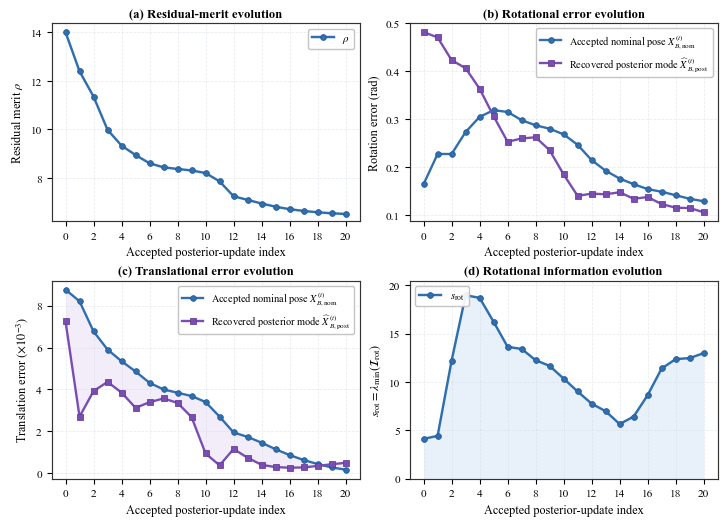

[Saved] exp2CB_false_confidence_seed44_posterior_evolution_core_refined.pdf


In [29]:
plot_exp2CB_posterior_evolution_core(
    trace_records_exp2CB,
    save_path="exp2CB_false_confidence_seed44_posterior_evolution_core_refined.pdf",
)

## G1 : F 参数演化图

In [30]:
# ============================================================
# Figure 2:
# Evolution of the Matrix-Fisher rotational parameter F
# Refined version:
# - Left: s1, s2, s3, plus tr(S)=s1+s2+s3
# - Right: local concentration coefficients
#          kappa_1=s2+s3, kappa_2=s1+s3, kappa_3=s1+s2
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Global plotting style
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# ------------------------------------------------------------
# Color palette
# ------------------------------------------------------------
C_RED = "#DA4139"
C_PURPLE = "#565AA7"
C_BLUE = "#6EA9CF"
C_GREEN = "#62B44A"        # bright green for tr(S)

C_RED_DARK = "#B4322C"
C_PURPLE_DARK = "#45498E"
C_BLUE_DARK = "#4E88AE"
C_GREEN_DARK = "#438B31"

C_GRID = "#C9D2DC"
C_SPINE = "#333333"


def plot_exp2CB_F_parameter_evolution(
    records,
    *,
    save_path="exp2CB_F_parameter_evolution_refined.pdf",
):
    # ========================================================
    # 1. Extract data
    # ========================================================
    state = np.array([r["state_id"] for r in records], dtype=int)

    F_s1 = np.array([r["F_s1"] for r in records], dtype=float)
    F_s2 = np.array([r["F_s2"] for r in records], dtype=float)
    F_s3 = np.array([r["F_s3"] for r in records], dtype=float)

    F_traceS = np.array([r["F_traceS"] for r in records], dtype=float)

    # Local concentration coefficients around the MF mode:
    #   kappa_1 = s2 + s3
    #   kappa_2 = s1 + s3
    #   kappa_3 = s1 + s2
    kappa_1 = F_s2 + F_s3
    kappa_2 = F_s1 + F_s3
    kappa_3 = F_s1 + F_s2

    # ========================================================
    # 2. Figure canvas
    # ========================================================
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(7.16, 2.95),   # IEEE double-column friendly
        constrained_layout=True,
    )

    LINEWIDTH = 1.7
    MARKER_SIZE = 4.1
    MARKER_EDGEWIDTH = 0.55

    def refine_axis(ax):
        ax.grid(
            True,
            linestyle="--",
            linewidth=0.55,
            alpha=0.42,
            color=C_GRID,
            zorder=0,
        )

        for spine in ax.spines.values():
            spine.set_linewidth(0.85)
            spine.set_color(C_SPINE)

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=8.2,
            width=0.8,
            length=3.5,
        )

        ax.set_xticks(np.arange(0, len(state), 2))

    # ========================================================
    # (a) Singular-value evolution of F + trace(S)
    # ========================================================
    ax = axes[0]

    line_s1, = ax.plot(
        state,
        F_s1,
        color=C_RED,
        marker="o",
        markersize=MARKER_SIZE,
        markerfacecolor=C_RED,
        markeredgecolor=C_RED_DARK,
        markeredgewidth=MARKER_EDGEWIDTH,
        linewidth=LINEWIDTH,
        label=r"largest $s_1(F)$",
        zorder=3,
    )

    line_s2, = ax.plot(
        state,
        F_s2,
        color=C_PURPLE,
        marker="s",
        markersize=MARKER_SIZE,
        markerfacecolor=C_PURPLE,
        markeredgecolor=C_PURPLE_DARK,
        markeredgewidth=MARKER_EDGEWIDTH,
        linewidth=LINEWIDTH,
        label=r"middle $s_2(F)$",
        zorder=3,
    )

    line_s3, = ax.plot(
        state,
        F_s3,
        color=C_BLUE,
        marker="^",
        markersize=MARKER_SIZE,
        markerfacecolor=C_BLUE,
        markeredgecolor=C_BLUE_DARK,
        markeredgewidth=MARKER_EDGEWIDTH,
        linewidth=LINEWIDTH,
        label=r"smallest $s_3(F)$",
        zorder=3,
    )

    ax.set_xlabel("Accepted posterior-update index", fontsize=8.8)
    ax.set_ylabel("Singular value", fontsize=8.8)
    ax.set_title(
        r"(a) Spectral evolution of $F$",
        fontsize=9.2,
        fontweight="bold",
        pad=4,
    )

    refine_axis(ax)

    # --------------------------------------------------------
    # Add tr(S) on a secondary y-axis in the SAME left panel
    # --------------------------------------------------------
    ax_trace = ax.twinx()

    line_trace, = ax_trace.plot(
        state,
        F_traceS,
        color=C_GREEN,
        linestyle="--",
        marker=None,
        linewidth=1.95,
        label=r"$\operatorname{tr}(S)=s_1+s_2+s_3$",
        zorder=2,
    )

    ax_trace.set_ylabel(
        r"Spectral sum $\operatorname{tr}(S)$",
        fontsize=8.6,
        color=C_GREEN_DARK,
    )

    ax_trace.tick_params(
        axis="y",
        which="major",
        labelsize=8.0,
        width=0.8,
        length=3.5,
        colors=C_GREEN_DARK,
    )

    ax_trace.spines["right"].set_linewidth(0.85)
    ax_trace.spines["right"].set_color(C_GREEN_DARK)
    ax_trace.grid(False)

    # Combined legend for left panel
    ax.legend(
        handles=[line_s1, line_s2, line_s3, line_trace],
        fontsize=6.8,
        frameon=True,
        fancybox=True,
        framealpha=0.92,
        edgecolor="#BFBFBF",
        facecolor="white",
        loc="upper left",
    )

    # ========================================================
    # (b) Local concentration coefficients
    # ========================================================
    ax = axes[1]

    ax.plot(
        state,
        kappa_1,
        color=C_RED,
        marker="o",
        markersize=MARKER_SIZE,
        markerfacecolor=C_RED,
        markeredgecolor=C_RED_DARK,
        markeredgewidth=MARKER_EDGEWIDTH,
        linewidth=LINEWIDTH,
        label=r"$\kappa_1=s_2+s_3$",
        zorder=3,
    )

    ax.plot(
        state,
        kappa_2,
        color=C_PURPLE,
        marker="s",
        markersize=MARKER_SIZE,
        markerfacecolor=C_PURPLE,
        markeredgecolor=C_PURPLE_DARK,
        markeredgewidth=MARKER_EDGEWIDTH,
        linewidth=LINEWIDTH,
        label=r"$\kappa_2=s_1+s_3$",
        zorder=3,
    )

    ax.plot(
        state,
        kappa_3,
        color=C_BLUE,
        marker="^",
        markersize=MARKER_SIZE,
        markerfacecolor=C_BLUE,
        markeredgecolor=C_BLUE_DARK,
        markeredgewidth=MARKER_EDGEWIDTH,
        linewidth=LINEWIDTH,
        label=r"$\kappa_3=s_1+s_2$",
        zorder=3,
    )

    ax.set_xlabel("Accepted posterior-update index", fontsize=8.8)
    ax.set_ylabel(r"Local concentration coefficient $\kappa_i$", fontsize=8.8)
    ax.set_title(
        r"(b) Local concentration coefficients",
        fontsize=9.2,
        fontweight="bold",
        pad=4,
    )

    refine_axis(ax)

    ax.legend(
        fontsize=7.0,
        frameon=True,
        fancybox=True,
        framealpha=0.92,
        edgecolor="#BFBFBF",
        facecolor="white",
        loc="upper left",
    )
    

    # ========================================================
    # 3. Save and show
    # ========================================================
    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()
    print(f"[Saved] {save_path}")

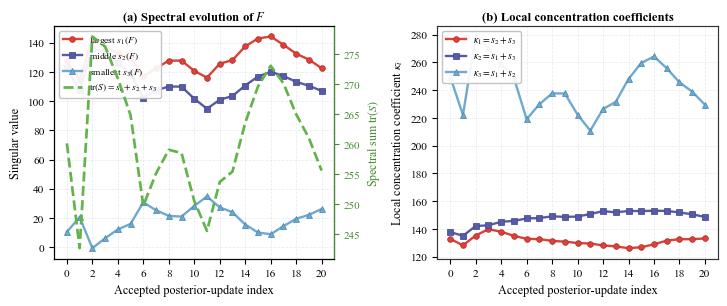

[Saved] exp2CB_false_confidence_seed44_F_parameter_evolution_refined.pdf


In [31]:
plot_exp2CB_F_parameter_evolution(
    trace_records_exp2CB,
    save_path="exp2CB_false_confidence_seed44_F_parameter_evolution_refined.pdf",
)

## Cell H1：自动挑选 snapshot states

In [33]:
# ============================================================
# Select representative F snapshots for MF visualization
# ============================================================

def exp2CB_select_snapshot_indices(n_states: int):
    if n_states <= 0:
        return []

    idx = [0]

    if n_states >= 2:
        idx.append(1)

    if n_states >= 3:
        idx.append(2)

    if n_states >= 5:
        idx.append(n_states // 2)

    if n_states >= 2:
        idx.append(n_states - 1)

    return sorted(set(idx))


snapshot_indices_exp2CB = exp2CB_select_snapshot_indices(
    len(trace_records_exp2CB)
)

print("Selected snapshot state indices:", snapshot_indices_exp2CB)

Selected snapshot state indices: [0, 1, 2, 10, 20]


## Cell H2：导出这些 F 矩阵

In [34]:
# ============================================================
# Export F snapshots
# ============================================================

F_snapshot_records_exp2CB = []

for idx in snapshot_indices_exp2CB:
    rec = trace_records_exp2CB[idx]

    F_snapshot_records_exp2CB.append({
        "snapshot_id": len(F_snapshot_records_exp2CB),
        "state_id": int(rec["state_id"]),
        "outer_t": int(rec["outer_t"]),
        "rho": float(rec["rho"]),
        "s_rot": float(rec["s_rot"]),
        "mode_eR": float(rec["mode_eR"]),
        "F_matrix": np.asarray(rec["F_matrix"], dtype=float).copy(),
    })

snapshot_F_stack_exp2CB = np.stack(
    [r["F_matrix"] for r in F_snapshot_records_exp2CB],
    axis=0,
)

snapshot_path_exp2CB = f"{EXP2CB_OUTPUT_PREFIX}_F_snapshots_for_MF_visualization.npz"

np.savez(
    snapshot_path_exp2CB,
    F_snapshots=snapshot_F_stack_exp2CB,
    state_ids=np.array([r["state_id"] for r in F_snapshot_records_exp2CB], dtype=int),
    outer_ts=np.array([r["outer_t"] for r in F_snapshot_records_exp2CB], dtype=int),
    rhos=np.array([r["rho"] for r in F_snapshot_records_exp2CB], dtype=float),
    s_rots=np.array([r["s_rot"] for r in F_snapshot_records_exp2CB], dtype=float),
    mode_eRs=np.array([r["mode_eR"] for r in F_snapshot_records_exp2CB], dtype=float),
)

print(f"[Saved] {snapshot_path_exp2CB}")

[Saved] exp2CB_mild_seed44_F_snapshots_for_MF_visualization.npz


## Cell H3：打印 snapshot 信息

In [35]:
snapshot_table_columns_exp2CB = [
    "snapshot_id",
    "state_id",
    "outer_t",
    "rho",
    "s_rot",
    "mode_eR",
]

exp2CB_print_table(
    F_snapshot_records_exp2CB,
    snapshot_table_columns_exp2CB,
    title="Selected F snapshots for Matrix-Fisher sphere visualization",
    max_width=16,
    precision=4,
)


Selected F snapshots for Matrix-Fisher sphere visualization
snapshot_id | state_id | outer_t | rho     | s_rot   | mode_eR
------------+----------+---------+---------+---------+--------
0           | 0        | -1      | 14.0110 | 4.1216  | 0.4814 
1           | 1        | 0       | 12.3986 | 4.4254  | 0.4704 
2           | 2        | 1       | 11.3534 | 12.2006 | 0.4230 
3           | 10       | 9       | 8.2021  | 10.3501 | 0.1848 
4           | 20       | 19      | 6.5142  | 12.9807 | 0.1061 


#  Evolution of F (3D visulization)

## MF Sampling function 

In [36]:
# ============================================================
# Supplementary Experiment 2C-b:
# Matrix-Fisher rotational-marginal sampler for F snapshots
# Adapted for direct use in the current notebook
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from matplotlib import cm
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


# ------------------------------------------------------------
# Global figure style
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


# ============================================================
# 1. Quaternion / rotation helpers
# ============================================================

def mfviz_canonicalize_quaternion(q: np.ndarray) -> np.ndarray:
    q = np.asarray(q, dtype=float)
    q = q / np.linalg.norm(q)
    if q[0] < 0:
        q = -q
    return q


def mfviz_quat_to_rot(q: np.ndarray) -> np.ndarray:
    """
    Scalar-first quaternion q=[q0,q1,q2,q3]^T to SO(3).
    """
    q = mfviz_canonicalize_quaternion(q)
    q0, q1, q2, q3 = q

    R = np.array([
        [
            q0*q0 + q1*q1 - q2*q2 - q3*q3,
            2*(q1*q2 - q0*q3),
            2*(q1*q3 + q0*q2),
        ],
        [
            2*(q1*q2 + q0*q3),
            q0*q0 - q1*q1 + q2*q2 - q3*q3,
            2*(q2*q3 - q0*q1),
        ],
        [
            2*(q1*q3 - q0*q2),
            2*(q2*q3 + q0*q1),
            q0*q0 - q1*q1 - q2*q2 + q3*q3,
        ],
    ], dtype=float)

    return R


# ============================================================
# 2. Proper SVD and Bingham representation
# ============================================================

def mfviz_proper_svd(F: np.ndarray):
    """
    Proper SVD:
        F = U S V^T,
        U,V in SO(3),
        S = diag(s1,s2,s3), with signed s3 allowed.
    """
    F = np.asarray(F, dtype=float)

    U0, sigma, Vt0 = np.linalg.svd(F)
    V0 = Vt0.T

    sign_u = 1.0 if np.linalg.det(U0) > 0 else -1.0
    sign_v = 1.0 if np.linalg.det(V0) > 0 else -1.0

    Du = np.diag([1.0, 1.0, sign_u])
    Dv = np.diag([1.0, 1.0, sign_v])

    U = U0 @ Du
    V = V0 @ Dv
    S = Du @ np.diag(sigma) @ Dv
    s = np.diag(S).copy()

    err = np.linalg.norm(F - U @ S @ V.T, ord="fro")
    if err > 1e-8 * (1.0 + np.linalg.norm(F, ord="fro")):
        raise ValueError(f"Proper SVD reconstruction failed, error={err:.3e}")

    return U, S, V, s


def mfviz_mf_diag_to_bingham_params(s: np.ndarray):
    """
    Convert Matrix-Fisher diagonal parameter s=(s1,s2,s3)
    to equivalent shifted Bingham log-density parameters on S^3.
    """
    s1, s2, s3 = np.asarray(s, dtype=float)

    a = np.array([
        s1 + s2 + s3,
        s1 - s2 - s3,
        -s1 + s2 - s3,
        -s1 - s2 + s3,
    ], dtype=float)

    z = a - np.max(a)
    return a, z


def mfviz_build_acg_shape(z: np.ndarray, c: float = 1.0):
    """
    ACG proposal:
        K = diag(c-z_j)
    """
    z = np.asarray(z, dtype=float)
    kappa = c - z

    if np.any(kappa <= 0):
        raise ValueError(
            "ACG shape construction failed: some c-z_j <= 0. "
            "Try a larger c."
        )

    K = np.diag(kappa)
    Sigma_g = np.diag(1.0 / kappa)
    return K, Sigma_g, kappa


def mfviz_sample_acg(Sigma_g: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    y = rng.multivariate_normal(mean=np.zeros(4), cov=Sigma_g)
    q = y / np.linalg.norm(y)
    return mfviz_canonicalize_quaternion(q)


def mfviz_log_target_bingham(q: np.ndarray, z: np.ndarray) -> float:
    q = mfviz_canonicalize_quaternion(q)
    return float(np.dot(z, q * q))


def mfviz_log_proposal_acg(q: np.ndarray, K: np.ndarray) -> float:
    q = mfviz_canonicalize_quaternion(q)
    val = float(q @ K @ q)
    return float(-2.0 * np.log(val))


# ============================================================
# 3. Matrix-Fisher sampler on SO(3)
# ============================================================

def mfviz_sample_mf_so3_independence_mh(
    F: np.ndarray,
    N: int = 5000,
    burnin: int = 800,
    thin: int = 1,
    c: float = 1.0,
    seed: int = 2026,
):
    """
    Sample R ~ MF(F) using the same Independence-MH / Bingham-ACG strategy
    used in the previous Matrix-Fisher visualization notebook.
    """
    rng = np.random.default_rng(seed)

    # Step 1: proper SVD
    U, S, V, s = mfviz_proper_svd(F)

    # Step 2: Bingham parameterization
    a, z = mfviz_mf_diag_to_bingham_params(s)

    # Step 3: ACG proposal
    K, Sigma_g, kappa = mfviz_build_acg_shape(z, c=c)

    # Step 4: initialize
    q_current = mfviz_sample_acg(Sigma_g, rng)
    log_pi_current = mfviz_log_target_bingham(q_current, z)
    log_g_current = mfviz_log_proposal_acg(q_current, K)

    accepted_flags = []
    stored_q = []
    stored_R0 = []
    stored_R = []

    t = 0
    while len(stored_R) < N:
        q_prop = mfviz_sample_acg(Sigma_g, rng)
        log_pi_prop = mfviz_log_target_bingham(q_prop, z)
        log_g_prop = mfviz_log_proposal_acg(q_prop, K)

        Delta = (
            log_pi_prop
            - log_pi_current
            + log_g_current
            - log_g_prop
        )

        if np.log(rng.random()) <= min(0.0, Delta):
            q_current = q_prop
            log_pi_current = log_pi_prop
            log_g_current = log_g_prop
            accepted = 1
        else:
            accepted = 0

        accepted_flags.append(accepted)
        t += 1

        if t > burnin and ((t - burnin) % thin == 0):
            R0 = mfviz_quat_to_rot(q_current)
            R = U @ R0 @ V.T

            stored_q.append(q_current.copy())
            stored_R0.append(R0.copy())
            stored_R.append(R.copy())

    return {
        "F": np.asarray(F, dtype=float),
        "U": U,
        "S": S,
        "V": V,
        "s": s,
        "a": a,
        "z": z,
        "K": K,
        "Sigma_g": Sigma_g,
        "kappa": kappa,
        "stored_q": np.asarray(stored_q),
        "stored_R0": np.asarray(stored_R0),
        "stored_R": np.asarray(stored_R),
        "acceptance_rate": float(np.mean(accepted_flags)),
        "N": int(N),
        "burnin": int(burnin),
        "thin": int(thin),
        "c": float(c),
        "seed": int(seed),
    }

## Cell 2：选择 3 个 snapshot 并采样

In [37]:
# ============================================================
# Supplementary Experiment 2C-b:
# Select three representative snapshots and sample
# R ~ MF(F^{(t)})
# ============================================================

EXP2CB_ZOOM_STATE_IDS = [0, 5, 17]

EXP2CB_ZOOM_SAMPLE_N = 6000
EXP2CB_ZOOM_BURNIN = 1000
EXP2CB_ZOOM_THIN = 1
EXP2CB_ZOOM_C = 1.0
EXP2CB_ZOOM_SEED_BASE = 42000


def exp2CB_select_three_F_snapshots(
    trace_records,
    selected_state_ids,
):
    rec_by_state = {
        int(r["state_id"]): r
        for r in trace_records
    }

    selected = []

    for sid in selected_state_ids:
        if sid not in rec_by_state:
            raise ValueError(
                f"state_id={sid} is not present. "
                f"Available states: {sorted(rec_by_state.keys())}"
            )

        rec = rec_by_state[sid]

        selected.append({
            "state_id": int(rec["state_id"]),
            "outer_t": int(rec["outer_t"]),
            "rho": float(rec["rho"]),
            "s_rot": float(rec["s_rot"]),
            "mode_eR": float(rec["mode_eR"]),
            "F_matrix": np.asarray(rec["F_matrix"], dtype=float).copy(),
        })

    return selected


def exp2CB_sample_three_F_snapshots(
    selected_snapshots,
    *,
    N=6000,
    burnin=1000,
    thin=1,
    c=1.0,
    seed_base=42000,
):
    sampled = []

    print("=" * 104)
    print("Sampling three representative rotational marginals")
    print("=" * 104)

    for rec in selected_snapshots:
        sid = int(rec["state_id"])

        sample_res = mfviz_sample_mf_so3_independence_mh(
            F=rec["F_matrix"],
            N=N,
            burnin=burnin,
            thin=thin,
            c=c,
            seed=seed_base + sid,
        )

        out = dict(rec)
        out["sample_result"] = sample_res
        out["acceptance_rate"] = float(sample_res["acceptance_rate"])

        sampled.append(out)

        print(
            f"state={sid:02d} | "
            f"outer_t={rec['outer_t']:02d} | "
            f"rho={rec['rho']:.4f} | "
            f"s_rot={rec['s_rot']:.4f} | "
            f"acc={out['acceptance_rate']:.4f}"
        )

    print("=" * 104)
    return sampled


exp2CB_zoom_snapshot_records = exp2CB_select_three_F_snapshots(
    trace_records_exp2CB,
    EXP2CB_ZOOM_STATE_IDS,
)

exp2CB_zoom_sampled_snapshots = exp2CB_sample_three_F_snapshots(
    exp2CB_zoom_snapshot_records,
    N=EXP2CB_ZOOM_SAMPLE_N,
    burnin=EXP2CB_ZOOM_BURNIN,
    thin=EXP2CB_ZOOM_THIN,
    c=EXP2CB_ZOOM_C,
    seed_base=EXP2CB_ZOOM_SEED_BASE,
)

Sampling three representative rotational marginals
state=00 | outer_t=-1 | rho=14.0110 | s_rot=4.1216 | acc=0.4291
state=05 | outer_t=04 | rho=8.9435 | s_rot=16.2188 | acc=0.4251
state=17 | outer_t=16 | rho=6.6380 | s_rot=11.3951 | acc=0.4233


## Cell 3：局部球面 cap 投影与密度估计

In [38]:
# ============================================================
# Local spherical-cap projection utilities
# ============================================================

import numpy as np
from matplotlib.colors import LinearSegmentedColormap, PowerNorm


# ------------------------------------------------------------
# Colormap close to the reference figure:
# blue -> cyan -> green -> yellow -> orange
# ------------------------------------------------------------
MF_CAP_CMAP = LinearSegmentedColormap.from_list(
    "mf_cap_density",
    [
        "#3F3AAE",   # blue-violet
        "#355CC9",   # rich blue
        "#2387D6",   # blue
        "#18B7D4",   # cyan
        "#34D19C",   # green-cyan
        "#BFEA5A",   # yellow-green
        "#F4E04D",   # yellow
        "#FDB52A",   # orange-yellow hotspot
    ],
    N=256,
)
MF_CAP_CMAP.set_bad(color="white")


def exp2CB_unit(v):
    v = np.asarray(v, dtype=float).reshape(3)
    return v / max(np.linalg.norm(v), 1e-12)


def exp2CB_tangent_basis(center):
    """
    Build two orthonormal tangent directions at a unit vector 'center'.
    """
    c = exp2CB_unit(center)

    trial = np.array([0.0, 0.0, 1.0])
    if abs(np.dot(c, trial)) > 0.92:
        trial = np.array([0.0, 1.0, 0.0])

    t1 = trial - np.dot(trial, c) * c
    t1 = exp2CB_unit(t1)
    t2 = np.cross(c, t1)
    t2 = exp2CB_unit(t2)

    return t1, t2


def exp2CB_sphere_exp_from_tangent(center, t1, t2, U, V):
    """
    Map local tangent coordinates (U,V) to the unit sphere using
    the exponential map on S^2.
    U,V are angular coordinates in radians.
    """
    center = exp2CB_unit(center)

    W = U[..., None] * t1 + V[..., None] * t2
    theta = np.linalg.norm(W, axis=-1)

    dirs = np.zeros_like(W)

    small = theta < 1e-12
    nonsmall = ~small

    dirs[small] = center

    if np.any(nonsmall):
        W_hat = W[nonsmall] / theta[nonsmall][..., None]
        dirs[nonsmall] = (
            np.cos(theta[nonsmall])[..., None] * center
            + np.sin(theta[nonsmall])[..., None] * W_hat
        )

    dirs = dirs / np.maximum(np.linalg.norm(dirs, axis=-1, keepdims=True), 1e-12)
    return dirs


def exp2CB_spherical_log_to_tangent(center, t1, t2, y):
    """
    Project a sphere point y back to local tangent coordinates at 'center'.
    Output is (u,v) in radians.
    """
    c = exp2CB_unit(center)
    y = exp2CB_unit(y)

    cosang = np.clip(np.dot(c, y), -1.0, 1.0)
    theta = np.arccos(cosang)

    if theta < 1e-12:
        return 0.0, 0.0

    tangent_dir = y - cosang * c
    tangent_dir = exp2CB_unit(tangent_dir)

    w = theta * tangent_dir

    u = float(np.dot(w, t1))
    v = float(np.dot(w, t2))
    return u, v


def exp2CB_make_local_cap_grid(
    center,
    *,
    cap_deg=18.0,
    n_grid=181,
):
    """
    Construct a local tangent-plane grid centered at the chosen sphere direction.
    """
    t1, t2 = exp2CB_tangent_basis(center)

    cap_rad = np.deg2rad(cap_deg)
    lin = np.linspace(-cap_rad, cap_rad, n_grid)
    U, V = np.meshgrid(lin, lin)

    radius = np.sqrt(U**2 + V**2)
    mask = radius <= cap_rad

    sphere_dirs = exp2CB_sphere_exp_from_tangent(center, t1, t2, U, V)

    return {
        "center": exp2CB_unit(center),
        "t1": t1,
        "t2": t2,
        "U": U,
        "V": V,
        "U_deg": np.rad2deg(U),
        "V_deg": np.rad2deg(V),
        "mask": mask,
        "sphere_dirs": sphere_dirs,
        "cap_deg": cap_deg,
    }


def exp2CB_extract_marginal_points(sample_result, col_id):
    """
    Extract samples of R e_i from stored rotations.
    col_id = 0,1,2 corresponds to Re1, Re2, Re3.
    """
    R_samples = np.asarray(sample_result["stored_R"], dtype=float)
    pts = R_samples[:, :, col_id]
    pts = pts / np.maximum(np.linalg.norm(pts, axis=1, keepdims=True), 1e-12)
    return pts


def exp2CB_get_marginal_mode(sample_result, col_id):
    """
    For R~MF(F), the mode rotation is U V^T.
    The marginal directional mode for R e_i is (U V^T) e_i.
    """
    U = np.asarray(sample_result["U"], dtype=float)
    V = np.asarray(sample_result["V"], dtype=float)

    R_mode = U @ V.T
    mode_dir = R_mode[:, col_id]
    return exp2CB_unit(mode_dir)


def exp2CB_local_cap_kde(
    points,
    sphere_dirs,
    mask,
    *,
    kde_kappa=160.0,
    chunk_size=512,
):
    """
    Spherical KDE:
        p(x) ~ mean exp(kappa (x^T p_i - 1))
    evaluated only on the local cap.
    """
    pts = np.asarray(points, dtype=float)
    pts = pts / np.maximum(np.linalg.norm(pts, axis=1, keepdims=True), 1e-12)

    G = sphere_dirs.reshape(-1, 3)
    dens = np.zeros(G.shape[0], dtype=float)

    for start in range(0, G.shape[0], chunk_size):
        end = min(start + chunk_size, G.shape[0])
        G_chunk = G[start:end]

        dots = pts @ G_chunk.T
        kern = np.exp(kde_kappa * (dots - 1.0))
        dens[start:end] = np.mean(kern, axis=0)

    dens = dens.reshape(sphere_dirs.shape[:2])
    dens = np.where(mask, dens, np.nan)

    return dens

## 计算 9 个局部 cap 密度

In [39]:
# ============================================================
# Precompute local-cap densities:
# 3 marginals × 3 snapshots
# ============================================================

EXP2CB_CAP_DEG = 18.0
EXP2CB_CAP_N_GRID = 181
EXP2CB_CAP_KDE_KAPPA = 160.0


def exp2CB_prepare_zoomed_cap_panels(
    sampled_snapshots,
    *,
    cap_deg=18.0,
    n_grid=181,
    kde_kappa=160.0,
):
    n_cols = len(sampled_snapshots)
    if n_cols != 3:
        raise ValueError("This figure is designed for exactly 3 snapshots.")

    panel_data = [[None for _ in range(n_cols)] for _ in range(3)]
    cap_frames = []

    # --------------------------------------------------------
    # For each marginal row Re_i:
    # use state 0 marginal mode as the common local-cap center
    # --------------------------------------------------------
    for row in range(3):
        initial_mode = exp2CB_get_marginal_mode(
            sampled_snapshots[0]["sample_result"],
            col_id=row,
        )

        cap_grid = exp2CB_make_local_cap_grid(
            initial_mode,
            cap_deg=cap_deg,
            n_grid=n_grid,
        )
        cap_frames.append(cap_grid)

        for col, snap in enumerate(sampled_snapshots):
            sample_res = snap["sample_result"]

            pts = exp2CB_extract_marginal_points(
                sample_res,
                col_id=row,
            )

            density = exp2CB_local_cap_kde(
                pts,
                cap_grid["sphere_dirs"],
                cap_grid["mask"],
                kde_kappa=kde_kappa,
            )

            current_mode = exp2CB_get_marginal_mode(
                sample_res,
                col_id=row,
            )

            mode_u, mode_v = exp2CB_spherical_log_to_tangent(
                cap_grid["center"],
                cap_grid["t1"],
                cap_grid["t2"],
                current_mode,
            )

            panel_data[row][col] = {
                "density": density,
                "mode_u_deg": np.rad2deg(mode_u),
                "mode_v_deg": np.rad2deg(mode_v),
            }

    # --------------------------------------------------------
    # Row-wise global normalization:
    # same scale across initial/intermediate/final
    # within each marginal Re_i.
    # --------------------------------------------------------
    row_vmax = []

    for row in range(3):
        vmax_row = max(
            np.nanmax(panel_data[row][col]["density"])
            for col in range(n_cols)
        )
        row_vmax.append(float(vmax_row))

    return panel_data, cap_frames, row_vmax


exp2CB_zoom_panel_data, exp2CB_zoom_cap_frames, exp2CB_zoom_row_vmax = (
    exp2CB_prepare_zoomed_cap_panels(
        exp2CB_zoom_sampled_snapshots,
        cap_deg=EXP2CB_CAP_DEG,
        n_grid=EXP2CB_CAP_N_GRID,
        kde_kappa=EXP2CB_CAP_KDE_KAPPA,
    )
)

## 3 × 3 zoomed cap view

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable

# ============================================================
# Global plotting style
# ============================================================
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
})

# ============================================================
# Figure:
# Local zoomed views of rotational-marginal snapshots
# ============================================================

def plot_exp2CB_zoomed_rotational_marginal_caps(
    sampled_snapshots,
    panel_data,
    cap_frames,
    row_vmax,
    *,
    save_path_pdf="exp2CB_false_confidence_seed44_zoomed_rotational_marginal_caps.pdf",
    save_path_png="exp2CB_false_confidence_seed44_zoomed_rotational_marginal_caps.png",
    gamma=0.62,
    contour_levels=24,
    cmap=None,   # if None, use MF_CAP_CMAP if defined, otherwise "viridis"
):
    """
    Plot 3x3 local zoomed-cap views of rotational-marginal snapshots.

    Rows:
        Re1, Re2, Re3
    Columns:
        initial / intermediate / final

    Notes
    -----
    - Each row uses its own normalization:
          vmax = row_vmax[row]
      so each row gets its own colorbar.
    - '+' marks the reference center.
    - 'x' marks the current posterior mode.
    """

    # --------------------------------------------------------
    # Colormap
    # --------------------------------------------------------
    if cmap is None:
        if "MF_CAP_CMAP" in globals():
            cmap = MF_CAP_CMAP
        else:
            cmap = "viridis"

    row_labels = [r"$R e_1$", r"$R e_2$", r"$R e_3$"]
    col_labels = ["initial", "intermediate", "final"]

    # --------------------------------------------------------
    # Figure canvas
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        3,
        3,
        figsize=(8.2, 6.8),
        constrained_layout=False,
    )
    fig.patch.set_facecolor("white")

    fig.subplots_adjust(
        top=0.65,     # 数值越小，下面子图整体越往下，图例和子图间距越大
        wspace=0.18,
        hspace=0.28
    )

    # Save one mappable handle per row for colorbar
    row_mappables = []

    # --------------------------------------------------------
    # Main panel drawing
    # --------------------------------------------------------
    for row in range(3):
        frame = cap_frames[row]
        U_deg = frame["U_deg"]
        V_deg = frame["V_deg"]
        cap_deg = frame["cap_deg"]

        shared_norm = PowerNorm(
            gamma=gamma,
            vmin=0.0,
            vmax=1.0,
        )

        row_mappable = ScalarMappable(norm=shared_norm, cmap=cmap)
        row_mappables.append(row_mappable)

        for col in range(3):
            ax = axes[row, col]
            panel = panel_data[row][col]
            density = panel["density"]
            density_plot = density / max(float(row_vmax[row]), 1e-12)

            
            

            cf = ax.contourf(
                U_deg,
                V_deg,
                density_plot,
                levels=np.linspace(0.0, 1.0, contour_levels),
                cmap=cmap,
                norm=shared_norm,
                extend="max",
            )

            ax.contour(
                U_deg,
                V_deg,
                density_plot,
                levels=np.linspace(0.15, 0.95, 8),
                colors="white",
                linewidths=0.30,
                alpha=0.35,
            )


            

            # Circular cap boundary
            boundary = plt.Circle(
                (0.0, 0.0),
                cap_deg,
                fill=False,
                linewidth=0.9,
                color="#4A4A4A",
                alpha=0.95,
            )
            ax.add_patch(boundary)

            # Reference center
            ax.plot(
                0.0,
                0.0,
                marker="+",
                markersize=5.6,
                markeredgewidth=1.0,
                color="black",
                zorder=10,
            )

            # Current posterior mode
            ax.plot(
                panel["mode_u_deg"],
                panel["mode_v_deg"],
                marker="x",
                markersize=5.2,
                markeredgewidth=1.15,
                color="black",
                zorder=11,
            )

            # Axis range
            ax.set_xlim(-cap_deg, cap_deg)
            ax.set_ylim(-cap_deg, cap_deg)
            ax.set_aspect("equal", adjustable="box")

            # Ticks
            ax.set_xticks([-15, 0, 15])
            ax.set_yticks([-15, 0, 15])
            ax.tick_params(
                axis="both",
                labelsize=7.3,
                width=0.7,
                length=2.7,
            )

            # Remove panel box spines
            for spine in ax.spines.values():
                spine.set_visible(False)

            
            # --------------------------------------------------------
            if row != 2:
                ax.set_xticklabels([])

            if col != 0:
                ax.set_yticklabels([])

            # Column titles on first row
            if row == 0:
                snap = sampled_snapshots[col]
                sid = int(snap["state_id"])
                srot = float(snap["s_rot"])

                ax.set_title(
                    rf"{col_labels[col]} snapshot"
                    + "\n"
                    + rf"state {sid}, $s_{{\mathrm{{rot}}}}={srot:.2f}$",
                    fontsize=8.9,
                    fontweight="bold",
                    pad=7.0,
                )

    

    # --------------------------------------------------------
    # Row labels (far left)
    # --------------------------------------------------------
    row_y = [0.772, 0.495, 0.217]
    for y, label in zip(row_y, row_labels):
        fig.text(
            0.020,
            y,
            label,
            fontsize=12.5,
            rotation=90,
            va="center",
            ha="center",
        )

    # --------------------------------------------------------
    # Figure title
    # --------------------------------------------------------
    fig.suptitle(
        r"Local spherical cap views of rotational-marginal snapshots",
        fontsize=16.5,
        fontweight="bold",
        y=0.975,
    )

    # --------------------------------------------------------
    # Marker legend
    # --------------------------------------------------------
    

    
    legend_handles = [
        Line2D(
            [0], [0],
            marker="+",
            color="black",
            linestyle="None",
            markersize=5.2,
            markeredgewidth=0.9,
            #label=r" $\bar{X}_B^{(t)}$",
            label=r"initial marginal center $R_{\mathrm{mode}}^{(0)} e_i$"
        ),
        Line2D(
            [0], [0],
            marker="x",
            color="black",
            linestyle="None",
            markersize=5.0,
            markeredgewidth=1.0,
            #label=r"posterior mode $\widehat{X}_B^{(t)}$",
            label=r"current marginal mode $R_{\mathrm{mode}}^{(t)} e_i$"
        ),
    ]

    
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.945),   # move upward
        ncol=2,
        frameon=True,
        fancybox=True,
        framealpha=0.88,
        fontsize=9.0,
        handletextpad=0.45,
        columnspacing=1.0,
        borderpad=0.35,
    )

    
    plt.subplots_adjust(
        left=0.14,
        right=0.88,
        bottom=0.11,
        top=0.83,
        wspace=0.23,
        hspace=0.35,
    )
    # Shared axis labels for the whole 3x3 panel 全局标题
    # --------------------------------------------------------
    fig.text(
        0.50,
        0.058,
        r"Local tangent offset $\Delta\theta_1$ (deg)",
        ha="center",
        va="center",
        fontsize=14.6,
    )

    fig.text(
        0.070,
        0.485,
        r"Local tangent offset $\Delta\theta_2$ (deg)",
        ha="center",
        va="center",
        rotation=90,
        fontsize=14.6,
    )

    
    sm = ScalarMappable(
        norm=shared_norm,
        cmap=cmap,
    )

    cax = fig.add_axes([0.895, 0.355, 0.018, 0.30])

    cb = fig.colorbar(sm, cax=cax)
    cb.ax.tick_params(labelsize=7.0, width=0.6, length=2.2)
    cb.outline.set_linewidth(0.7)

    cb.set_label(
        r"Row-wise normalized density",
        fontsize=7.6,
        rotation=90,
        labelpad=6,
    )

    # --------------------------------------------------------
    # Small note explaining color normalization
    # --------------------------------------------------------
    # fig.text(
    #     0.892,
    #     0.855,
    #     "Row-wise\nnormalized\nscale",
    #     fontsize=7.2,
    #     ha="center",
    #     va="bottom",
    # )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    fig.savefig(
        save_path_pdf,
        format="pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        save_path_png,
        dpi=350,
        bbox_inches="tight",
    )

    plt.show()

    print(f"[Saved] {save_path_pdf}")
    print(f"[Saved] {save_path_png}")

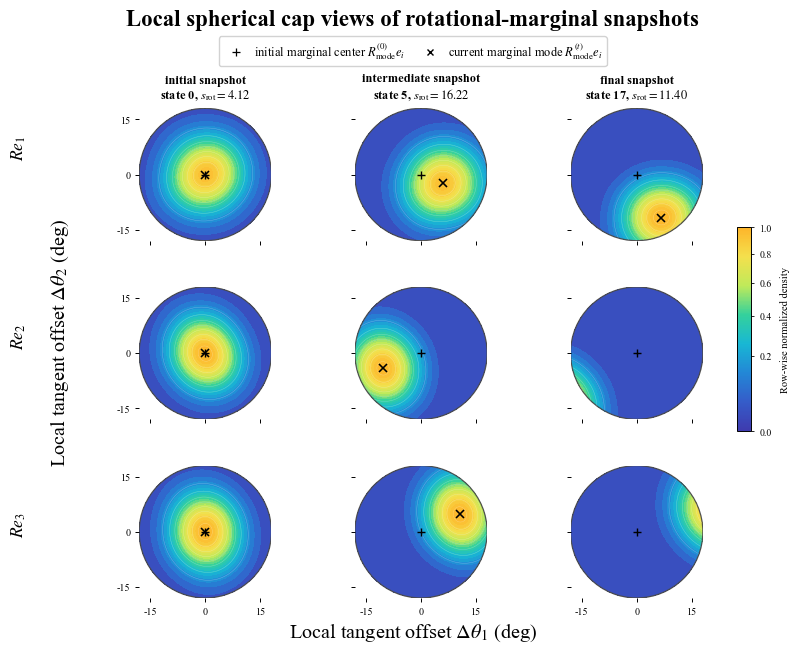

[Saved] exp2CB_false_confidence_seed44_zoomed_rotational_marginal_caps.pdf
[Saved] exp2CB_false_confidence_seed44_zoomed_rotational_marginal_caps.png


In [41]:
plot_exp2CB_zoomed_rotational_marginal_caps(
    exp2CB_zoom_sampled_snapshots,
    exp2CB_zoom_panel_data,
    exp2CB_zoom_cap_frames,
    exp2CB_zoom_row_vmax,
    save_path_pdf="exp2CB_false_confidence_seed44_zoomed_rotational_marginal_caps.pdf",
    save_path_png="exp2CB_false_confidence_seed44_zoomed_rotational_marginal_caps.png",
    gamma=0.62,
    contour_levels=24,
)

# mode 的轨迹图 可以看到mode 是如何演化的

In [42]:
# ============================================================
# Figure: local mode trajectory + contour evolution
# Directly adapted for current Experiment 2C notebook
# Required existing variable/function:
#   - trace_records_exp2CB
#   - sample_mf_so3_independence_mh(F, ...)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# Basic helpers
# ------------------------------------------------------------

def _unit(v, eps=1e-12):
    v = np.asarray(v, dtype=float).reshape(-1)
    n = np.linalg.norm(v)
    if n < eps:
        return v.copy()
    return v / n


def _mode_rotation_from_F(F: np.ndarray) -> np.ndarray:
    """
    Matrix-Fisher mode:
        R_mode = U diag(1,1,det(UV^T)) V^T
    for the standard SVD F = U Sigma V^T.
    """
    F = np.asarray(F, dtype=float).reshape(3, 3)
    U, _, Vt = np.linalg.svd(F)
    D = np.diag([1.0, 1.0, np.linalg.det(U @ Vt)])
    R_mode = U @ D @ Vt
    return R_mode


def _make_tangent_basis(center: np.ndarray):
    """
    Build an orthonormal tangent basis {b1, b2} at center on S^2.
    """
    c = _unit(center)

    # choose a helper vector not parallel to c
    if abs(c[2]) < 0.9:
        a = np.array([0.0, 0.0, 1.0], dtype=float)
    else:
        a = np.array([0.0, 1.0, 0.0], dtype=float)

    b1 = a - np.dot(a, c) * c
    b1 = _unit(b1)
    b2 = np.cross(c, b1)
    b2 = _unit(b2)

    return b1, b2


def _sphere_logmap_to_tangent_xy(points: np.ndarray, center: np.ndarray, b1: np.ndarray, b2: np.ndarray):
    """
    Log map on S^2 at 'center', then express tangent vectors in basis (b1,b2).

    Input:
        points : (N,3) unit vectors on S^2
        center : (3,)
        b1,b2  : tangent basis at center

    Return:
        xy_deg : (N,2), local tangent offsets in degrees
    """
    pts = np.asarray(points, dtype=float)
    c = _unit(center)

    dots = np.clip(pts @ c, -1.0, 1.0)
    theta = np.arccos(dots)  # geodesic angle

    tang = pts - dots[:, None] * c[None, :]
    tang_norm = np.linalg.norm(tang, axis=1)

    # unit tangent direction
    tang_dir = np.zeros_like(tang)
    mask = tang_norm > 1e-12
    tang_dir[mask] = tang[mask] / tang_norm[mask, None]

    # log-map vector in tangent space
    v = theta[:, None] * tang_dir   # shape (N,3), in radians

    x = v @ b1
    y = v @ b2
    xy = np.column_stack([x, y])

    return np.rad2deg(xy)


def _kde2d_on_local_grid(samples_xy_deg: np.ndarray,
                         cap_radius_deg: float = 18.0,
                         grid_size: int = 181,
                         bandwidth_deg: float = 4.5):
    """
    Simple isotropic Gaussian KDE on a fixed tangent-plane grid.

    Return:
        X, Y, Z
    """
    rmax = float(cap_radius_deg)
    x = np.linspace(-rmax, rmax, grid_size)
    y = np.linspace(-rmax, rmax, grid_size)
    X, Y = np.meshgrid(x, y)

    S = np.asarray(samples_xy_deg, dtype=float)
    if S.ndim != 2 or S.shape[1] != 2:
        raise ValueError("samples_xy_deg must have shape (N,2).")

    dx = X[:, :, None] - S[None, None, :, 0]
    dy = Y[:, :, None] - S[None, None, :, 1]

    h2 = float(bandwidth_deg) ** 2
    Z = np.exp(-0.5 * (dx * dx + dy * dy) / h2).mean(axis=2)
    Z /= (2.0 * np.pi * h2)

    # keep only circular cap region
    R2 = X**2 + Y**2
    Z = np.where(R2 <= rmax**2, Z, np.nan)

    return X, Y, Z


def _axis_vectors():
    return {
        "Re1": np.array([1.0, 0.0, 0.0], dtype=float),
        "Re2": np.array([0.0, 1.0, 0.0], dtype=float),
        "Re3": np.array([0.0, 0.0, 1.0], dtype=float),
    }


# ------------------------------------------------------------
# Main data builder
# ------------------------------------------------------------

def build_exp2CB_mode_trajectory_contour_data(
    records,
    *,
    snapshot_indices=None,
    sample_N=2800,
    burnin=400,
    thin=1,
    proposal_c=1.0,
    seed_base=2025,
    cap_radius_deg=18.0,
    bandwidth_deg=4.5,
    grid_size=181,
):
    """
    Build data for a cleaner figure:
        - 3 panels (Re1, Re2, Re3)
        - initial / intermediate / final contours
        - full posterior-mode trajectory across all accepted states

    Important design choice:
        All snapshots are shown in the SAME local tangent chart per row,
        centered at the INITIAL rotational-marginal mode direction.
        Therefore the reference center stays at (0,0) in each row.

    Parameters
    ----------
    records : list of dict
        your current trace_records_exp2CB
    snapshot_indices : tuple/list of length 3, optional
        indices in records, e.g. (0, 5, 17)
        if None -> use (0, len//2, len-1)
    """

    if len(records) == 0:
        raise ValueError("records is empty.")

    n_states = len(records)

    if snapshot_indices is None:
        snapshot_indices = (0, n_states // 2, n_states - 1)

    snapshot_indices = tuple(int(i) for i in snapshot_indices)
    if len(snapshot_indices) != 3:
        raise ValueError("snapshot_indices must contain exactly 3 indices.")
    if min(snapshot_indices) < 0 or max(snapshot_indices) >= n_states:
        raise ValueError("snapshot_indices out of valid range.")

    axis_map = _axis_vectors()

    # --------------------------------------------------------
    # Step 1: fixed reference centers (one per row)
    # Use the INITIAL snapshot's rotational mode
    # --------------------------------------------------------
    rec0 = records[snapshot_indices[0]]
    F0 = np.asarray(rec0["F_matrix"], dtype=float)
    R_mode0 = _mode_rotation_from_F(F0)

    row_data = {}
    for row_name, e in axis_map.items():
        ref_center = R_mode0 @ e
        b1, b2 = _make_tangent_basis(ref_center)

        row_data[row_name] = {
            "ref_center": ref_center,
            "basis_b1": b1,
            "basis_b2": b2,
            "trajectory_xy": [],
            "trajectory_state_id": [],
            "trajectory_outer_t": [],
            "trajectory_s_rot": [],
            "panels": [],
            "row_vmax": None,
        }

    # --------------------------------------------------------
    # Step 2: full mode trajectory across ALL states
    # (no sampling needed here)
    # --------------------------------------------------------
    for rec in records:
        F = np.asarray(rec["F_matrix"], dtype=float)
        R_mode = _mode_rotation_from_F(F)

        state_id = int(rec.get("state_id", 0))
        outer_t = int(rec.get("outer_t", state_id))
        s_rot = float(rec.get("s_rot", np.nan))

        for row_name, e in axis_map.items():
            center = row_data[row_name]["ref_center"]
            b1 = row_data[row_name]["basis_b1"]
            b2 = row_data[row_name]["basis_b2"]

            mode_dir = (R_mode @ e).reshape(1, 3)
            mode_xy = _sphere_logmap_to_tangent_xy(mode_dir, center, b1, b2)[0]

            row_data[row_name]["trajectory_xy"].append(mode_xy)
            row_data[row_name]["trajectory_state_id"].append(state_id)
            row_data[row_name]["trajectory_outer_t"].append(outer_t)
            row_data[row_name]["trajectory_s_rot"].append(s_rot)

    # convert to arrays
    for row_name in row_data:
        row_data[row_name]["trajectory_xy"] = np.asarray(row_data[row_name]["trajectory_xy"], dtype=float)
        row_data[row_name]["trajectory_state_id"] = np.asarray(row_data[row_name]["trajectory_state_id"], dtype=int)
        row_data[row_name]["trajectory_outer_t"] = np.asarray(row_data[row_name]["trajectory_outer_t"], dtype=int)
        row_data[row_name]["trajectory_s_rot"] = np.asarray(row_data[row_name]["trajectory_s_rot"], dtype=float)

    # --------------------------------------------------------
    # Step 3: sample only the 3 representative snapshots
    # and build local density contours
    # --------------------------------------------------------
    for j, idx in enumerate(snapshot_indices):
        rec = records[idx]
        F = np.asarray(rec["F_matrix"], dtype=float)

        state_id = int(rec.get("state_id", idx))
        outer_t = int(rec.get("outer_t", state_id))
        s_rot = float(rec.get("s_rot", np.nan))
        rho = float(rec.get("rho", np.nan))

        mf_res = mfviz_sample_mf_so3_independence_mh(
            F=F,
            N=sample_N,
            burnin=burnin,
            thin=thin,
            c=proposal_c,
            seed=seed_base + 97 * (j + 1),
        )

        R_samples = np.asarray(mf_res["stored_R"], dtype=float)
        R_mode = np.asarray(mf_res["U"], dtype=float) @ np.asarray(mf_res["V"], dtype=float).T

        for row_name, e in axis_map.items():
            ref_center = row_data[row_name]["ref_center"]
            b1 = row_data[row_name]["basis_b1"]
            b2 = row_data[row_name]["basis_b2"]

            pts = np.einsum("nij,j->ni", R_samples, e)
            mode_dir = (R_mode @ e).reshape(1, 3)

            samples_xy = _sphere_logmap_to_tangent_xy(pts, ref_center, b1, b2)
            mode_xy = _sphere_logmap_to_tangent_xy(mode_dir, ref_center, b1, b2)[0]

            X, Y, Z = _kde2d_on_local_grid(
                samples_xy,
                cap_radius_deg=cap_radius_deg,
                grid_size=grid_size,
                bandwidth_deg=bandwidth_deg,
            )

            row_data[row_name]["panels"].append({
                "snapshot_rank": j,  # 0=initial,1=intermediate,2=final
                "record_index": idx,
                "state_id": state_id,
                "outer_t": outer_t,
                "s_rot": s_rot,
                "rho": rho,
                "mode_xy": mode_xy,
                "samples_xy": samples_xy,
                "X": X,
                "Y": Y,
                "Z_raw": Z,
            })

    # --------------------------------------------------------
    # Step 4: row-wise normalization across the 3 snapshots
    # --------------------------------------------------------
    for row_name in row_data:
        vmax = 0.0
        for panel in row_data[row_name]["panels"]:
            zmax = np.nanmax(panel["Z_raw"])
            if zmax > vmax:
                vmax = zmax

        vmax = max(vmax, 1e-12)
        row_data[row_name]["row_vmax"] = vmax

        for panel in row_data[row_name]["panels"]:
            panel["Z"] = panel["Z_raw"] / vmax

    result = {
        "snapshot_indices": snapshot_indices,
        "cap_radius_deg": float(cap_radius_deg),
        "bandwidth_deg": float(bandwidth_deg),
        "grid_size": int(grid_size),
        "row_data": row_data,
    }
    return result

In [43]:
# ============================================================
# Plot local contour evolution + full mode trajectory
# ============================================================

def plot_exp2CB_mode_trajectory_contours(
    data,
    *,
    save_path_pdf="exp2CB_mode_trajectory_contours.pdf",
    save_path_png="exp2CB_mode_trajectory_contours.png",
    contour_levels=(0.20, 0.35, 0.50, 0.65, 0.80, 0.92),
):
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams["mathtext.fontset"] = "stix"
    plt.rcParams["axes.unicode_minus"] = False

    row_names = ["Re1", "Re2", "Re3"]
    row_labels = [r"$Re_1$", r"$Re_2$", r"$Re_3$"]

    fig, axes = plt.subplots(
        1, 3,
        figsize=(10.8, 3.8),
        constrained_layout=True,
    )

    # styles for 3 representative snapshots
    contour_styles = {
        0: dict(color="#6A5ACD", linestyle="--", linewidth=1.8, label="initial contour"),
        1: dict(color="#4682B4", linestyle="-.", linewidth=1.8, label="intermediate contour"),
        2: dict(color="#C44E52", linestyle="-",  linewidth=2.0, label="final contour"),
    }

    # markers for selected states on trajectory
    snapshot_marker_style = {
        0: dict(marker="o", s=42, color="#2E8B57", edgecolor="black", linewidth=0.5, label="initial mode"),
        1: dict(marker="s", s=46, color="#4682B4", edgecolor="black", linewidth=0.5, label="intermediate mode"),
        2: dict(marker="*", s=78, color="#C44E52", edgecolor="black", linewidth=0.5, label="final mode"),
    }

    cap_radius_deg = float(data["cap_radius_deg"])

    for ax, row_name, row_label in zip(axes, row_names, row_labels):
        row = data["row_data"][row_name]

        # ----------------------------------------------------
        # 1) draw 3 contour sets
        # ----------------------------------------------------
        for panel in row["panels"]:
            k = panel["snapshot_rank"]
            st = contour_styles[k]

            ax.contour(
                panel["X"], panel["Y"], panel["Z"],
                levels=np.asarray(contour_levels, dtype=float),
                colors=st["color"],
                linestyles=st["linestyle"],
                linewidths=st["linewidth"],
                alpha=0.95,
            )

        # ----------------------------------------------------
        # 2) draw full mode trajectory
        # ----------------------------------------------------
        traj = row["trajectory_xy"]
        ax.plot(
            traj[:, 0], traj[:, 1],
            color="black",
            linewidth=1.25,
            marker="o",
            markersize=2.6,
            alpha=0.85,
            zorder=5,
        )

        # arrows
        for k in range(len(traj) - 1):
            ax.annotate(
                "",
                xy=(traj[k + 1, 0], traj[k + 1, 1]),
                xytext=(traj[k, 0], traj[k, 1]),
                arrowprops=dict(
                    arrowstyle="->",
                    color="black",
                    lw=0.7,
                    alpha=0.55,
                    shrinkA=0.0,
                    shrinkB=0.0,
                ),
                zorder=5,
            )

        # ----------------------------------------------------
        # 3) mark the three representative modes
        # ----------------------------------------------------
        for panel in row["panels"]:
            k = panel["snapshot_rank"]
            st = snapshot_marker_style[k]
            mx, my = panel["mode_xy"]

            ax.scatter(
                [mx], [my],
                marker=st["marker"],
                s=st["s"],
                color=st["color"],
                edgecolor=st["edgecolor"],
                linewidth=st["linewidth"],
                zorder=7,
            )

        # ----------------------------------------------------
        # 4) fixed reference center at local origin
        # ----------------------------------------------------
        ax.scatter(
            [0.0], [0.0],
            marker="+",
            s=70,
            color="black",
            linewidths=1.0,
            zorder=8,
        )

        # ----------------------------------------------------
        # 5) formatting
        # ----------------------------------------------------
        ax.set_aspect("equal")
        ax.set_xlim(-cap_radius_deg, cap_radius_deg)
        ax.set_ylim(-cap_radius_deg, cap_radius_deg)

        ax.set_xticks([-15, 0, 15])
        ax.set_yticks([-15, 0, 15])

        ax.grid(True, alpha=0.18, linestyle="--")

        ax.set_title(row_label, fontsize=12, pad=6)

        # remove top/right spines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # only left panel gets y-label
    axes[0].set_ylabel(r"Local tangent offset $\Delta \theta_2$ (deg)", fontsize=10)
    for ax in axes:
        ax.set_xlabel(r"Local tangent offset $\Delta \theta_1$ (deg)", fontsize=10)

    # --------------------------------------------------------
    # global legend
    # --------------------------------------------------------
    legend_handles = [
        Line2D([0], [0], color="#6A5ACD", linestyle="--", linewidth=1.8, label="initial contour"),
        Line2D([0], [0], color="#4682B4", linestyle="-.", linewidth=1.8, label="intermediate contour"),
        Line2D([0], [0], color="#C44E52", linestyle="-", linewidth=2.0, label="final contour"),
        Line2D([0], [0], color="black", marker="o", markersize=4, linewidth=1.2, label="posterior-mode trajectory"),
        Line2D([0], [0], color="black", marker="+", markersize=8, linewidth=0.0, label="initial reference center"),
        Line2D([0], [0], color="#2E8B57", marker="o", markeredgecolor="black", markersize=6, linewidth=0.0, label="initial mode"),
        Line2D([0], [0], color="#4682B4", marker="s", markeredgecolor="black", markersize=6, linewidth=0.0, label="intermediate mode"),
        Line2D([0], [0], color="#C44E52", marker="*", markeredgecolor="black", markersize=9, linewidth=0.0, label="final mode"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.08),
        ncol=4,
        fontsize=8.5,
        frameon=True,
        columnspacing=1.2,
        handletextpad=0.5,
    )

    fig.suptitle(
        r"Local contour evolution and posterior-mode migration of rotational marginals",
        fontsize=13,
        fontweight="bold",
        y=1.14,
    )

    fig.savefig(save_path_pdf, bbox_inches="tight")
    fig.savefig(save_path_png, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[Saved] {save_path_pdf}")
    print(f"[Saved] {save_path_png}")

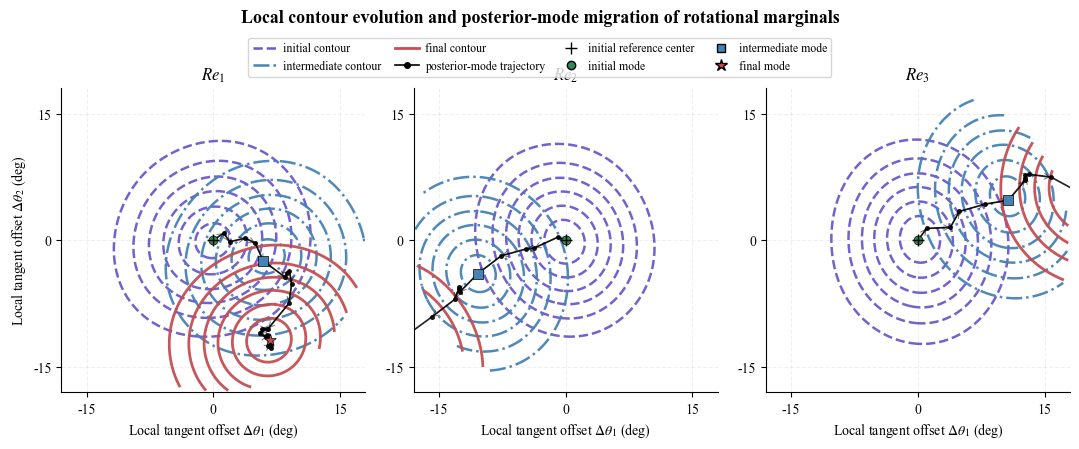

[Saved] exp2CB_mild_seed44_mode_trajectory_contours.pdf
[Saved] exp2CB_mild_seed44_mode_trajectory_contours.png


In [44]:
# ============================================================
# Run the new figure for current exp2CB records
# ============================================================

# You can manually set the three representative states if you want:
# For your current false_confidence seed44 example, you previously used:
#   initial  = state 0
#   middle   = state 5
#   final    = state 17
#
# So here I use indices (0, 5, 17).
# If the current run has fewer states, replace accordingly.

snapshot_indices_exp2CB = (0, 5, 17)

exp2CB_mode_traj_data = build_exp2CB_mode_trajectory_contour_data(
    trace_records_exp2CB,
    snapshot_indices=snapshot_indices_exp2CB,
    sample_N=2800,        # can increase to 3500 if you want smoother contours
    burnin=400,
    thin=1,
    proposal_c=1.0,
    seed_base=2025,
    cap_radius_deg=18.0,
    bandwidth_deg=4.5,    # 4.0 ~ 5.5 is usually good
    grid_size=181,
)

plot_exp2CB_mode_trajectory_contours(
    exp2CB_mode_traj_data,
    save_path_pdf=f"{EXP2CB_OUTPUT_PREFIX}_mode_trajectory_contours.pdf",
    save_path_png=f"{EXP2CB_OUTPUT_PREFIX}_mode_trajectory_contours.png",
)

# 2X3 排列的大图

## 没有局部放大版

In [ ]:
# ============================================================
# Combined 2x3 Figure:
# Top row:
#   (a) Residual merit rho + rotational information score s_rot
#   (b) Rotational error evolution
#   (c) Translational error evolution
#
# Bottom row:
#   (d) Re1 local contour evolution + posterior-mode migration
#   (e) Re2 local contour evolution + posterior-mode migration
#   (f) Re3 local contour evolution + posterior-mode migration
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Global plotting style
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


# ------------------------------------------------------------
# Color palette
# ------------------------------------------------------------
# Quantitative evolution panels
C_BLUE = "#2F6FB0"
C_BLUE_DARK = "#245A91"
C_BLUE_FILL = "#DCEAF7"

C_PURPLE = "#7A4DB3"
C_PURPLE_DARK = "#613A94"
C_PURPLE_FILL = "#E8DDF4"

# Contour panels
C_CONTOUR_INIT = "#D2B4DE"
C_CONTOUR_MID = "#00BFFF"
C_CONTOUR_FINAL = "#D959A6"

C_MODE_INIT = "#2E8B57"
C_MODE_MID = "#4682B4"
C_MODE_FINAL = "#C44E52"

C_GRID = "#C9D2DC"
C_SPINE = "#333333"


def plot_exp2CB_combined_refinement_summary(
    records,
    contour_data,
    *,
    save_path_pdf="exp2CB_false_confidence_seed44_combined_refinement_summary.pdf",
    save_path_png="exp2CB_false_confidence_seed44_combined_refinement_summary.png",
    contour_levels=(0.20, 0.35, 0.50, 0.65, 0.80, 0.92),
):
    # ========================================================
    # 1. Extract quantitative evolution data
    # ========================================================
    state = np.array([r["state_id"] for r in records], dtype=int)

    rho = np.array([r["rho"] for r in records], dtype=float)
    s_rot = np.array([r["s_rot"] for r in records], dtype=float)

    nominal_eR = np.array([r["nominal_eR"] for r in records], dtype=float)
    mode_eR = np.array([r["mode_eR"] for r in records], dtype=float)

    nominal_ep_mm = 1e3 * np.array(
        [r["nominal_ep"] for r in records],
        dtype=float,
    )
    mode_ep_mm = 1e3 * np.array(
        [r["mode_ep"] for r in records],
        dtype=float,
    )

    # ========================================================
    # 2. Figure canvas: 2 x 3
    # ========================================================
    fig = plt.figure(
        figsize=(7.45, 5.55),   # IEEE double-column width
        constrained_layout=False,
    )

    gs = fig.add_gridspec(
        2,
        3,
        height_ratios=[0.92, 1.12],
        hspace=0.52,
        wspace=0.45,
    )

    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[0, 2])

    ax_d = fig.add_subplot(gs[1, 0])
    ax_e = fig.add_subplot(gs[1, 1])
    ax_f = fig.add_subplot(gs[1, 2])

    top_axes = [ax_a, ax_b, ax_c]
    bottom_axes = [ax_d, ax_e, ax_f]

    # --------------------------------------------------------
    # Shared style helper for top-row line plots
    # --------------------------------------------------------
    def refine_top_axis(ax):
        ax.grid(
            True,
            linestyle="--",
            linewidth=0.55,
            alpha=0.42,
            color=C_GRID,
            zorder=0,
        )

        for spine in ax.spines.values():
            spine.set_linewidth(0.85)
            spine.set_color(C_SPINE)

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=7.8,
            width=0.8,
            length=3.2,
        )

        ax.set_xticks(np.arange(0, state.max() + 1, 2))

    # ========================================================
    # (a) Residual merit rho + rotational information s_rot
    # ========================================================
    ax = ax_a

    rho_lower = rho.min() - 0.04 * (rho.max() - rho.min())

    # ax.fill_between(
    #     state,
    #     rho,
    #     rho_lower,
    #     color=C_BLUE_FILL,
    #     alpha=0.58,
    #     linewidth=0,
    #     zorder=1,
    # )

    line_rho, = ax.plot(
        state,
        rho,
        color=C_BLUE,
        marker="o",
        markersize=3.9,
        markerfacecolor=C_BLUE,
        markeredgecolor=C_BLUE_DARK,
        markeredgewidth=0.55,
        linewidth=1.65,
        label=r"Residual merit $\rho$",
        zorder=3,
    )

    ax.set_ylim(
        rho_lower,
        rho.max() + 0.06 * (rho.max() - rho.min()),
    )

    ax.set_xlabel("Accepted posterior-update index", fontsize=8.2)
    ax.set_ylabel(r"Residual merit $\rho$", fontsize=8.2, color=C_BLUE_DARK)
    ax.tick_params(axis="y", colors=C_BLUE_DARK)

    ax.set_title(
        r"(a) Residual fit and rotational information",
        fontsize=8.8,
        fontweight="bold",
        pad=4,
    )

    refine_top_axis(ax)

    # Twin y-axis for s_rot
    ax_info = ax.twinx()

    # ax_info.fill_between(
    #     state,
    #     s_rot,
    #     0.0,
    #     color=C_PURPLE_FILL,
    #     alpha=0.25,
    #     linewidth=0,
    #     zorder=1,
    # )

    line_srot, = ax_info.plot(
        state,
        s_rot,
        color=C_PURPLE,
        marker="s",
        markersize=3.7,
        markerfacecolor=C_PURPLE,
        markeredgecolor=C_PURPLE_DARK,
        markeredgewidth=0.55,
        linewidth=1.65,
        label=r"$s_{\mathrm{rot}}$",
        zorder=3,
    )

    ax_info.set_ylim(
        0.0,
        s_rot.max() + 0.08 * s_rot.max(),
    )

    ax_info.set_ylabel(
        r"$s_{\mathrm{rot}}=\lambda_{\min}(\mathcal{I}_{\mathrm{rot}})$",
        fontsize=8.2,
        color=C_PURPLE_DARK,
        labelpad=1.5,
    )

    ax_info.tick_params(
        axis="y",
        which="major",
        labelsize=7.8,
        width=0.8,
        length=3.2,
        colors=C_PURPLE_DARK,
    )

    ax_info.spines["right"].set_linewidth(0.85)
    ax_info.spines["right"].set_color(C_PURPLE_DARK)
    ax_info.grid(False)

    ax.legend(
        handles=[line_rho, line_srot],
        fontsize=6.8,
        frameon=True,
        fancybox=True,
        framealpha=0.92,
        edgecolor="#BFBFBF",
        facecolor="white",
        loc="upper center",
    )

    # ========================================================
    # (b) Rotational error evolution
    # ========================================================
    ax = ax_b

    ax.fill_between(
        state,
        nominal_eR,
        mode_eR,
        color=C_PURPLE_FILL,
        alpha=0.50,
        linewidth=0,
        zorder=1,
    )

    ax.plot(
        state,
        nominal_eR,
        color=C_BLUE,
        marker="o",
        markersize=3.9,
        markerfacecolor=C_BLUE,
        markeredgecolor=C_BLUE_DARK,
        markeredgewidth=0.55,
        linewidth=1.65,
        label=r" $X_{B,\mathrm{nom}}^{(t)}$",
        zorder=3,
    )

    ax.plot(
        state,
        mode_eR,
        color=C_PURPLE,
        marker="s",
        markersize=3.8,
        markerfacecolor=C_PURPLE,
        markeredgecolor=C_PURPLE_DARK,
        markeredgewidth=0.55,
        linewidth=1.65,
        label=r" $\widehat{X}_{B,\mathrm{post}}^{(t)}$",
        zorder=3,
    )

    ax.set_xlabel("Accepted posterior-update index", fontsize=8.2)
    ax.set_ylabel(r"Rotation error (rad)", fontsize=8.2)
    ax.set_title(
        r"(b) Rotational error evolution",
        fontsize=8.8,
        fontweight="bold",
        pad=4,
    )

    refine_top_axis(ax)

    ax.legend(
        fontsize=6.5,
        frameon=True,
        fancybox=True,
        framealpha=0.92,
        edgecolor="#BFBFBF",
        facecolor="white",
        loc="upper right",
    )

    # ========================================================
    # (c) Translational error evolution
    # ========================================================
    ax = ax_c

    ax.fill_between(
        state,
        nominal_ep_mm,
        mode_ep_mm,
        color=C_PURPLE_FILL,
        alpha=0.50,
        linewidth=0,
        zorder=1,
    )

    ax.plot(
        state,
        nominal_ep_mm,
        color=C_BLUE,
        marker="o",
        markersize=3.9,
        markerfacecolor=C_BLUE,
        markeredgecolor=C_BLUE_DARK,
        markeredgewidth=0.55,
        linewidth=1.65,
        label=r" $X_{B,\mathrm{nom}}^{(t)}$",
        zorder=3,
    )

    ax.plot(
        state,
        mode_ep_mm,
        color=C_PURPLE,
        marker="s",
        markersize=3.8,
        markerfacecolor=C_PURPLE,
        markeredgecolor=C_PURPLE_DARK,
        markeredgewidth=0.55,
        linewidth=1.65,
        label=r" $\widehat{X}_{B,\mathrm{post}}^{(t)}$",
        zorder=3,
    )

    ax.set_xlabel("Accepted posterior-update index", fontsize=8.2)
    ax.set_ylabel(r"Translation error $(\times 10^{-3})$", fontsize=8.2)
    ax.set_title(
        r"(c) Translational error evolution",
        fontsize=8.8,
        fontweight="bold",
        pad=4,
    )

    refine_top_axis(ax)

    ax.legend(
        fontsize=6.5,
        frameon=True,
        fancybox=True,
        framealpha=0.92,
        edgecolor="#BFBFBF",
        facecolor="white",
        loc="upper right",
    )

    # ========================================================
    # Bottom row: contour evolution + posterior-mode trajectory
    # ========================================================
    row_names = ["Re1", "Re2", "Re3"]
    bottom_titles = [
        r"(d) Local marginal of $R e_1$",
        r"(e) Local marginal of $R e_2$",
        r"(f) Local marginal of $R e_3$",
    ]

    contour_styles = {
        0: dict(
            color=C_CONTOUR_INIT,
            linestyle="--",
            linewidth=1.45,
            label="initial contour",
        ),
        1: dict(
            color=C_CONTOUR_MID,
            linestyle="-.",
            linewidth=1.45,
            label="intermediate contour",
        ),
        2: dict(
            color=C_CONTOUR_FINAL,
            linestyle="-",
            linewidth=1.60,
            label="final contour",
        ),
    }

    snapshot_marker_style = {
        0: dict(
            marker="o",
            s=32,
            color=C_MODE_INIT,
            edgecolor="black",
            linewidth=0.45,
            label="initial mode",
        ),
        1: dict(
            marker="s",
            s=35,
            color=C_MODE_MID,
            edgecolor="black",
            linewidth=0.45,
            label="intermediate mode",
        ),
        2: dict(
            marker="*",
            s=64,
            color=C_MODE_FINAL,
            edgecolor="black",
            linewidth=0.45,
            label="final mode",
        ),
    }

    cap_radius_deg = float(contour_data["cap_radius_deg"])

    for ax, row_name, panel_title in zip(bottom_axes, row_names, bottom_titles):
        row = contour_data["row_data"][row_name]

        # ----------------------------------------------------
        # Density contours: initial / middle / final
        # ----------------------------------------------------
        for panel in row["panels"]:
            k = panel["snapshot_rank"]
            st = contour_styles[k]

            ax.contour(
                panel["X"],
                panel["Y"],
                panel["Z"],
                levels=np.asarray(contour_levels, dtype=float),
                colors=st["color"],
                linestyles=st["linestyle"],
                linewidths=st["linewidth"],
                alpha=0.98,
                zorder=2,
            )

        # ----------------------------------------------------
        # Full posterior-mode trajectory
        # ----------------------------------------------------
        traj = row["trajectory_xy"]

        ax.plot(
            traj[:, 0],
            traj[:, 1],
            color="black",
            linewidth=1.10,
            marker="o",
            markersize=2.2,
            alpha=0.88,
            zorder=5,
        )

        # Sparse arrows to indicate iteration direction
        if len(traj) >= 2:
            arrow_ids = np.linspace(
                0,
                len(traj) - 2,
                min(5, len(traj) - 1),
            ).astype(int)

            for k in arrow_ids:
                ax.annotate(
                    "",
                    xy=(traj[k + 1, 0], traj[k + 1, 1]),
                    xytext=(traj[k, 0], traj[k, 1]),
                    arrowprops=dict(
                        arrowstyle="->",
                        color="black",
                        lw=0.62,
                        alpha=0.65,
                        shrinkA=0.0,
                        shrinkB=0.0,
                    ),
                    zorder=6,
                )

        # ----------------------------------------------------
        # Initial / intermediate / final mode markers
        # ----------------------------------------------------
        for panel in row["panels"]:
            k = panel["snapshot_rank"]
            st = snapshot_marker_style[k]
            mx, my = panel["mode_xy"]

            ax.scatter(
                [mx],
                [my],
                marker=st["marker"],
                s=st["s"],
                color=st["color"],
                edgecolor=st["edgecolor"],
                linewidth=st["linewidth"],
                zorder=8,
            )

        # Fixed initial reference center
        ax.scatter(
            [0.0],
            [0.0],
            marker="+",
            s=58,
            color="black",
            linewidths=0.95,
            zorder=9,
        )

        # Circular local cap boundary
        boundary = plt.Circle(
            (0.0, 0.0),
            cap_radius_deg,
            fill=False,
            linewidth=0.75,
            color="#555555",
            alpha=0.95,
        )
        ax.add_patch(boundary)

        # Formatting
        ax.set_aspect("equal")
        ax.set_xlim(-cap_radius_deg, cap_radius_deg)
        ax.set_ylim(-cap_radius_deg, cap_radius_deg)

        ax.set_xticks([-15, 0, 15])
        ax.set_yticks([-15, 0, 15])

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=7.6,
            width=0.72,
            length=3.0,
        )

        ax.grid(
            True,
            linestyle="--",
            linewidth=0.48,
            alpha=0.18,
            color=C_GRID,
            zorder=0,
        )

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.set_title(
            panel_title,
            fontsize=8.8,
            fontweight="bold",
            pad=5,
        )

    # Bottom row: shared axis labels
    ax_d.set_ylabel(
        r"Local tangent offset $\Delta\theta_2$ (deg)",
        fontsize=8.4,
    )
    ax_e.set_yticklabels([])
    ax_f.set_yticklabels([])

    for ax in bottom_axes:
        ax.set_xlabel(
            r"Local tangent offset $\Delta\theta_1$ (deg)",
            fontsize=8.4,
        )

    # ========================================================
    # Bottom-row contour legend
    # ========================================================
    contour_legend_handles = [
        Line2D(
            [0], [0],
            color=C_CONTOUR_INIT,
            linestyle="--",
            linewidth=1.45,
            label="initial contour",
        ),
        Line2D(
            [0], [0],
            color=C_CONTOUR_MID,
            linestyle="-.",
            linewidth=1.45,
            label="intermediate contour",
        ),
        Line2D(
            [0], [0],
            color=C_CONTOUR_FINAL,
            linestyle="-",
            linewidth=1.60,
            label="final contour",
        ),
        Line2D(
            [0], [0],
            color="black",
            linewidth=1.10,
            marker="o",
            markersize=3.0,
            label="posterior-mode trajectory",
        ),
        Line2D(
            [0], [0],
            marker="+",
            color="black",
            linestyle="None",
            markersize=5.8,
            markeredgewidth=0.95,
            label="initial reference center",
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=C_MODE_INIT,
            markeredgecolor="black",
            markersize=4.8,
            label="initial mode",
        ),
        Line2D(
            [0], [0],
            marker="s",
            color="none",
            markerfacecolor=C_MODE_MID,
            markeredgecolor="black",
            markersize=4.8,
            label="intermediate mode",
        ),
        Line2D(
            [0], [0],
            marker="*",
            color="none",
            markerfacecolor=C_MODE_FINAL,
            markeredgecolor="black",
            markersize=6.8,
            label="final mode",
        ),
    ]

    fig.legend(
        handles=contour_legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.005),
        ncol=4,
        fontsize=6.8,
        frameon=True,
        fancybox=True,
        framealpha=0.94,
        edgecolor="#BFBFBF",
        facecolor="white",
        columnspacing=1.05,
        handletextpad=0.42,
        borderpad=0.40,
    )

    # ========================================================
    # Overall title
    # ========================================================
    fig.suptitle(
        r"Representative refinement dynamics and rotational-marginal migration",
        fontsize=11.2,
        fontweight="bold",
        y=0.985,
    )

    # ========================================================
    # Layout
    # ========================================================
    plt.subplots_adjust(
        left=0.070,
        right=0.985,
        bottom=0.135,
        top=0.905,
    )

    # ========================================================
    # Save and show
    # ========================================================
    fig.savefig(
        save_path_pdf,
        bbox_inches="tight",
    )

    fig.savefig(
        save_path_png,
        dpi=350,
        bbox_inches="tight",
    )

    plt.show()

    print(f"[Saved] {save_path_pdf}")
    print(f"[Saved] {save_path_png}")

In [ ]:
snapshot_indices_exp2CB = (0, 5, 17)

exp2CB_mode_traj_data = build_exp2CB_mode_trajectory_contour_data(
    trace_records_exp2CB,
    snapshot_indices=snapshot_indices_exp2CB,
    sample_N=2800,
    burnin=400,
    thin=1,
    proposal_c=1.0,
    seed_base=2025,
    cap_radius_deg=18.0,
    bandwidth_deg=4.5,
    grid_size=181,
)

In [ ]:
plot_exp2CB_combined_refinement_summary(
    trace_records_exp2CB,
    exp2CB_mode_traj_data,
    save_path_pdf=f"{EXP2CB_OUTPUT_PREFIX}_combined_refinement_summary.pdf",
    save_path_png=f"{EXP2CB_OUTPUT_PREFIX}_combined_refinement_summary.png",
)

## 有局部放大版

In [45]:
# ============================================================
# Combined 2x3 Figure with zoom-in insets for contour panels
# Top row:
#   (a) Residual merit rho + rotational information score s_rot
#   (b) Rotational error evolution
#   (c) Translational error evolution
#
# Bottom row:
#   (d) Re1 local contour evolution + posterior-mode migration
#   (e) Re2 local contour evolution + posterior-mode migration
#   (f) Re3 local contour evolution + posterior-mode migration
#      with zoom-in inset around the local mode trajectory
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# ------------------------------------------------------------
# Global plotting style
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


# ------------------------------------------------------------
# Color palette
# ------------------------------------------------------------
# Quantitative evolution panels
C_BLUE = "#2F6FB0"
C_BLUE_DARK = "#245A91"
C_BLUE_FILL = "#DCEAF7"

C_PURPLE = "#7A4DB3"
C_PURPLE_DARK = "#613A94"
C_PURPLE_FILL = "#E8DDF4"

# Contour panels: softer / lighter palette
C_CONTOUR_INIT = "#D8C4EA"    # light lavender
C_CONTOUR_MID = "#A9D6F5"     # light sky blue
C_CONTOUR_FINAL = "#F2A7C6"   # light pink / coral

C_MODE_INIT = "#2E8B57"
C_MODE_MID = "#4682B4"
C_MODE_FINAL = "#C44E52"

C_GRID = "#C9D2DC"
C_SPINE = "#333333"


def plot_exp2CB_combined_refinement_summary(
    records,
    contour_data,
    *,
    save_path_pdf="exp2CB_false_confidence_seed44_combined_refinement_summary.pdf",
    save_path_png="exp2CB_false_confidence_seed44_combined_refinement_summary.png",
    contour_levels=(0.20, 0.35, 0.50, 0.65, 0.80, 0.92),
    inset_loc="upper left",
    inset_width="39%",
    inset_height="39%",
    inset_borderpad=0.85,
):
    # ========================================================
    # 1. Extract quantitative evolution data
    # ========================================================
    state = np.array([r["state_id"] for r in records], dtype=int)

    rho = np.array([r["rho"] for r in records], dtype=float)
    s_rot = np.array([r["s_rot"] for r in records], dtype=float)

    nominal_eR = np.array([r["nominal_eR"] for r in records], dtype=float)
    mode_eR = np.array([r["mode_eR"] for r in records], dtype=float)

    nominal_ep_mm = 1e3 * np.array(
        [r["nominal_ep"] for r in records],
        dtype=float,
    )
    mode_ep_mm = 1e3 * np.array(
        [r["mode_ep"] for r in records],
        dtype=float,
    )

    # ========================================================
    # 2. Figure canvas: 2 x 3
    #    Slightly wider + larger wspace to avoid label overlap
    # ========================================================
    fig = plt.figure(
        figsize=(7.45, 5.55),
        constrained_layout=False,
    )

    gs = fig.add_gridspec(
        2,
        3,
        height_ratios=[0.92, 1.12],
        hspace=0.52,
        wspace=0.45,
    )

    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[0, 2])

    ax_d = fig.add_subplot(gs[1, 0])
    ax_e = fig.add_subplot(gs[1, 1])
    ax_f = fig.add_subplot(gs[1, 2])

    top_axes = [ax_a, ax_b, ax_c]
    bottom_axes = [ax_d, ax_e, ax_f]

    # --------------------------------------------------------
    # Shared style helper for top-row line plots
    # --------------------------------------------------------
    def refine_top_axis(ax):
        ax.grid(
            True,
            linestyle="--",
            linewidth=0.55,
            alpha=0.42,
            color=C_GRID,
            zorder=0,
        )

        for spine in ax.spines.values():
            spine.set_linewidth(0.85)
            spine.set_color(C_SPINE)

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=7.8,
            width=0.8,
            length=3.2,
        )

        ax.set_xticks(np.arange(0, state.max() + 1, 2))

    # ========================================================
    # (a) Residual merit rho + rotational information s_rot
    #     No shaded region here
    # ========================================================
    ax = ax_a

    rho_lower = rho.min() - 0.04 * (rho.max() - rho.min())

    line_rho, = ax.plot(
        state,
        rho,
        color=C_BLUE,
        marker="o",
        markersize=3.9,
        markerfacecolor=C_BLUE,
        markeredgecolor=C_BLUE_DARK,
        markeredgewidth=0.55,
        linewidth=1.70,
        label=r"Residual merit $\rho$",
        zorder=3,
    )

    ax.set_ylim(
        rho_lower,
        rho.max() + 0.06 * (rho.max() - rho.min()),
    )

    ax.set_xlabel("Accepted posterior-update index", fontsize=8.2)
    ax.set_ylabel(r"Residual merit $\rho$", fontsize=8.2, color=C_BLUE_DARK)
    ax.tick_params(axis="y", colors=C_BLUE_DARK)

    ax.set_title(
        r"(a) Residual fit and rotational information",
        fontsize=8.8,
        fontweight="bold",
        pad=4,
    )

    refine_top_axis(ax)

    # Twin y-axis for s_rot
    ax_info = ax.twinx()

    line_srot, = ax_info.plot(
        state,
        s_rot,
        color=C_PURPLE,
        marker="s",
        markersize=3.7,
        markerfacecolor=C_PURPLE,
        markeredgecolor=C_PURPLE_DARK,
        markeredgewidth=0.55,
        linewidth=1.70,
        label=r"$s_{\mathrm{rot}}$",
        zorder=3,
    )

    ax_info.set_ylim(
        0.0,
        s_rot.max() + 0.08 * s_rot.max(),
    )

    ax_info.set_ylabel(
        r"$s_{\mathrm{rot}}=\lambda_{\min}(\mathcal{I}_{\mathrm{rot}})$",
        fontsize=8.2,
        color=C_PURPLE_DARK,
        labelpad=1.5,
    )

    ax_info.tick_params(
        axis="y",
        which="major",
        labelsize=7.8,
        width=0.8,
        length=3.2,
        colors=C_PURPLE_DARK,
    )

    ax_info.spines["right"].set_linewidth(0.85)
    ax_info.spines["right"].set_color(C_PURPLE_DARK)
    ax_info.grid(False)

    ax.legend(
        handles=[line_rho, line_srot],
        fontsize=6.8,
        frameon=True,
        fancybox=True,
        framealpha=0.92,
        edgecolor="#BFBFBF",
        facecolor="white",
        loc="upper center",
    )

    # ========================================================
    # (b) Rotational error evolution
    # ========================================================
    ax = ax_b

    ax.fill_between(
        state,
        nominal_eR,
        mode_eR,
        color=C_PURPLE_FILL,
        alpha=0.50,
        linewidth=0,
        zorder=1,
    )

    ax.plot(
        state,
        nominal_eR,
        color=C_BLUE,
        marker="o",
        markersize=3.9,
        markerfacecolor=C_BLUE,
        markeredgecolor=C_BLUE_DARK,
        markeredgewidth=0.55,
        linewidth=1.65,
        label=r"$e_{R,\mathrm{nom}}^{(t)}$",
        zorder=3,
    )

    ax.plot(
        state,
        mode_eR,
        color=C_PURPLE,
        marker="s",
        markersize=3.8,
        markerfacecolor=C_PURPLE,
        markeredgecolor=C_PURPLE_DARK,
        markeredgewidth=0.55,
        linewidth=1.65,
        label=r"$e_{R,\mathrm{post}}^{(t)}$",
        zorder=3,
    )

    ax.set_xlabel("Accepted posterior-update index", fontsize=8.2)
    ax.set_ylabel(r"Rotation error (rad)", fontsize=8.2)
    ax.set_title(
        r"(b) Rotational error evolution",
        fontsize=8.8,
        fontweight="bold",
        pad=4,
    )

    refine_top_axis(ax)

    ax.legend(
        fontsize=6.5,
        frameon=True,
        fancybox=True,
        framealpha=0.92,
        edgecolor="#BFBFBF",
        facecolor="white",
        loc="upper right",
    )

    # ========================================================
    # (c) Translational error evolution
    # ========================================================
    ax = ax_c

    ax.fill_between(
        state,
        nominal_ep_mm,
        mode_ep_mm,
        color=C_PURPLE_FILL,
        alpha=0.50,
        linewidth=0,
        zorder=1,
    )

    ax.plot(
        state,
        nominal_ep_mm,
        color=C_BLUE,
        marker="o",
        markersize=3.9,
        markerfacecolor=C_BLUE,
        markeredgecolor=C_BLUE_DARK,
        markeredgewidth=0.55,
        linewidth=1.65,
        label=r"$e_{p,\mathrm{nom}}^{(t)}$",
        zorder=3,
    )

    ax.plot(
        state,
        mode_ep_mm,
        color=C_PURPLE,
        marker="s",
        markersize=3.8,
        markerfacecolor=C_PURPLE,
        markeredgecolor=C_PURPLE_DARK,
        markeredgewidth=0.55,
        linewidth=1.65,
        label=r"$e_{p,\mathrm{post}}^{(t)}$",
        zorder=3,
    )

    ax.set_xlabel("Accepted posterior-update index", fontsize=8.2)
    ax.set_ylabel(r"Translation error $(\times 10^{-3})$", fontsize=8.2)
    ax.set_title(
        r"(c) Translational error evolution",
        fontsize=8.8,
        fontweight="bold",
        pad=4,
    )

    refine_top_axis(ax)

    ax.legend(
        fontsize=6.5,
        frameon=True,
        fancybox=True,
        framealpha=0.92,
        edgecolor="#BFBFBF",
        facecolor="white",
        loc="upper right",
    )

    # ========================================================
    # Bottom row: contour evolution + posterior-mode trajectory
    # ========================================================
    row_names = ["Re1", "Re2", "Re3"]
    bottom_titles = [
        r"(d) Local marginal of $R e_1$",
        r"(e) Local marginal of $R e_2$",
        r"(f) Local marginal of $R e_3$",
    ]

    contour_styles = {
        0: dict(
            color=C_CONTOUR_INIT,
            linestyle="--",
            linewidth=1.45,
            label="initial contour",
        ),
        1: dict(
            color=C_CONTOUR_MID,
            linestyle="-.",
            linewidth=1.45,
            label="intermediate contour",
        ),
        2: dict(
            color=C_CONTOUR_FINAL,
            linestyle="-",
            linewidth=1.60,
            label="final contour",
        ),
    }

    snapshot_marker_style = {
        0: dict(
            marker="o",
            s=32,
            color=C_MODE_INIT,
            edgecolor="black",
            linewidth=0.45,
            label="initial mode",
        ),
        1: dict(
            marker="s",
            s=35,
            color=C_MODE_MID,
            edgecolor="black",
            linewidth=0.45,
            label="intermediate mode",
        ),
        2: dict(
            marker="*",
            s=64,
            color=C_MODE_FINAL,
            edgecolor="black",
            linewidth=0.45,
            label="final mode",
        ),
    }

    cap_radius_deg = float(contour_data["cap_radius_deg"])

    # --------------------------------------------------------
    # Helper: compute local zoom window for inset
    # --------------------------------------------------------
    def compute_zoom_window(row):
        traj = np.asarray(row["trajectory_xy"], dtype=float)

        pts = [traj]
        for panel in row["panels"]:
            pts.append(np.asarray(panel["mode_xy"], dtype=float).reshape(1, 2))

        # also include the reference center
        pts.append(np.array([[0.0, 0.0]]))
        pts = np.vstack(pts)

        xmin, ymin = pts.min(axis=0)
        xmax, ymax = pts.max(axis=0)

        cx = 0.5 * (xmin + xmax)
        cy = 0.5 * (ymin + ymax)

        span = max(xmax - xmin, ymax - ymin)

        # Make inset large enough to clearly show local migration
        #half_span = max(3.2, 0.75 * span + 0.90)
        half_span = max(2.6, 0.65 * span + 0.70)

        half_span = min(half_span, 0.58 * cap_radius_deg)

        return cx, cy, half_span

    # --------------------------------------------------------
    # Helper: draw one contour panel + inset
    # --------------------------------------------------------
    def draw_contour_panel(ax, row, panel_title, add_inset=True):
        # ---- density contours: initial / middle / final
        for panel in row["panels"]:
            k = panel["snapshot_rank"]
            st = contour_styles[k]

            ax.contour(
                panel["X"],
                panel["Y"],
                panel["Z"],
                levels=np.asarray(contour_levels, dtype=float),
                colors=st["color"],
                linestyles=st["linestyle"],
                linewidths=st["linewidth"],
                alpha=0.98,
                zorder=2,
            )

        # ---- posterior-mode trajectory
        traj = np.asarray(row["trajectory_xy"], dtype=float)

        ax.plot(
            traj[:, 0],
            traj[:, 1],
            color="black",
            linewidth=1.10,
            marker="o",
            markersize=2.2,
            alpha=0.88,
            zorder=5,
        )

        # Sparse arrows to indicate iteration direction
        if len(traj) >= 2:
            arrow_ids = np.linspace(
                0,
                len(traj) - 2,
                min(5, len(traj) - 1),
            ).astype(int)

            for k in arrow_ids:
                ax.annotate(
                    "",
                    xy=(traj[k + 1, 0], traj[k + 1, 1]),
                    xytext=(traj[k, 0], traj[k, 1]),
                    arrowprops=dict(
                        arrowstyle="->",
                        color="black",
                        lw=0.62,
                        alpha=0.65,
                        shrinkA=0.0,
                        shrinkB=0.0,
                    ),
                    zorder=6,
                )

        # ---- initial / intermediate / final mode markers
        for panel in row["panels"]:
            k = panel["snapshot_rank"]
            st = snapshot_marker_style[k]
            mx, my = panel["mode_xy"]

            ax.scatter(
                [mx],
                [my],
                marker=st["marker"],
                s=st["s"],
                color=st["color"],
                edgecolor=st["edgecolor"],
                linewidth=st["linewidth"],
                zorder=8,
            )

        # ---- initial reference center
        ax.scatter(
            [0.0],
            [0.0],
            marker="+",
            s=58,
            color="black",
            linewidths=0.95,
            zorder=9,
        )

        # ---- circular local cap boundary
        boundary = plt.Circle(
            (0.0, 0.0),
            cap_radius_deg,
            fill=False,
            linewidth=0.75,
            color="#555555",
            alpha=0.95,
        )
        ax.add_patch(boundary)

        # ---- formatting
        ax.set_aspect("equal")
        ax.set_xlim(-cap_radius_deg, cap_radius_deg)
        ax.set_ylim(-cap_radius_deg, cap_radius_deg)

        ax.set_xticks([-15, 0, 15])
        ax.set_yticks([-15, 0, 15])

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=7.6,
            width=0.72,
            length=3.0,
        )

        ax.grid(
            True,
            linestyle="--",
            linewidth=0.48,
            alpha=0.18,
            color=C_GRID,
            zorder=0,
        )

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.set_title(
            panel_title,
            fontsize=8.8,
            fontweight="bold",
            pad=5,
        )

        # ====================================================
        # Inset zoom around the local posterior-mode migration
        # ====================================================
        if add_inset:
            cx, cy, half_span = compute_zoom_window(row)

            # axins = inset_axes(
            #     ax,
            #     width=inset_width,
            #     height=inset_height,
            #     loc=inset_loc,
            #     borderpad=inset_borderpad,
            # )
            axins = inset_axes(
                ax,
                width=inset_width,
                height=inset_height,
                loc=inset_loc,
                bbox_to_anchor=(-0.045, 0.0, 1.0, 1.0),
                bbox_transform=ax.transAxes,
                borderpad=inset_borderpad,
            )

            # contours in inset
            for panel in row["panels"]:
                k = panel["snapshot_rank"]
                st = contour_styles[k]

                axins.contour(
                    panel["X"],
                    panel["Y"],
                    panel["Z"],
                    levels=np.asarray(contour_levels, dtype=float),
                    colors=st["color"],
                    linestyles=st["linestyle"],
                    linewidths=max(0.95, 0.92 * st["linewidth"]),
                    alpha=0.98,
                    zorder=2,
                )

            # trajectory in inset
            axins.plot(
                traj[:, 0],
                traj[:, 1],
                color="black",
                linewidth=1.00,
                marker="o",
                markersize=2.0,
                alpha=0.92,
                zorder=5,
            )

            # arrows in inset
            if len(traj) >= 2:
                arrow_ids = np.linspace(
                    0,
                    len(traj) - 2,
                    min(4, len(traj) - 1),
                ).astype(int)

                for k in arrow_ids:
                    axins.annotate(
                        "",
                        xy=(traj[k + 1, 0], traj[k + 1, 1]),
                        xytext=(traj[k, 0], traj[k, 1]),
                        arrowprops=dict(
                            arrowstyle="->",
                            color="black",
                            lw=0.58,
                            alpha=0.65,
                            shrinkA=0.0,
                            shrinkB=0.0,
                        ),
                        zorder=6,
                    )

            # markers in inset
            for panel in row["panels"]:
                k = panel["snapshot_rank"]
                st = snapshot_marker_style[k]
                mx, my = panel["mode_xy"]

                axins.scatter(
                    [mx],
                    [my],
                    marker=st["marker"],
                    s=0.78 * st["s"],
                    color=st["color"],
                    edgecolor=st["edgecolor"],
                    linewidth=st["linewidth"],
                    zorder=8,
                )

            # reference center in inset
            axins.scatter(
                [0.0],
                [0.0],
                marker="+",
                s=42,
                color="black",
                linewidths=0.85,
                zorder=9,
            )

            # inset window
            axins.set_xlim(cx - half_span, cx + half_span)
            axins.set_ylim(cy - half_span, cy + half_span)
            axins.set_aspect("equal")

            # simplified ticks
            xticks = [cx - half_span, cx, cx + half_span]
            yticks = [cy - half_span, cy, cy + half_span]

            axins.set_xticks(xticks)
            axins.set_yticks(yticks)

            axins.set_xticklabels(
                [f"{v:.0f}" for v in xticks],
                fontsize=5.8,
            )
            axins.set_yticklabels(
                [f"{v:.0f}" for v in yticks],
                fontsize=5.8,
            )

            axins.grid(
                True,
                linestyle="--",
                linewidth=0.40,
                alpha=0.20,
                color=C_GRID,
                zorder=0,
            )

            for spine in axins.spines.values():
                spine.set_linewidth(0.72)
                spine.set_color("#666666")

            axins.tick_params(
                axis="both",
                which="major",
                width=0.55,
                length=2.0,
                pad=1.4,
            )

            # rectangle + connectors
            mark_inset(
                ax,
                axins,
                loc1=2,
                loc2=4,
                fc="none",
                ec="#777777",
                lw=0.60,
                alpha=0.88,
            )

    # --------------------------------------------------------
    # Draw bottom row panels
    # --------------------------------------------------------
    for ax, row_name, panel_title in zip(bottom_axes, row_names, bottom_titles):
        row = contour_data["row_data"][row_name]
        draw_contour_panel(ax, row, panel_title, add_inset=True)

    # Bottom row: shared axis labels
    ax_d.set_ylabel(
        r"Local tangent offset $\Delta\theta_2$ (deg)",
        fontsize=8.4,
    )
    ax_e.set_yticklabels([])
    ax_f.set_yticklabels([])

    for ax in bottom_axes:
        ax.set_xlabel(
            r"Local tangent offset $\Delta\theta_1$ (deg)",
            fontsize=8.4,
        )

    # ========================================================
    # Bottom-row contour legend
    # ========================================================
    contour_legend_handles = [
        Line2D(
            [0], [0],
            color=C_CONTOUR_INIT,
            linestyle="--",
            linewidth=1.45,
            label="initial contour",
        ),
        Line2D(
            [0], [0],
            color=C_CONTOUR_MID,
            linestyle="-.",
            linewidth=1.45,
            label="intermediate contour",
        ),
        Line2D(
            [0], [0],
            color=C_CONTOUR_FINAL,
            linestyle="-",
            linewidth=1.60,
            label="final contour",
        ),
        Line2D(
            [0], [0],
            color="black",
            linewidth=1.10,
            marker="o",
            markersize=3.0,
            label="posterior-mode trajectory",
        ),
        Line2D(
            [0], [0],
            marker="+",
            color="black",
            linestyle="None",
            markersize=5.8,
            markeredgewidth=0.95,
            label="initial reference center",
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=C_MODE_INIT,
            markeredgecolor="black",
            markersize=4.8,
            label="initial mode",
        ),
        Line2D(
            [0], [0],
            marker="s",
            color="none",
            markerfacecolor=C_MODE_MID,
            markeredgecolor="black",
            markersize=4.8,
            label="intermediate mode",
        ),
        Line2D(
            [0], [0],
            marker="*",
            color="none",
            markerfacecolor=C_MODE_FINAL,
            markeredgecolor="black",
            markersize=6.8,
            label="final mode",
        ),
    ]

    fig.legend(
        handles=contour_legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.005),
        ncol=4,
        fontsize=6.8,
        frameon=True,
        fancybox=True,
        framealpha=0.94,
        edgecolor="#BFBFBF",
        facecolor="white",
        columnspacing=1.05,
        handletextpad=0.42,
        borderpad=0.40,
    )

    # ========================================================
    # Overall title
    # ========================================================
    fig.suptitle(
        r"Refinement dynamics and geometric migration of rotational marginals",
        fontsize=11.2,
        fontweight="bold",
        y=0.985,
    )

    # ========================================================
    # Layout
    # ========================================================
    plt.subplots_adjust(
        left=0.070,
        right=0.985,
        bottom=0.135,
        top=0.905,
    )

    # ========================================================
    # Save and show
    # ========================================================
    fig.savefig(
        save_path_pdf,
        bbox_inches="tight",
    )

    fig.savefig(
        save_path_png,
        dpi=350,
        bbox_inches="tight",
    )

    plt.show()

    print(f"[Saved] {save_path_pdf}")
    print(f"[Saved] {save_path_png}")

In [46]:
snapshot_indices_exp2CB = (0, 5, 17)

exp2CB_mode_traj_data = build_exp2CB_mode_trajectory_contour_data(
    trace_records_exp2CB,
    snapshot_indices=snapshot_indices_exp2CB,
    sample_N=2800,
    burnin=400,
    thin=1,
    proposal_c=1.0,
    seed_base=2025,
    cap_radius_deg=18.0,
    bandwidth_deg=4.5,
    grid_size=181,
)

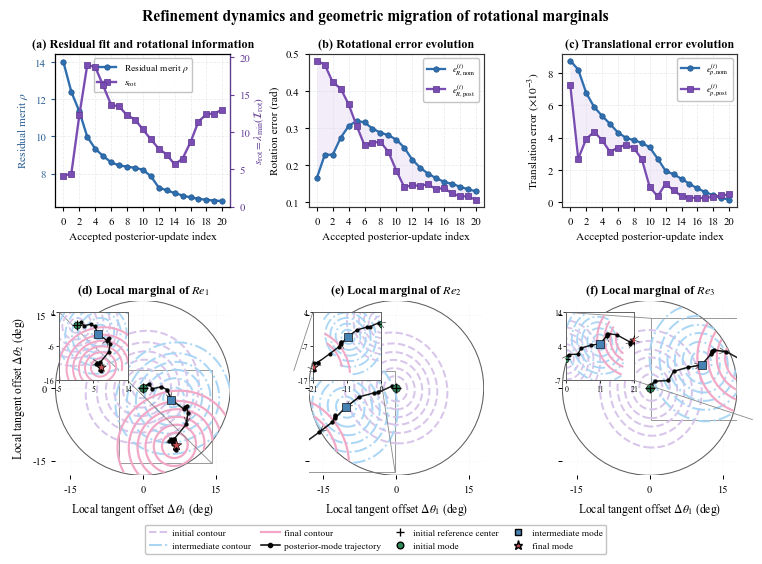

[Saved] exp2CB_mild_seed44_combined_refinement_summary.pdf
[Saved] exp2CB_mild_seed44_combined_refinement_summary.png


In [47]:
plot_exp2CB_combined_refinement_summary(
    trace_records_exp2CB,
    exp2CB_mode_traj_data,
    save_path_pdf=f"{EXP2CB_OUTPUT_PREFIX}_combined_refinement_summary.pdf",
    save_path_png=f"{EXP2CB_OUTPUT_PREFIX}_combined_refinement_summary.png",
)

# MFG  connditional plot （接在cell H3 后面）

In [55]:
# ============================================================
# Cell I1:
# Conditional MFG attitude visualization setup
# Mild representative case
#
# Target slice:
#     p_t(R_B | p_B = p_B^true)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


# ------------------------------------------------------------
# Preflight checks
# ------------------------------------------------------------
_REQUIRED_NAMES_COND_MFG = [
    "data_exp2CB",
    "res2_exp2CB",
    "EXP2CB_OUTPUT_PREFIX",
    "algorithm1_single_pass_local_mfg_posterior_update",
    "mfg_svd",
]

_missing_cond_mfg = [
    name for name in _REQUIRED_NAMES_COND_MFG
    if name not in globals()
]

if len(_missing_cond_mfg) > 0:
    raise NameError(
        "Missing required objects/functions for conditional MFG visualization:\n"
        + "\n".join(f"  - {name}" for name in _missing_cond_mfg)
        + "\nPlease run the Experiment 2C-b mild-case cells first."
    )


# ------------------------------------------------------------
# Explicit case declaration
# ------------------------------------------------------------
EXP2CB_COND_CASE_LABEL = "mild"

print("=" * 100)
print("Conditional attitude visualization")
print(f"Selected representative regime: {EXP2CB_COND_CASE_LABEL.upper()} CASE")
print("This block assumes data_exp2CB and res2_exp2CB come from the mild-case run.")
print("=" * 100)


# ------------------------------------------------------------
# User-adjustable settings
# ------------------------------------------------------------

# None -> automatically use [initial, middle, final].
# You may manually set state IDs if desired after inspecting res2_exp2CB.posterior_trace.
#EXP2CB_COND_SELECTED_STATE_IDS = None
EXP2CB_COND_SELECTED_STATE_IDS = [0, 5, 17]


# Fixed conditioning slice
EXP2CB_COND_PSTAR = np.asarray(
    data_exp2CB.X_B_true.p,
    dtype=float,
).copy()

# Sampling settings
EXP2CB_COND_N_SAMPLES = 30000
EXP2CB_COND_MH_BURNIN = 1200
EXP2CB_COND_MH_THIN = 1
EXP2CB_COND_MH_C = 1.0
EXP2CB_COND_SEED_BASE = 53000

# Local zoomed-cap settings
EXP2CB_COND_CAP_DEG = 28.0
EXP2CB_COND_GRID_N = 161
EXP2CB_COND_KDE_KAPPA = 150.0

# Output files
EXP2CB_COND_PDF = (
    f"{EXP2CB_OUTPUT_PREFIX}"
    "_mild_conditional_zoomed_cap_true_centered_conditional_peak.pdf"
)

EXP2CB_COND_PNG = (
    f"{EXP2CB_OUTPUT_PREFIX}"
    "_mild_conditional_zoomed_cap_true_centered_conditional_peak.png"
)


# ============================================================
# True-centered local posterior reference
# ============================================================

def exp2CB_run_alg1_at_nominal(data, X_B_bar):
    """
    Run Algorithm 1 using the same prior, data batch, and noise model,
    but with a user-specified local linearization center X_B_bar.
    """
    return algorithm1_single_pass_local_mfg_posterior_update(
        Theta_prior=data.Theta_0,
        X_B_bar=X_B_bar,
        U=data.U,
        Y=data.Y,
        field_params=data.field_params,
        stiffness_params=data.stiffness_params,
        ctrl_params=data.ctrl_params,
        Sigma_w=data.Sigma_w,
        contact_points_A_shared=data.contact_points_A,
        solver_config=data.solver_config,
        chi_A_0=None,
        use_psd_mf_curvature=False,
    )


print("\n" + "=" * 100)
print("Computing true-centered local posterior reference")
print("=" * 100)

res1_true_centered_exp2CB = exp2CB_run_alg1_at_nominal(
    data_exp2CB,
    data_exp2CB.X_B_true,
)

print(f"rho_true_centered   : {float(res1_true_centered_exp2CB.rho):.6e}")
print(f"s_rot_true_centered : {float(res1_true_centered_exp2CB.s_rot):.6e}")
print("=" * 100)

Conditional attitude visualization
Selected representative regime: MILD CASE
This block assumes data_exp2CB and res2_exp2CB come from the mild-case run.

Computing true-centered local posterior reference
rho_true_centered   : 6.431310e+00
s_rot_true_centered : 1.035163e+01


In [56]:
# ============================================================
# Cell I2:
# Select three Algorithm-2 posterior snapshots
# and append the true-centered reference posterior
# ============================================================

def exp2CB_select_conditional_trace_states(
    res2,
    selected_state_ids=None,
):
    """
    Return three posterior-trace states:
        initial, intermediate, final.

    If selected_state_ids is None:
        use [first, middle, last].
    Otherwise:
        selected_state_ids are interpreted as actual state_id values.
    """
    trace = list(res2.posterior_trace)

    if len(trace) < 3:
        raise ValueError(
            "Need at least three posterior trace states for visualization."
        )

    if selected_state_ids is None:
        chosen = [
            trace[0],
            trace[len(trace) // 2],
            trace[-1],
        ]
    else:
        state_map = {
            int(tr.state_id): tr
            for tr in trace
        }

        missing = [
            sid for sid in selected_state_ids
            if int(sid) not in state_map
        ]

        if len(missing) > 0:
            raise ValueError(
                f"Requested state_id(s) {missing} are unavailable. "
                f"Available state_ids: {sorted(state_map.keys())}"
            )

        chosen = [
            state_map[int(sid)]
            for sid in selected_state_ids
        ]

    if len(chosen) != 3:
        raise ValueError("Exactly three Algorithm-2 snapshots are required.")

    return chosen


cond_trace_states_exp2CB = exp2CB_select_conditional_trace_states(
    res2_exp2CB,
    EXP2CB_COND_SELECTED_STATE_IDS,
)


cond_snapshot_specs_exp2CB = []

cond_labels = [
    "Initial-centered",
    "Intermediate",
    "Final refinement",
]

for label, tr in zip(cond_labels, cond_trace_states_exp2CB):
    cond_snapshot_specs_exp2CB.append({
        "label": label,
        "kind": "alg2_trace",
        "state_id": int(tr.state_id),
        "outer_t": int(tr.outer_t),
        "rho": float(tr.rho),
        "s_rot": float(tr.s_rot),
        "Theta_post": tr.Theta_post,
    })


# Add true-centered oracle posterior
cond_snapshot_specs_exp2CB.append({
    "label": "True-centered reference",
    "kind": "oracle_true_centered",
    "state_id": None,
    "outer_t": None,
    "rho": float(res1_true_centered_exp2CB.rho),
    "s_rot": float(res1_true_centered_exp2CB.s_rot),
    "Theta_post": res1_true_centered_exp2CB.Theta_post,
})


print("\nSelected conditional attitude snapshots — mild case")
print("-" * 110)

for spec in cond_snapshot_specs_exp2CB:
    sid = (
        "oracle"
        if spec["state_id"] is None
        else f"state {spec['state_id']}"
    )

    print(
        f"{spec['label']:<28s} | "
        f"{sid:<12s} | "
        f"rho={spec['rho']:.6f} | "
        f"s_rot={spec['s_rot']:.6f}"
    )

print("-" * 110)


Selected conditional attitude snapshots — mild case
--------------------------------------------------------------------------------------------------------------
Initial-centered             | state 0      | rho=14.010959 | s_rot=4.121622
Intermediate                 | state 5      | rho=8.943496 | s_rot=16.218826
Final refinement             | state 17     | rho=6.637986 | s_rot=11.395132
True-centered reference      | oracle       | rho=6.431310 | s_rot=10.351628
--------------------------------------------------------------------------------------------------------------


In [57]:
# ============================================================
# Cell I3:
# Matrix-Fisher sampling and conditional importance weights
# with ESS diagnostics
# ============================================================

def exp2CB_mf_canonicalize_quaternion(q):
    q = np.asarray(q, dtype=float)
    q = q / np.linalg.norm(q)
    if q[0] < 0:
        q = -q
    return q


def exp2CB_mf_quat_to_rot(q):
    """
    Scalar-first quaternion q=[q0,q1,q2,q3]^T -> SO(3).
    """
    q = exp2CB_mf_canonicalize_quaternion(q)
    q0, q1, q2, q3 = q

    return np.array([
        [
            q0*q0 + q1*q1 - q2*q2 - q3*q3,
            2.0*(q1*q2 - q0*q3),
            2.0*(q1*q3 + q0*q2),
        ],
        [
            2.0*(q1*q2 + q0*q3),
            q0*q0 - q1*q1 + q2*q2 - q3*q3,
            2.0*(q2*q3 - q0*q1),
        ],
        [
            2.0*(q1*q3 - q0*q2),
            2.0*(q2*q3 + q0*q1),
            q0*q0 - q1*q1 - q2*q2 + q3*q3,
        ],
    ], dtype=float)


def exp2CB_mf_diag_to_bingham_params(s):
    s1, s2, s3 = np.asarray(s, dtype=float)

    a = np.array([
        s1 + s2 + s3,
        s1 - s2 - s3,
        -s1 + s2 - s3,
        -s1 - s2 + s3,
    ], dtype=float)

    z = a - np.max(a)
    return a, z


def exp2CB_mf_build_acg_shape(z, c=1.0):
    z = np.asarray(z, dtype=float)
    kappa = c - z

    if np.any(kappa <= 0):
        raise ValueError(
            "ACG proposal construction failed: some c-z_j <= 0. "
            "Increase c."
        )

    K = np.diag(kappa)
    Sigma_g = np.diag(1.0 / kappa)

    return K, Sigma_g, kappa


def exp2CB_mf_sample_acg(Sigma_g, rng):
    y = rng.multivariate_normal(
        mean=np.zeros(4),
        cov=Sigma_g,
    )
    q = y / np.linalg.norm(y)
    return exp2CB_mf_canonicalize_quaternion(q)


def exp2CB_mf_log_target_bingham(q, z):
    q = exp2CB_mf_canonicalize_quaternion(q)
    return float(np.dot(z, q * q))


def exp2CB_mf_log_proposal_acg(q, K):
    q = exp2CB_mf_canonicalize_quaternion(q)
    val = float(q @ K @ q)
    return float(-2.0 * np.log(val))


def exp2CB_sample_mf_so3_independence_mh(
    F,
    *,
    N=6000,
    burnin=800,
    thin=1,
    c=1.0,
    seed=53000,
):
    """
    Sample R ~ MF(F) using Independence-MH with ACG proposal.
    """
    rng = np.random.default_rng(int(seed))

    U, S, V = mfg_svd(F)
    s = np.diag(S).copy()

    a, z = exp2CB_mf_diag_to_bingham_params(s)
    K, Sigma_g, kappa = exp2CB_mf_build_acg_shape(z, c=c)

    q_current = exp2CB_mf_sample_acg(Sigma_g, rng)
    log_pi_current = exp2CB_mf_log_target_bingham(q_current, z)
    log_g_current = exp2CB_mf_log_proposal_acg(q_current, K)

    accepted_flags = []
    stored_R = []

    t = 0

    while len(stored_R) < int(N):
        q_prop = exp2CB_mf_sample_acg(Sigma_g, rng)

        log_pi_prop = exp2CB_mf_log_target_bingham(q_prop, z)
        log_g_prop = exp2CB_mf_log_proposal_acg(q_prop, K)

        Delta = (
            log_pi_prop
            - log_pi_current
            + log_g_current
            - log_g_prop
        )

        if np.log(rng.random()) <= min(0.0, Delta):
            q_current = q_prop
            log_pi_current = log_pi_prop
            log_g_current = log_g_prop
            accepted = 1
        else:
            accepted = 0

        accepted_flags.append(accepted)
        t += 1

        if t > int(burnin) and ((t - int(burnin)) % int(thin) == 0):
            R0 = exp2CB_mf_quat_to_rot(q_current)
            R = U @ R0 @ V.T
            stored_R.append(R.copy())

    return {
        "F": np.asarray(F, dtype=float),
        "U": U,
        "S": S,
        "V": V,
        "s": s,
        "a": a,
        "z": z,
        "stored_R": np.asarray(stored_R, dtype=float),
        "acceptance_rate": float(np.mean(accepted_flags)),
        "N": int(N),
        "burnin": int(burnin),
        "thin": int(thin),
        "c": float(c),
        "seed": int(seed),
    }


# ============================================================
# Conditional reweighting for p_t(R | p_B = p_B^true)
# ============================================================

def exp2CB_batch_vee(A_batch):
    return np.stack(
        [
            A_batch[:, 2, 1],
            A_batch[:, 0, 2],
            A_batch[:, 1, 0],
        ],
        axis=1,
    )


def exp2CB_batch_nu_R(R_batch, F):
    """
    Vectorized nu_R:
        F = U S V^T,
        Q = U^T R V,
        nu_R = (Q S - S Q^T)^vee.
    """
    R_batch = np.asarray(R_batch, dtype=float)
    U, S, V = mfg_svd(F)

    Q = np.einsum(
        "ij,njk,kl->nil",
        U.T,
        R_batch,
        V,
    )

    A = (
        np.matmul(Q, S)
        - np.matmul(S, np.transpose(Q, (0, 2, 1)))
    )

    A = 0.5 * (
        A - np.transpose(A, (0, 2, 1))
    )

    return exp2CB_batch_vee(A)


def exp2CB_conditional_importance_weights(
    R_batch,
    theta,
    p_star,
):
    """
    Since R_batch ~ MF(F), the conditional slice weights are

        w(R) ∝ exp[
            -1/2 || p_star - (mu + Gamma nu_R) ||^2_Lambda
        ].
    """
    p_star = np.asarray(p_star, dtype=float).reshape(3)
    R_batch = np.asarray(R_batch, dtype=float)

    nu = exp2CB_batch_nu_R(R_batch, theta.F)

    mu_c = (
        theta.mu[None, :]
        + nu @ theta.Gamma.T
    )

    delta = p_star[None, :] - mu_c

    quad = np.einsum(
        "ni,ij,nj->n",
        delta,
        theta.Lambda,
        delta,
    )

    logw = -0.5 * quad
    logw_shift = logw - np.max(logw)

    w = np.exp(logw_shift)
    w = w / np.sum(w)

    ess = float(1.0 / np.sum(w * w))

    return w, logw, ess


def exp2CB_prepare_conditional_samples(
    snapshot_specs,
    *,
    p_star,
    N=6000,
    burnin=800,
    thin=1,
    c=1.0,
    seed_base=53000,
):
    prepared = []

    print("\n" + "=" * 116)
    print("Sampling and reweighting for conditional attitude slices")
    print(r"Target: p_t(R_B | p_B = p_B^true)")
    print("=" * 116)

    header = (
        f"{'snapshot':<28s} | "
        f"{'state':<12s} | "
        f"{'MH acc.':>8s} | "
        f"{'ESS':>12s} | "
        f"{'ESS/N':>8s}"
    )
    print(header)
    print("-" * 116)

    for j, spec in enumerate(snapshot_specs):
        theta = spec["Theta_post"]

        sample_res = exp2CB_sample_mf_so3_independence_mh(
            theta.F,
            N=N,
            burnin=burnin,
            thin=thin,
            c=c,
            seed=seed_base + 17 * j,
        )

        R_samples = np.asarray(
            sample_res["stored_R"],
            dtype=float,
        )

        weights, logw, ess = exp2CB_conditional_importance_weights(
            R_samples,
            theta,
            p_star,
        )

        out = dict(spec)
        out["sample_result"] = sample_res
        out["R_samples"] = R_samples
        out["weights"] = weights
        out["log_weights"] = logw
        out["ess"] = float(ess)
        out["ess_ratio"] = float(ess / N)
        out["acceptance_rate"] = float(sample_res["acceptance_rate"])

        prepared.append(out)

        sid = (
            "oracle"
            if out["state_id"] is None
            else f"state {out['state_id']}"
        )

        print(
            f"{out['label']:<28s} | "
            f"{sid:<12s} | "
            f"{out['acceptance_rate']:8.3f} | "
            f"{out['ess']:8.1f}/{N:<3d} | "
            f"{out['ess_ratio']:8.3f}"
        )

    print("-" * 116)
    print(
        "ESS diagnostic: larger ESS/N indicates more reliable importance reweighting "
        "for the fixed-translation conditional slice."
    )
    print("=" * 116)

    return prepared


cond_prepared_snapshots_exp2CB = exp2CB_prepare_conditional_samples(
    cond_snapshot_specs_exp2CB,
    p_star=EXP2CB_COND_PSTAR,
    N=EXP2CB_COND_N_SAMPLES,
    burnin=EXP2CB_COND_MH_BURNIN,
    thin=EXP2CB_COND_MH_THIN,
    c=EXP2CB_COND_MH_C,
    seed_base=EXP2CB_COND_SEED_BASE,
)


Sampling and reweighting for conditional attitude slices
Target: p_t(R_B | p_B = p_B^true)
snapshot                     | state        |  MH acc. |          ESS |    ESS/N
--------------------------------------------------------------------------------------------------------------------
Initial-centered             | state 0      |    0.427 |    424.6/30000 |    0.014
Intermediate                 | state 5      |    0.426 |   1158.4/30000 |    0.039
Final refinement             | state 17     |    0.424 |  19879.3/30000 |    0.663
True-centered reference      | oracle       |    0.424 |  17868.2/30000 |    0.596
--------------------------------------------------------------------------------------------------------------------
ESS diagnostic: larger ESS/N indicates more reliable importance reweighting for the fixed-translation conditional slice.


In [58]:
# ============================================================
# Cell I4:
# Local zoomed-cap conditional density computation
# and conditional-density peak extraction
# ============================================================

EXP2CB_CAP_CMAP = LinearSegmentedColormap.from_list(
    "exp2cb_conditional_cap",
    [
        "#F4F8FD",
        "#DCEAF7",
        "#B6D7EE",
        "#79BCE2",
        "#3187C8",
        "#3BAE91",
        "#DAD95A",
        "#F2C14E",
        "#E98B2A",
    ],
    N=256,
)

EXP2CB_CAP_CMAP.set_bad(color="white")


def exp2CB_unit(v):
    v = np.asarray(v, dtype=float).reshape(3)
    return v / max(np.linalg.norm(v), 1e-12)


def exp2CB_tangent_basis(center):
    c = exp2CB_unit(center)

    trial = np.array([0.0, 0.0, 1.0], dtype=float)
    if abs(np.dot(c, trial)) > 0.92:
        trial = np.array([0.0, 1.0, 0.0], dtype=float)

    t1 = trial - np.dot(trial, c) * c
    t1 = exp2CB_unit(t1)

    t2 = np.cross(c, t1)
    t2 = exp2CB_unit(t2)

    return t1, t2


def exp2CB_sphere_exp_from_tangent(
    center,
    t1,
    t2,
    U,
    V,
):
    center = exp2CB_unit(center)

    W = U[..., None] * t1 + V[..., None] * t2
    theta = np.linalg.norm(W, axis=-1)

    dirs = np.zeros_like(W)

    small = theta < 1e-12
    nonsmall = ~small

    dirs[small] = center

    if np.any(nonsmall):
        W_hat = W[nonsmall] / theta[nonsmall][..., None]

        dirs[nonsmall] = (
            np.cos(theta[nonsmall])[..., None] * center
            + np.sin(theta[nonsmall])[..., None] * W_hat
        )

    dirs = dirs / np.maximum(
        np.linalg.norm(dirs, axis=-1, keepdims=True),
        1e-12,
    )

    return dirs


def exp2CB_make_cap_grid(
    center,
    *,
    cap_deg=28.0,
    n_grid=161,
):
    t1, t2 = exp2CB_tangent_basis(center)

    cap_rad = np.deg2rad(cap_deg)

    lin = np.linspace(
        -cap_rad,
        cap_rad,
        int(n_grid),
    )

    U, V = np.meshgrid(lin, lin)

    radius = np.sqrt(U**2 + V**2)
    mask = radius <= cap_rad

    sphere_dirs = exp2CB_sphere_exp_from_tangent(
        center,
        t1,
        t2,
        U,
        V,
    )

    return {
        "center": exp2CB_unit(center),
        "t1": t1,
        "t2": t2,
        "U_deg": np.rad2deg(U),
        "V_deg": np.rad2deg(V),
        "mask": mask,
        "sphere_dirs": sphere_dirs,
        "cap_deg": float(cap_deg),
    }


def exp2CB_weighted_spherical_kde(
    points,
    weights,
    grid_dirs,
    mask,
    *,
    kde_kappa=150.0,
    chunk_size=512,
):
    points = np.asarray(points, dtype=float)
    points = points / np.maximum(
        np.linalg.norm(points, axis=1, keepdims=True),
        1e-12,
    )

    weights = np.asarray(weights, dtype=float)
    weights = weights / np.sum(weights)

    G = grid_dirs.reshape(-1, 3)
    dens = np.zeros(G.shape[0], dtype=float)

    for start in range(0, G.shape[0], int(chunk_size)):
        end = min(start + int(chunk_size), G.shape[0])
        G_chunk = G[start:end]

        dots = points @ G_chunk.T
        kernels = np.exp(kde_kappa * (dots - 1.0))

        dens[start:end] = weights @ kernels

    dens = dens.reshape(grid_dirs.shape[:2])
    dens = np.where(mask, dens, np.nan)

    return dens


def exp2CB_spherical_log_to_tangent_deg(
    center,
    t1,
    t2,
    y,
):
    c = exp2CB_unit(center)
    y = exp2CB_unit(y)

    cosang = np.clip(np.dot(c, y), -1.0, 1.0)
    theta = np.arccos(cosang)

    if theta < 1e-12:
        return 0.0, 0.0

    tangent = y - cosang * c
    tangent = exp2CB_unit(tangent)

    w = theta * tangent

    u = np.dot(w, t1)
    v = np.dot(w, t2)

    return float(np.rad2deg(u)), float(np.rad2deg(v))


def exp2CB_prepare_conditional_cap_panels(
    prepared_snapshots,
    data,
    *,
    cap_deg=28.0,
    n_grid=161,
    kde_kappa=150.0,
):
    """
    Build row-wise normalized local conditional density panels for

        p_t(R_B e_i | p_B = p_B^true),

    and extract the conditional-density peak location in each panel by

        argmax density_norm.
    """
    R_true = np.asarray(data.X_B_true.R, dtype=float)
    R_init = np.asarray(data.X_B_bar_0.R, dtype=float)

    n_cols = len(prepared_snapshots)

    panel_data = [
        [None for _ in range(n_cols)]
        for _ in range(3)
    ]

    cap_frames = []

    # --------------------------------------------------------
    # Step 1: raw density computation
    # --------------------------------------------------------
    for row in range(3):
        true_dir = R_true[:, row]
        init_dir = R_init[:, row]

        frame = exp2CB_make_cap_grid(
            true_dir,
            cap_deg=cap_deg,
            n_grid=n_grid,
        )

        cap_frames.append(frame)

        init_u_deg, init_v_deg = exp2CB_spherical_log_to_tangent_deg(
            frame["center"],
            frame["t1"],
            frame["t2"],
            init_dir,
        )

        for col, snap in enumerate(prepared_snapshots):
            R_samples = snap["R_samples"]
            weights = snap["weights"]

            marginal_points = R_samples[:, :, row]

            density = exp2CB_weighted_spherical_kde(
                marginal_points,
                weights,
                frame["sphere_dirs"],
                frame["mask"],
                kde_kappa=kde_kappa,
            )

            panel_data[row][col] = {
                "density": density,
                "init_u_deg": float(init_u_deg),
                "init_v_deg": float(init_v_deg),
            }

    # --------------------------------------------------------
    # Step 2: row-wise normalization across all four columns
    # --------------------------------------------------------
    for row in range(3):
        vmax_row = max(
            np.nanmax(panel_data[row][col]["density"])
            for col in range(n_cols)
        )

        for col in range(n_cols):
            dens = panel_data[row][col]["density"]

            density_norm = (
                dens / max(vmax_row, 1e-12)
            )

            panel_data[row][col]["density_norm"] = density_norm

    # --------------------------------------------------------
    # Step 3: extract conditional-density peak
    #
    # Black point in the final figure:
    #   argmax p_t(R_B e_i | p_B = p_B^true)
    # approximated on the plotted tangent-grid density.
    # --------------------------------------------------------
    for row in range(3):
        frame = cap_frames[row]
        U_deg = frame["U_deg"]
        V_deg = frame["V_deg"]

        for col in range(n_cols):
            density_norm = panel_data[row][col]["density_norm"]

            if not np.any(np.isfinite(density_norm)):
                raise ValueError(
                    f"No finite conditional density values found "
                    f"for row={row}, col={col}."
                )

            peak_flat_id = int(np.nanargmax(density_norm))
            peak_iy, peak_ix = np.unravel_index(
                peak_flat_id,
                density_norm.shape,
            )

            peak_u_deg = float(U_deg[peak_iy, peak_ix])
            peak_v_deg = float(V_deg[peak_iy, peak_ix])
            peak_density_norm = float(density_norm[peak_iy, peak_ix])

            panel_data[row][col]["cond_peak_u_deg"] = peak_u_deg
            panel_data[row][col]["cond_peak_v_deg"] = peak_v_deg
            panel_data[row][col]["cond_peak_density_norm"] = peak_density_norm
            panel_data[row][col]["cond_peak_grid_index"] = (
                int(peak_iy),
                int(peak_ix),
            )

    # --------------------------------------------------------
    # Optional diagnostic print:
    # conditional peak coordinates in each panel
    # --------------------------------------------------------
    print("\nConditional-density peak locations on the plotted tangent chart")
    print("-" * 118)
    print(
        f"{'row':<10s} | {'snapshot':<28s} | "
        f"{'peak Δθ1 (deg)':>16s} | {'peak Δθ2 (deg)':>16s} | "
        f"{'peak density':>14s}"
    )
    print("-" * 118)

    row_names = [r"RBe1", r"RBe2", r"RBe3"]

    for row in range(3):
        for col, snap in enumerate(prepared_snapshots):
            panel = panel_data[row][col]

            print(
                f"{row_names[row]:<10s} | "
                f"{snap['label']:<28s} | "
                f"{panel['cond_peak_u_deg']:16.4f} | "
                f"{panel['cond_peak_v_deg']:16.4f} | "
                f"{panel['cond_peak_density_norm']:14.6f}"
            )

    print("-" * 118)

    return panel_data, cap_frames


cond_cap_panel_data_exp2CB, cond_cap_frames_exp2CB = (
    exp2CB_prepare_conditional_cap_panels(
        cond_prepared_snapshots_exp2CB,
        data_exp2CB,
        cap_deg=EXP2CB_COND_CAP_DEG,
        n_grid=EXP2CB_COND_GRID_N,
        kde_kappa=EXP2CB_COND_KDE_KAPPA,
    )
)


Conditional-density peak locations on the plotted tangent chart
----------------------------------------------------------------------------------------------------------------------
row        | snapshot                     |   peak Δθ1 (deg) |   peak Δθ2 (deg) |   peak density
----------------------------------------------------------------------------------------------------------------------
RBe1       | Initial-centered             |         -17.5000 |          21.7000 |       0.880218
RBe1       | Intermediate                 |          -4.5500 |           8.0500 |       0.856229
RBe1       | Final refinement             |          -3.1500 |           5.9500 |       0.988481
RBe1       | True-centered reference      |          -2.8000 |           5.2500 |       1.000000
RBe2       | Initial-centered             |          16.8000 |          22.4000 |       0.654988
RBe2       | Intermediate                 |           6.3000 |           7.3500 |       0.946109
RBe2       | Final

In [59]:
print("EXP2CB_OUTPUT_PREFIX =", EXP2CB_OUTPUT_PREFIX)

print("rho trace head/tail:")
print("state 0 rho   =", res2_exp2CB.posterior_trace[0].rho)
print("final rho     =", res2_exp2CB.posterior_trace[-1].rho)

print("s_rot trace head/tail:")
print("state 0 s_rot =", res2_exp2CB.posterior_trace[0].s_rot)
print("final s_rot   =", res2_exp2CB.posterior_trace[-1].s_rot)

EXP2CB_OUTPUT_PREFIX = exp2CB_mild_seed44
rho trace head/tail:
state 0 rho   = 14.010959499135913
final rho     = 6.514216893370033
s_rot trace head/tail:
state 0 s_rot = 4.121622351804313
final s_rot   = 12.9807399526851


In [65]:
# ============================================================
# Cell I5 (final revised version):
# Conditional zoomed-cap figure
# unified colormap + Times New Roman + larger title
# lower legend + remove extra note line
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


def plot_exp2CB_conditional_zoomed_cap_with_true_reference(
    prepared_snapshots,
    panel_data,
    cap_frames,
    *,
    save_pdf,
    save_png,
    contour_levels=24,
):
    n_cols = len(prepared_snapshots)

    if n_cols != 4:
        raise ValueError("This figure is designed for exactly four columns.")

    row_labels = [
        r"$R_B e_1$",
        r"$R_B e_2$",
        r"$R_B e_3$",
    ]

    fig, axes = plt.subplots(
        3,
        4,
        figsize=(7.16, 5.95),   # IEEE double-column width
        constrained_layout=False,
    )

    fig.patch.set_facecolor("white")

    levels = np.linspace(0.0, 1.0, int(contour_levels))
    norm = Normalize(vmin=0.0, vmax=1.0)

    for row in range(3):
        frame = cap_frames[row]

        U_deg = frame["U_deg"]
        V_deg = frame["V_deg"]
        cap_deg = frame["cap_deg"]

        for col in range(4):
            ax = axes[row, col]
            panel = panel_data[row][col]
            density = panel["density_norm"]

            # ------------------------------------------------
            # filled contour: unified colormap
            # ------------------------------------------------
            ax.contourf(
                U_deg,
                V_deg,
                density,
                levels=levels,
                cmap=MF_CAP_CMAP,   # unified palette
                norm=norm,
                extend="max",
            )

            ax.contour(
                U_deg,
                V_deg,
                density,
                levels=np.linspace(0.15, 0.95, 6),
                colors="white",
                linewidths=0.28,
                alpha=0.50,
            )

            boundary = plt.Circle(
                (0.0, 0.0),
                cap_deg,
                fill=False,
                linewidth=0.75,
                color="#555555",
                alpha=0.90,
            )
            ax.add_patch(boundary)

            # truth direction
            ax.plot(
                0.0,
                0.0,
                marker="*",
                markersize=6.5,
                markeredgewidth=0.65,
                markerfacecolor="#C43C39",
                markeredgecolor="white",
                linestyle="None",
                zorder=10,
            )

            # initial nominal direction
            ax.plot(
                panel["init_u_deg"],
                panel["init_v_deg"],
                marker="^",
                markersize=4.3,
                markeredgewidth=0.55,
                markerfacecolor="#7C7C7C",
                markeredgecolor="white",
                linestyle="None",
                zorder=11,
            )

            # conditional-density peak
            ax.plot(
                panel["cond_peak_u_deg"],
                panel["cond_peak_v_deg"],
                marker="o",
                markersize=4.4,
                markeredgewidth=0.60,
                markerfacecolor="black",
                markeredgecolor="white",
                linestyle="None",
                zorder=12,
            )

            ax.set_xlim(-cap_deg, cap_deg)
            ax.set_ylim(-cap_deg, cap_deg)
            ax.set_aspect("equal", adjustable="box")

            tick_abs = 20.0 if cap_deg >= 22.0 else round(cap_deg / 2.0)
            ax.set_xticks([-tick_abs, 0.0, tick_abs])
            ax.set_yticks([-tick_abs, 0.0, tick_abs])

            ax.tick_params(
                axis="both",
                which="major",
                labelsize=6.5,
                width=0.6,
                length=2.2,
            )

            for spine in ax.spines.values():
                spine.set_visible(False)

            if row != 2:
                ax.set_xticklabels([])

            if col != 0:
                ax.set_yticklabels([])

            if row == 0:
                snap = prepared_snapshots[col]

                if snap["kind"] == "oracle_true_centered":
                    title = (
                        "True-centered\n"
                        + rf"$s_{{\mathrm{{rot}}}}={snap['s_rot']:.2f}$"
                    )
                else:
                    title = (
                        f"{snap['label']}\n"
                        + rf"state {snap['state_id']}, "
                        + rf"$s_{{\mathrm{{rot}}}}={snap['s_rot']:.2f}$"
                    )

                ax.set_title(
                    title,
                    fontsize=8.4,        # slightly larger
                    fontweight="bold",
                    pad=4.2,
                )

    # --------------------------------------------------------
    # Row labels
    # --------------------------------------------------------
    row_y = [0.745, 0.455, 0.165]

    for y, label in zip(row_y, row_labels):
        fig.text(
            0.018,
            y,
            label,
            fontsize=10.4,
            rotation=90,
            va="center",
            ha="center",
        )



        # --------------------------------------------------------
        # Shared axis labels
        # --------------------------------------------------------
        fig.text(
            0.50,
            0.085,
            r"Local tangent offset $\Delta\theta_1$ (deg)",
            ha="center",
            va="center",
            fontsize=10.2,
        )

        fig.text(
            0.045,
            0.505,
            r"Local tangent offset $\Delta\theta_2$ (deg)",
            ha="center",
            va="center",
            rotation=90,
            fontsize=10.2,
        )
    # --------------------------------------------------------
    # Overall title (larger)
    # --------------------------------------------------------
    fig.suptitle(
        r"Conditional attitude snapshots at "
        r"$p_B=p_B^{\mathrm{true}}$",
        fontsize=11.8,   # larger title
        fontweight="bold",
        y=0.988,
    )

    # --------------------------------------------------------
    # Legend (move lower)
    # --------------------------------------------------------
    legend_handles = [
        Line2D(
            [0], [0],
            marker="*",
            linestyle="None",
            markersize=7.0,
            markerfacecolor="#C43C39",
            markeredgecolor="white",
            label=r"true direction $R_B^{\mathrm{true}} e_i$",
        ),
        Line2D(
            [0], [0],
            marker="^",
            linestyle="None",
            markersize=5.0,
            markerfacecolor="#7C7C7C",
            markeredgecolor="white",
            label=r"initial nominal direction $\bar{R}_{B,0} e_i$",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markersize=5.2,
            markerfacecolor="black",
            markeredgecolor="white",
            label="conditional-density peak",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.50, 0.002),   # moved lower
        ncol=3,
        frameon=True,
        fontsize=6.8,
        columnspacing=1.0,
        handletextpad=0.35,
    )

    # --------------------------------------------------------
    # Shared colorbar
    # --------------------------------------------------------
    cax = fig.add_axes([0.79, 0.082, 0.14, 0.012])

    sm = plt.cm.ScalarMappable(
        norm=norm,
        cmap=MF_CAP_CMAP,   # unified palette
    )

    cb = fig.colorbar(
        sm,
        cax=cax,
        orientation="horizontal",
    )

    cb.ax.tick_params(
        labelsize=6.3,
        width=0.6,
        length=2.0,
    )

    cb.set_label(
        "Row-wise normalized\nconditional density",
        fontsize=6.5,
        labelpad=1.5,
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # remove the sentence:
    # "Each row uses a common color scale across the four columns."
    # so no fig.text(...) here
    # --------------------------------------------------------

    plt.subplots_adjust(
        left=0.080,
        right=0.985,
        bottom=0.130,   # slightly more room below
        top=0.875,
        wspace=0.18,
        hspace=0.27,
    )

    fig.savefig(
        save_pdf,
        format="pdf",
        bbox_inches="tight",
    )

    fig.savefig(
        save_png,
        dpi=350,
        bbox_inches="tight",
    )

    plt.show()

    print(f"[Saved] {save_pdf}")
    print(f"[Saved] {save_png}")

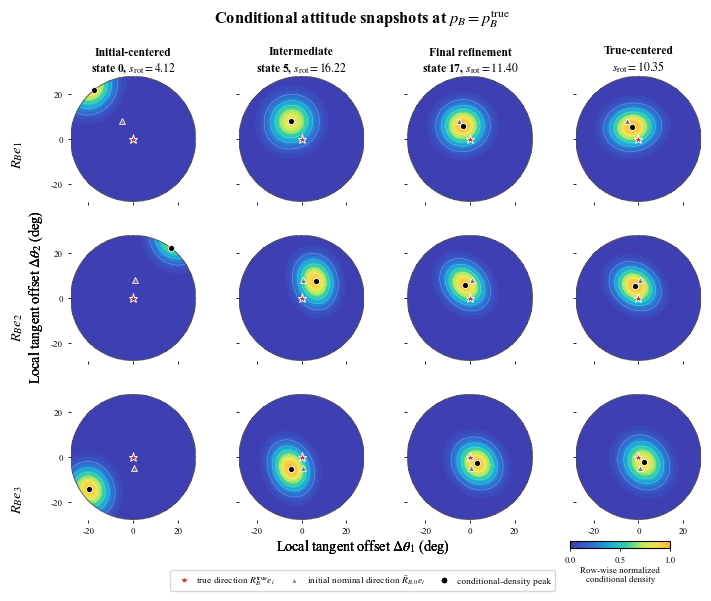

[Saved] exp2CB_mild_seed44_mild_conditional_zoomed_cap_true_centered_conditional_peak.pdf
[Saved] exp2CB_mild_seed44_mild_conditional_zoomed_cap_true_centered_conditional_peak.png


In [66]:
plot_exp2CB_conditional_zoomed_cap_with_true_reference(
    cond_prepared_snapshots_exp2CB,
    cond_cap_panel_data_exp2CB,
    cond_cap_frames_exp2CB,
    save_pdf=EXP2CB_COND_PDF,
    save_png=EXP2CB_COND_PNG,
    contour_levels=24,
)